**Table of contents**<a id='toc0_'></a>    
- [Pivot Tables for the Paper](#toc1_)    
- [Let's Create Summary](#toc2_)    
- [Pivot Views](#toc3_)    
  - [Structural Text Elements](#toc3_1_)    
  - [Math](#toc3_2_)    
- [Categorical Groups](#toc4_)    
  - [Morphological](#toc4_1_)    
  - [LAnguage Contact](#toc4_2_)    
- [Orthography](#toc5_)    
  - [Input Medium](#toc5_1_)    
  - [Diacritics](#toc5_2_)    
  - [Register Style](#toc5_3_)    
  - [Morph](#toc5_4_)    
- [Noise Cuated](#toc6_)    
- [Grammar](#toc7_)    
- [Linguistic Variety](#toc8_)    
- [Structural Text](#toc9_)    
    - [Math styling](#toc9_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Pivot Tables for the Paper](#toc0_)



In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)

from utils import *
from notebook_views import *

setup_styles()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# <a id='toc2_'></a>[Let's Create Summary](#toc0_)

In [56]:
OUTPUT_DIR = Path("./output/results-v5")
OUTPUT_DIR_ = OUTPUT_DIR / "summary"
OUTPUT_DIR_ = OUTPUT_DIR / "summary-rebuttal"
METRIC = "acc_norm"
# read all samples
base_dir = Path("../results/paper-v5").resolve().absolute()
OUTPUT_DIR_ = OUTPUT_DIR / "text-budget"
base_dir = Path("../results/paper-v5-text-budget").resolve().absolute()
OUTPUT_DIR_ = OUTPUT_DIR / "scale"
base_dir = Path("../results/paper-v5-scale").resolve().absolute()

# # keeps set_id, model pairs that are correct for canonical
# suffix = "(Still correct)"
# only_keep_canonical_true = True
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = False

# suffix = "(Remains or Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = True
# only_keep_perturbed_true = False

# suffix = "(Flipped to correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True

suffix = "(All)"
only_keep_canonical_true = False
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

code_pattern = "*"
title_pattern = "All Datasets"
OUTPUT_DIR = OUTPUT_DIR_ / "all"

OUTPUT_DIR = OUTPUT_DIR
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(590,
 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_chinese_code_language_script_switching_2025-12-21T19-55-15.393439.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_english_historical_spelling_2025-12-21T20-02-33.349753.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_italian_orthographic_errors_2025-12-21T19-51-39.429813.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_english_hyphenated_spelling_2025-12-21T21-03-19.412872.jsonl'),
  PosixPath('/Users/gsaltintas/

In [57]:
## Read all samples into a DataFrame
## exclude general dataset for now
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    exclude_patterns=["general"],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)

590 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_chinese_code_language_script_switching_2025-12-21T19-55-15.393439.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_english_historical_spelling_2025-12-21T20-02-33.349753.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_italian_orthographic_errors_2025-12-21T19-51-39.429813.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5-scale/toksuite__supertoken_models-llama_meta-llama-Llama-3.2-300M/samples_tokenizer_robustness_completion_english_hyphenated_spelling_2025-12-21T21-03-19.412872.jsonl'), PosixPath('/Users/gsaltintas/code/phd/to

We want a summary table like below

| filtering_mode   | model_name   | task                                                      | task_pretty_name     |   canonical_count |   num_samples | category                 | langs    |   acc_norm |   acc_norm_std |      acc |   acc_std | canonical_task_name                            |   canonical_acc |   canonical_acc_norm |
|:-----------------|:-------------|:----------------------------------------------------------|:---------------------|------------------:|--------------:|:-------------------------|:---------|-----------:|---------------:|---------:|----------:|:-----------------------------------------------|----------------:|---------------------:|
| no_filter        | Aya          | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.294118 |       0.469668 | 0.352941 |  0.492592 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | BLOOM        | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.411765 |       0.5073   | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | ByT5         | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.411765 |       0.5073   | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | Comma        | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.352941 |       0.492592 | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | GPT-2        | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.352941 |       0.492592 | 0.235294 |  0.437237 | tokenizer_robustness_completion_stem_canonical |        0.941176 |             0.823529 |
| no_filter        | GPT-4o       | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.352941 |       0.492592 | 0.352941 |  0.492592 | tokenizer_robustness_completion_stem_canonical |        1        |             0.941176 |
| no_filter        | Gemma-2      | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.411765 |       0.5073   | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.941176 |             0.882353 |
| no_filter        | Llama-3.2    | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.352941 |       0.492592 | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.882353 |
| no_filter        | Phi-3        | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.411765 |       0.5073   | 0.235294 |  0.437237 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | Qwen-3       | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.294118 |       0.469668 | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | Tekken       | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.235294 |       0.437237 | 0.176471 |  0.392953 | tokenizer_robustness_completion_stem_canonical |        0.941176 |             0.882353 |
| no_filter        | TokenMonster | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.294118 |       0.469668 | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.941176 |             0.764706 |
| no_filter        | XGLM         | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.823529 |       0.392953 | 0.882353 |  0.332106 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.823529 |
| no_filter        | mBERT        | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Structural Text Elements | eng_Latn |   0.235294 |       0.437237 | 0.294118 |  0.469668 | tokenizer_robustness_completion_stem_canonical |        0.882353 |             0.764706 |


started with this

|          |                     |            |     |          |                   |                     |             |                  |                     |                     |
| -------- | ------------------- | ---------- | --- | -------- | ----------------- | ------------------- | ----------- | ---------------- | ------------------- | ------------------- |
| Category | Perturbation (Task) | Model name | acc | acc_norm | number of samples | filter              | acc_std_err | acc_norm_std_err | number of canonical | number of perturbed |
|          | romanization        | Comma      |     |          |                   | only_canonical_true |             |                  |                     |                     |
|          | dialect             | Comma      |     |          |                   | only_canonical_true |             |                  |                     |                     |
|          | romanization        | Comma      |     |          |                   | no_filter           |             |                  |                     |                     |
|          | dialect             | Comma      |     |          |                   | no_filter           |             |                  |                     |                     |
|          |                     |            |     |          |                   | only_canonical      |             |                  |                     |                     |
|          |                     |            |     |          |                   | only_perturbed      |             |                  |                     |                     |								

In [58]:
import warnings

from category_mapping import SUBCATEGORY_TO_CATEGORY
from typing import List

FILTERS = [
    "no_filter",
    "only_canonical_correct",
    "canonical_wrong_at_least_one_perturb_correct",
    "remains_or_becomes_correct",
]
keys = {
    "no_filter": (False, False, False),
    "only_canonical_correct": (True, False, False),
    "canonical_wrong_at_least_one_perturb_correct": (False, False, True),
    "remains_or_becomes_correct": (False, True, False),
}


all_summaries = get_summaries(all_samples, subcategories=None)

N duplicates: 9767
N duplicates: 12032
N duplicates: 4575
N duplicates: 12359


In [59]:
## sanity check
print(
    all_summaries[all_summaries["task_pretty_name"] == "Fullwidth Characters"]
    .head(n=10)
    .to_markdown(index=False)
)


| filtering_mode                               | model_name     | task                                                      | task_pretty_name     |   canonical_count |   num_samples | category                 | langs    |   acc_norm |   acc_norm_std |      acc |    acc_std | canonical_task_name                            |   canonical_acc |   canonical_acc_norm | group_name                           |
|:---------------------------------------------|:---------------|:----------------------------------------------------------|:---------------------|------------------:|--------------:|:-------------------------|:---------|-----------:|---------------:|---------:|-----------:|:-----------------------------------------------|----------------:|---------------------:|:-------------------------------------|
| no_filter                                    | Llama-3.2      | tokenizer_robustness_completion_stem_fullwidth_characters | Fullwidth Characters |                17 |            17 | Str

In [60]:
save_path = OUTPUT_DIR / "summary.tsv"

all_summaries.to_csv(save_path, sep="\t")
print(f"File saved at \n{save_path}")

File saved at 
output/results-v5/scale/all/summary.tsv


# <a id='toc3_'></a>[Pivot Views](#toc0_)

FILTER

In [61]:

FILTER = "no_filter"
# FILTER = "only_canonical_correct"

In [62]:
style_summaries = all_summaries[
    (all_summaries["filtering_mode"] == FILTER)
    & ~(all_summaries["task"].str.contains("math"))
    & ~(all_summaries["task"].str.contains("stem"))
    # & (all_summaries["model_name"].str.lower().str.contains("llama"))
    # & all_summaries["task_pretty_name"].isin(styling_categories)
]
styled_df = get_styled_df(style_summaries, columns=["task_pretty_name", "langs"])
# styled_df = get_styled_df(style_summaries, index=["task_pretty_name", "langs"], columns=["model_name"])
styled_df

/Users/gsaltintas/code/phd/tokenizers/notebooks/notebook_views.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_avg)


# Main Table

In [ ]:


# FILTER = "no_filter"

# Define categories for the LaTeX table
latex_table_categories = {
    "Input (Non-EN)": [
        "English keyboard",
        "Arabic Keyboard for Farsi", 
        "Number Romanization",
        "Romanization",
        # "Partially romanized",
        "Traditional"
    ],
    "Diacritics (Non-EN)": ["Optional diacritics"],
    "Orthographic Errors (EN)": [
        "Orthographic errors",
        "Grammatical errors"
    ],
    "Orthographic Errors (Non-EN)": [
        "Orthographic errors",
        "Grammatical errors"
    ],
    "Morphological (EN)": [
    "Contractions",
    "Derivations",
    "Inflections",],
    "Morphological (Non-EN)": [
    "Contractions",
    "Derivations",
    "Inflections",],
    "Noise (EN)": [
        "Homoglyphs", "Plausible diacritics errors", "Keyboard proximity errors",
        "OCR Errors", "Character deletion", "Space removal", "Typographical errors",
        "Word Spacing/Zero-width characters/Extra Space",
    ],
    "Noise (Non-EN)": [
        "Homoglyphs", "Plausible diacritics errors", "Keyboard proximity errors", 
        "OCR Errors", "Character deletion", "Space removal", "Typographical errors",
        "Word Spacing/Zero-width characters/Extra Space",
    ],
    "LaTeX": ["LaTeX"],
    "STEM (EN)": [
        # "Spelled out", 
        "Unusual formatting"
        ],
    # "Math/STEM (Non-EN)": ["Turkish", "Italian", "Chinese", "Farsi"],
    "Unicode": [
        "Fullwidth Characters", "Decorative Unicode", "Scripted text",
        "Double struck", "Enclosed Characters", "Unicode formatting",
    ],
}

latex_column_data = [
    ["Input", "Diacr.", "Orth. Gram.", "<same>", "Morph", "<same>", "Noise", "<same>", "LaTeX", "STEM", "Unic", "Avg"],
    ["NEN", "NEN", "EN", "NEN", "EN", "NEN", "EN", "NEN", "EN", "EN", "EN", ""]
]

# whitespace_robustness_dict = {
#     # These would need to be calculated as robustness drops from your whitespace analysis
#     # For now using placeholder - you'd calculate (canonical_whitespace - perturbed_whitespace) / canonical_whitespace
#     "Aya": 0.15,  # Example: 15% drop
#     "BLOOM": 0.18,
#     "ByT5": 0.12,
#     "Comma": 0.14,
#     "GPT-2": 0.16,
#     "GPT-4o": 0.13,
#     "Gemma-2": 0.17,
#     "Llama-3.2": 0.19,
#     "Phi-3": 0.14,
#     "Qwen-3": 0.16,
#     "Tekken": 0.15,
#     "TokenMonster": 0.22,
#     "XGLM": 0.08,
#     "mBERT": 0.09
# }

caption = "Tokenization robustness under multilingual text perturbations. Values represent relative performance drop ($\\frac{\\text{Acc}_{\\text{can}} - \\text{Acc}_{\\text{pert}}}{\\text{Acc}_{\\text{can}}}$); lower values indicate greater robustness. Perturbation types: Input: non-native keyboard/romanization; Diacr.: optional diacritics; Orth. Errors: orthographic errors; Morph.: derivations/inflections/contractions; Noise: homoglyphs/OCR/typos/spacing; LaTeX: LaTeX-style math formatting; STEM: scientific diagrams and notations; Unic.: Unicode styling characters. N\\eng:non-English. Break-down of each category and detailed case studies are presented in \\cref{ap:sec:benchmark_results}. \\textbf{\\textcolor{green!70!black}{Green}} and \\textcolor{red}{red} entries indicate notable robustness and fragility, respectively."

if __name__ == "__main__":
    # Generate robustness data and save to JSONL
    canonical_by_task = get_canonical_by_task(all_summaries, FILTER)
    robustness_data_main = generate_robustness_latex_table_dict(all_summaries, canonical_by_task, FILTER, latex_table_categories=latex_table_categories, group_langs=True)
    jsonl_file = save_to_jsonl(robustness_data_main, "robustness_results.jsonl")
    
    # Generate robustness LaTeX table
    robustness_latex = load_and_generate_robustness_latex_table(jsonl_file,  column_data=latex_column_data, size="scriptsize", title=caption)
    
    print("Robustness LaTeX Table Generated!")
    print("=" * 60)
    print(robustness_latex)
    
    # Save to file
    with open("robustness_tokenization_table.tex", "w") as f:
        f.write(robustness_latex)
    print("\nRobustness table saved to: robustness_tokenization_table.tex")
    get_robustness_styled_df(jsonl_file)


Results saved to robustness_results.jsonl
Robustness LaTeX Table Generated!
\begin{table}[hp]
\centering 
\vspace*{\fill}
\caption{Tokenization robustness under multilingual text perturbations. Values represent relative performance drop ($\frac{\text{Acc}_{\text{can}} - \text{Acc}_{\text{pert}}}{\text{Acc}_{\text{can}}}$); lower values indicate greater robustness. Perturbation types: Input: non-native keyboard/romanization; Diacr.: optional diacritics; Orth. Errors: orthographic errors; Morph.: derivations/inflections/contractions; Noise: homoglyphs/OCR/typos/spacing; LaTeX: LaTeX-style math formatting; STEM: scientific diagrams and notations; Unic.: Unicode styling characters. N\eng:non-English. Break-down of each category and detailed case studies are presented in \cref{ap:sec:benchmark_results}. \textbf{\textcolor{green!70!black}{Green}} and \textcolor{red}{red} entries indicate notable robustness and fragility, respectively.}
\label{tab:multilingual_tokenization_robustness}
\script

: 

## Llama scale

In [32]:


# FILTER = "no_filter"

# Define categories for the LaTeX table
latex_table_categories = {
    "Input (Non-EN)": [
        "English keyboard",
        "Arabic Keyboard for Farsi", 
        "Number Romanization",
        "Romanization",
        # "Partially romanized",
        "Traditional"
    ],
    "Diacritics (Non-EN)": ["Optional diacritics"],
    "Orthographic Errors (EN)": [
        "Orthographic errors",
        "Grammatical errors"
    ],
    "Orthographic Errors (Non-EN)": [
        "Orthographic errors",
        "Grammatical errors"
    ],
    "Morphological (EN)": [
    "Contractions",
    "Derivations",
    "Inflections",],
    "Morphological (Non-EN)": [
    "Contractions",
    "Derivations",
    "Inflections",],
    "Noise (EN)": [
        "Homoglyphs", "Plausible diacritics errors", "Keyboard proximity errors",
        "OCR Errors", "Character deletion", "Space removal", "Typographical errors",
        "Word Spacing/Zero-width characters/Extra Space",
    ],
    "Noise (Non-EN)": [
        "Homoglyphs", "Plausible diacritics errors", "Keyboard proximity errors", 
        "OCR Errors", "Character deletion", "Space removal", "Typographical errors",
        "Word Spacing/Zero-width characters/Extra Space",
    ],
    "LaTeX": ["LaTeX"],
    "STEM (EN)": [
        # "Spelled out", 
        "Unusual formatting"
        ],
    # "Math/STEM (Non-EN)": ["Turkish", "Italian", "Chinese", "Farsi"],
    "Unicode": [
        "Fullwidth Characters", "Decorative Unicode", "Scripted text",
        "Double struck", "Enclosed Characters", "Unicode formatting",
    ],
}

latex_column_data = [
    ["Input", "Diacr.", "Orth. Gram.", "<same>", "Morph", "<same>", "Noise", "<same>", "LaTeX", "STEM", "Unic", "Avg"],
    ["NEN", "NEN", "EN", "NEN", "EN", "NEN", "EN", "NEN", "EN", "EN", "EN", ""]
]

caption = "Tokenization Robustness of the Llama-3.2 Tokenizer across 1B and 7B model scales under multilingual text perturbations. Values represent relative performance drop ($\\frac{\\text{Acc}_{\\text{can}} - \\text{Acc}_{\\text{pert}}}{\\text{Acc}_{\\text{can}}}$); lower values indicate greater robustness, same as \\cref{tab:multilingual_tokenization_robustness}."
label="llama-scale"

if __name__ == "__main__":
    # Generate robustness data and save to JSONL
    canonical_by_task = get_canonical_by_task(all_summaries, FILTER)
    all_summaries_ = all_summaries[all_summaries["model_name"].str.contains("Llama-3.2")]
    robustness_data_main = generate_robustness_latex_table_dict(all_summaries_, canonical_by_task, FILTER, latex_table_categories=latex_table_categories, group_langs=True)
    jsonl_file = save_to_jsonl(robustness_data_main, "robustness_results.jsonl")
    
    # Generate robustness LaTeX table
    robustness_latex = load_and_generate_robustness_latex_table(jsonl_file,  column_data=latex_column_data, size="scriptsize", title=caption,label=label)
    
    print("Robustness LaTeX Table Generated!")
    print("=" * 60)
    print(robustness_latex)
    
    # Save to file
    with open("robustness_tokenization_table.tex", "w") as f:
        f.write(robustness_latex)
    print("\nRobustness table saved to: robustness_tokenization_table.tex")
    get_robustness_styled_df(jsonl_file)


Results saved to robustness_results.jsonl
Robustness LaTeX Table Generated!
\begin{table}[hp]
\centering 
\vspace*{\fill}
\caption{Tokenization Robustness of the Llama-3.2 Tokenizer across 1B and 7B model scales under multilingual text perturbations. Values represent relative performance drop ($\frac{\text{Acc}_{\text{can}} - \text{Acc}_{\text{pert}}}{\text{Acc}_{\text{can}}}$); lower values indicate greater robustness, same as \cref{tab:multilingual_tokenization_robustness}.}
\label{tab:llama-scale}
\scriptsize
\begin{tabularx}{\textwidth}{l|*{12}{>{\centering\arraybackslash}X}}
\toprule
\textbf{Model} & \multicolumn{1}{c}{\textbf{Input}} & \multicolumn{1}{c}{\textbf{Diacr.}} & \multicolumn{2}{c}{\textbf{Orth. Gram.}} & \multicolumn{2}{c}{\textbf{Morph}} & \multicolumn{2}{c}{\textbf{Noise}} & \multicolumn{1}{c}{\textbf{LaTeX}} & \multicolumn{1}{c}{\textbf{STEM}} & \multicolumn{1}{c}{\textbf{Unic}} & \multicolumn{1}{c}{\textbf{Avg}} &\\
& \multicolumn{1}{c}{NEN} & \multicolumn{1}{c}{NE

In [33]:
## just canonical perf
records = []
for key, acc in canonical_by_task.items():
    model_name, task, lang = key
    records.append(
        {
            "model_name": model_name,
            "task": task,
            # "lang": lang,
            "acc_norm": acc,
        }
    )
canonical_df = pd.DataFrame.from_records(records)
# canonical_styled_df = get_styled_df(canonical_df, columns=["task", "lang"])
pv = canonical_df.pivot_table(index="model_name", columns=["task"], values="acc_norm")
pv["Average"] = pv.mean(axis=1)
pv = pv.sort_values("Average", ascending=False)
print(pv.to_markdown().replace("tokenizer_robustness_completion_", ""))

| model_name     |   chinese_canonical |   english_canonical |   farsi_canonical |   italian_canonical |   math_canonical |   stem_canonical |   turkish_canonical |   Average |
|:---------------|----------------------------------------------------:|----------------------------------------------------:|--------------------------------------------------:|----------------------------------------------------:|-------------------------------------------------:|-------------------------------------------------:|----------------------------------------------------:|----------:|
| Llama-3.2-7B   |                                                0.9  |                                               1     |                                             0.8   |                                               0.975 |                                         1        |                                         0.931818 |                                               0.925 |  0.933117 |
| Llama-3.2      |   

In [34]:
for category, subcategories in latex_table_categories.items():
    print(f"Category: {category}")
    cat_df = canonical_df[canonical_df["task"].isin(subcategories)]
    pv = cat_df.pivot_table(index="model_name", columns=["task", "lang"], values="acc_norm")
    pv["Average"] = pv.mean(axis=1)
    pv = pv.sort_values("Average", ascending=False)
    print(pv.to_markdown().replace("tokenizer_robustness_completion_", ""))
    print("\n")

Category: Input (Non-EN)


KeyError: 'lang'

In [41]:
df = get_robustness_styled_df(jsonl_file)
print(df.data.to_markdown())
# dir(df)

| model_name           |   Input (Non-EN) |   Diacritics (Non-EN) |   Orthographic Errors (EN) |   Orthographic Errors (Non-EN) |   Morphological (EN) |   Morphological (Non-EN) |   Noise (EN) |   Noise (Non-EN) |       LaTeX |   STEM (EN) |     Unicode |     Average |
|:---------------------|-----------------:|----------------------:|---------------------------:|-------------------------------:|---------------------:|-------------------------:|-------------:|-----------------:|------------:|------------:|------------:|------------:|
| Llama-3.2-7B         |        0.299253  |             0.493056  |                  0.05      |                      0.0623448 |           0.236364   |               0.0754996  |    0.0858622 |        0.140272  |   0.170732  |   0.262195  |   0.598887  |   0.224951  |
| Llama-3.2            |        0.337706  |             0.540827  |                  0.116667  |                      0.0927022 |           0.254545   |               0.0811626  |    0.14847

### Llama scale all samples

In [36]:
style_summaries = all_summaries[
    (all_summaries["filtering_mode"] == FILTER)
    & ~(all_summaries["task"].str.contains("math"))
    & ~(all_summaries["task"].str.contains("stem"))
    & (all_summaries["model_name"].str.lower().str.contains("llama"))
    & (all_summaries["task_pretty_name"].isin(latex_table_categories["Noise (Non-EN)"]))
    # & all_summaries["task_pretty_name"].isin(styling_categories)
]
styled_df = get_styled_df(style_summaries, columns=["task_pretty_name", "langs"])
# styled_df = get_styled_df(style_summaries, index=["task_pretty_name", "langs"], columns=["model_name"])
styled_df

/Users/gsaltintas/code/phd/tokenizers/notebooks/notebook_views.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_avg)


## HeatMap

[Text(0, 0.5, 'TokenMonster'),
 Text(0, 1.5, 'XGLM'),
 Text(0, 2.5, 'BLOOM'),
 Text(0, 3.5, 'Comma'),
 Text(0, 4.5, 'ByT5'),
 Text(0, 5.5, 'meta-llama-Llama-3.2-7B'),
 Text(0, 6.5, 'mBERT'),
 Text(0, 7.5, 'GPT-4o'),
 Text(0, 8.5, 'GPT-2'),
 Text(0, 9.5, 'Phi-3'),
 Text(0, 10.5, 'Qwen-3'),
 Text(0, 11.5, 'Gemma-2'),
 Text(0, 12.5, 'Llama-3.2'),
 Text(0, 13.5, 'Aya'),
 Text(0, 14.5, 'Tekken')]

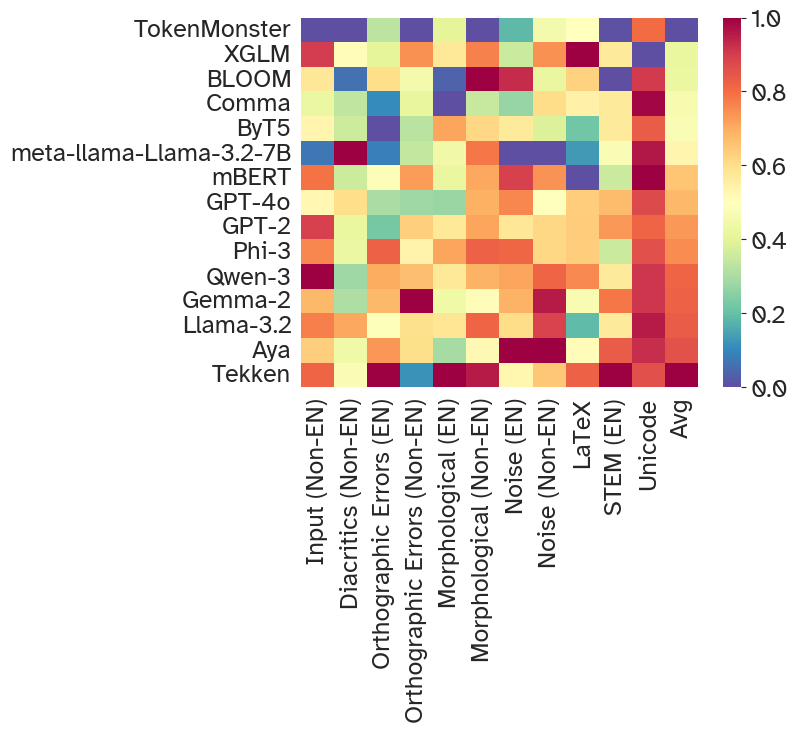

In [147]:
df = robustness_data_main["raw_dataframe"]
df["Avg"] = df.mean(axis=1)
df = df.sort_values("Avg")
col_mins = df.min(axis=0)
col_maxs = df.max(axis=0)
heatmap_df = (df - col_mins) / (col_maxs - col_mins)
ax = sns.heatmap(heatmap_df, cmap="Spectral_r")
ax.set_yticks([i+0.5 for i in range(len(df))])
ax.set_yticklabels(df.index)


In [20]:
import pandas as pd
import numpy as np
from matplotlib import cm
from matplotlib.colors import rgb2hex
from matplotlib.colors import PowerNorm
gamma_value = 2.0 
norm = PowerNorm(gamma=gamma_value, vmin=0, vmax=1.)
def get_latex_color_from_norm_value(norm_value, cmap_name="Spectral_r", gamma=2.0):
    """
    Calculates the RGB color from a normalized value [0, 1], applying a
    power transformation (gamma) to compress the extreme colors to the ends
    and expand the light middle colors (around 0.5).

    Args:
        norm_value (float): The original normalized value (0.0 to 1.0).
        cmap_name (str): The name of the Matplotlib colormap (e.g., 'Spectral_r').
        gamma (float): The power factor (gamma).
                       gamma > 1.0 (e.g., 2.0) compresses the ends (tighter colors).
                       gamma = 1.0 is linear (no change).

    Returns:
        str: A string for LaTeX \cellcolor (e.g., "\\cellcolor[rgb]{0.1,0.2,0.3}").
    """
    # 1. Clip the value
    norm_value = np.clip(norm_value, 0.0, 1.0)

    # 2. Apply the Piecewise Power Transformation (Normalization)
    if gamma != 1.0:
        if norm_value <= 0.5:
            # Low end (0.0 to 0.5): Transform using 1 - (1-x)^gamma
            # This makes values closer to 0.5 get mapped to values closer to 0.5.
            # Example: norm_value = 0.25 (Original mid-low)
            #          (0.5 - 0.25) / 0.5 = 0.5 (Normalized distance to center)
            #          0.5 ** 2.0 = 0.25
            #          0.5 - 0.5 * 0.25 = 0.375 <--- New Index (closer to 0.5)
            x_prime = (0.5 - norm_value) / 0.5
            norm_value_transformed = 0.5 - 0.5 * (x_prime ** gamma)
        else: # norm_value > 0.5
            # High end (0.5 to 1.0): Transform using x^gamma
            # This makes values closer to 0.5 get mapped to values closer to 0.5.
            # Example: norm_value = 0.75 (Original mid-high)
            #          (0.75 - 0.5) / 0.5 = 0.5
            #          0.5 ** 2.0 = 0.25
            #          0.5 + 0.5 * 0.25 = 0.625 <--- New Index (closer to 0.5)
            x_prime = (norm_value - 0.5) / 0.5
            norm_value_transformed = 0.5 + 0.5 * (x_prime ** gamma)
    else:
        norm_value_transformed = norm_value # No transformation if gamma is 1.0

    # 3. Get the colormap object and RGB tuple
    cmap = cm.get_cmap(cmap_name)
    r, g, b, a = cmap(norm_value_transformed)

    # 4. Format for LaTeX \cellcolor
    color_string = f"\\cellcolor[rgb]{{{r:.3f},{g:.3f},{b:.3f}}}"

    return color_string

heatmap_df_colored = heatmap_df.applymap(get_latex_color_from_norm_value)

jsonl_file = save_to_jsonl({"raw_dataframe": heatmap_df_colored}, "robustness_results.jsonl")

# Generate robustness LaTeX table
robustness_latex = load_and_generate_robustness_latex_table(jsonl_file,  column_data=latex_column_data, size="scriptsize", title=caption)

print("Robustness LaTeX Table Generated!")
print("=" * 60)
print(robustness_latex)

# Save to file
path = OUTPUT_DIR / "robustness_tokenization_table_heatmap.tex"
with open(path, "w") as f:
    f.write(robustness_latex)
print("\nRobustness table saved to: robustness_tokenization_table_heatmap.tex")
get_robustness_styled_df(jsonl_file)
heatmap_df

Results saved to robustness_results.jsonl
Could not compute average column or sort: Could not convert ['\\cellcolor[rgb]{0.369,0.310,0.635}\\cellcolor[rgb]{0.369,0.310,0.635}\\cellcolor[rgb]{0.944,0.978,0.662}\\cellcolor[rgb]{0.369,0.310,0.635}\\cellcolor[rgb]{0.983,0.993,0.722}\\cellcolor[rgb]{0.369,0.310,0.635}\\cellcolor[rgb]{0.369,0.310,0.635}\\cellcolor[rgb]{0.400,0.761,0.647}\\cellcolor[rgb]{0.998,0.999,0.746}\\cellcolor[rgb]{0.348,0.336,0.648}\\cellcolor[rgb]{0.993,0.717,0.409}\\cellcolor[rgb]{0.369,0.310,0.635}'
 '\\cellcolor[rgb]{0.933,0.391,0.272}\\cellcolor[rgb]{0.996,0.878,0.545}\\cellcolor[rgb]{0.983,0.993,0.722}\\cellcolor[rgb]{0.995,0.840,0.513}\\cellcolor[rgb]{1.000,0.988,0.729}\\cellcolor[rgb]{0.994,0.786,0.468}\\cellcolor[rgb]{0.739,0.894,0.629}\\cellcolor[rgb]{0.999,0.983,0.721}\\cellcolor[rgb]{0.620,0.004,0.259}\\cellcolor[rgb]{1.000,0.988,0.729}\\cellcolor[rgb]{0.369,0.310,0.635}\\cellcolor[rgb]{0.987,0.995,0.728}'
 '\\cellcolor[rgb]{0.999,0.983,0.721}\\cellcolor[r

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_15279/398587651.py:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_df_colored = heatmap_df.applymap(get_latex_color_from_norm_value)
/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_15279/398587651.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
TokenMonster,0.000000,0.000000,0.330747,0.000000,0.404082,0.000000,0.000000,0.112755,0.498534,0.006669,0.801142,0.000000
XGLM,0.898730,0.724390,0.403974,0.745741,0.571429,0.769114,0.207586,0.585620,1.000000,0.569767,0.000000,0.417535
BLOOM,0.577298,0.087088,0.597682,0.456763,0.035714,1.000000,0.911427,0.058773,0.625237,0.000000,0.903296,0.423441
Comma,0.423682,0.469837,0.105960,0.413719,0.000000,0.344450,0.105279,0.356435,0.544545,0.569767,0.988495,0.464170
ByT5,0.534337,0.501592,0.000000,0.325538,0.714286,0.614290,0.467946,0.000000,0.217626,0.569767,0.834741,0.476517
mBERT,0.791356,0.502256,0.482907,0.723109,0.420849,0.708381,0.868993,0.575888,0.000000,0.354651,1.000000,0.653583
GPT-4o,0.524954,0.846426,0.299266,0.283291,0.274131,0.691611,0.705591,0.178387,0.636035,0.674702,0.874246,0.679297
GPT-2,0.891097,0.583864,0.225166,0.629120,0.571429,0.713056,0.480499,0.371706,0.639328,0.733935,0.818673,0.731831
Phi-3,0.758123,0.597305,0.821192,0.537360,0.714286,0.820379,0.771117,0.377409,0.636623,0.354651,0.861720,0.750431
Qwen-3,1.000000,0.401836,0.701987,0.666531,0.571429,0.689506,0.645379,0.704669,0.754666,0.569767,0.913437,0.820271


horizontal color bar for the gamma-transformed colormap saved as 'custom_spectral_r_horizontal_colorbar.pdf'.


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_15279/1562794823.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


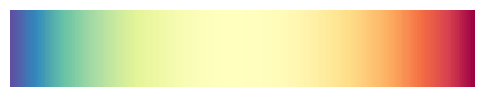

In [21]:
## plot the cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm

orientation = "vertical"
figsize = (1, 6)
orientation = "horizontal"
figsize = (6, 1)
# --- Your Transformation Logic (redefined here for completeness) ---

def generate_custom_cmap_rgb(cmap_name="Spectral_r", gamma=2.0, n_steps=256):
    """Generates the RGB values for the custom, gamma-transformed colormap."""
    norm_values = np.linspace(0.0, 1.0, n_steps)
    norm_values_transformed = np.empty_like(norm_values)
    
    if gamma != 1.0:
        for i, norm_value in enumerate(norm_values):
            if norm_value <= 0.5:
                x_prime = (0.5 - norm_value) / 0.5
                norm_values_transformed[i] = 0.5 - 0.5 * (x_prime ** gamma)
            else:
                x_prime = (norm_value - 0.5) / 0.5
                norm_values_transformed[i] = 0.5 + 0.5 * (x_prime ** gamma)
    else:
        norm_values_transformed = norm_values

    cmap = cm.get_cmap(cmap_name)
    colors_rgb = cmap(norm_values_transformed)[:, :3]
    
    return colors_rgb

# 1. Generate the RGB values for Spectral_r with gamma=2.0
custom_colors_rgb = generate_custom_cmap_rgb(cmap_name="Spectral_r", gamma=2.0, n_steps=256)

# 2. Create a Matplotlib ListedColormap object from the custom RGB array
custom_cmap = mpl.colors.ListedColormap(custom_colors_rgb)

# 3. Define the normalization range (vmin=0, vmax=1)
norm = mpl.colors.Normalize(vmin=0, vmax=1) 

# 4. Create a figure specifically for the color bar
# Adjusting the figsize for a narrow, tall vertical bar (e.g., 1 inch wide, 6 inches tall)
fig, ax = plt.subplots(figsize=figsize)
ax.axis('off') # Hide the axes ticks and frame

# 5. Create the color bar using the custom colormap and set orientation='vertical'
cb1 = mpl.colorbar.ColorbarBase(
    ax,
    cmap=custom_cmap, # Use the custom colormap
    norm=norm,
    orientation=orientation
)

# Optional: Set labels (useful for context)
cb1.set_label(r'Normalized Value ($\gamma=2.0$)', rotation=270, labelpad=15)
cb1.set_ticks([0.0, 0.5, 1.0])
cb1.set_ticklabels(['Min (0.0)', 'Mid (0.5)', 'Max (1.0)'])

# 6. Save the figure as a PDF
plt.savefig(f'custom_spectral_r_{orientation}_colorbar.pdf', bbox_inches='tight', pad_inches=0.1)

# plt.close(fig) 
print(f"{orientation} color bar for the gamma-transformed colormap saved as 'custom_spectral_r_{orientation}_colorbar.pdf'.")

In [22]:
heatmap_df

,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
TokenMonster,0.000000,0.000000,0.330747,0.000000,0.404082,0.000000,0.000000,0.112755,0.498534,0.006669,0.801142,0.000000
XGLM,0.898730,0.724390,0.403974,0.745741,0.571429,0.769114,0.207586,0.585620,1.000000,0.569767,0.000000,0.417535
BLOOM,0.577298,0.087088,0.597682,0.456763,0.035714,1.000000,0.911427,0.058773,0.625237,0.000000,0.903296,0.423441
Comma,0.423682,0.469837,0.105960,0.413719,0.000000,0.344450,0.105279,0.356435,0.544545,0.569767,0.988495,0.464170
ByT5,0.534337,0.501592,0.000000,0.325538,0.714286,0.614290,0.467946,0.000000,0.217626,0.569767,0.834741,0.476517
mBERT,0.791356,0.502256,0.482907,0.723109,0.420849,0.708381,0.868993,0.575888,0.000000,0.354651,1.000000,0.653583
GPT-4o,0.524954,0.846426,0.299266,0.283291,0.274131,0.691611,0.705591,0.178387,0.636035,0.674702,0.874246,0.679297
GPT-2,0.891097,0.583864,0.225166,0.629120,0.571429,0.713056,0.480499,0.371706,0.639328,0.733935,0.818673,0.731831
Phi-3,0.758123,0.597305,0.821192,0.537360,0.714286,0.820379,0.771117,0.377409,0.636623,0.354651,0.861720,0.750431
Qwen-3,1.000000,0.401836,0.701987,0.666531,0.571429,0.689506,0.645379,0.704669,0.754666,0.569767,0.913437,0.820271


In [23]:
get_robustness_styled_df(jsonl_file)

,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg,Average
model_name,,,,,,,,,,,,,
TokenMonster,"\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.944,0.978,0.662}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.983,0.993,0.722}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.400,0.761,0.647}","\cellcolor[rgb]{0.998,0.999,0.746}","\cellcolor[rgb]{0.348,0.336,0.648}","\cellcolor[rgb]{0.993,0.717,0.409}","\cellcolor[rgb]{0.369,0.310,0.635}",nan
XGLM,"\cellcolor[rgb]{0.933,0.391,0.272}","\cellcolor[rgb]{0.996,0.878,0.545}","\cellcolor[rgb]{0.983,0.993,0.722}","\cellcolor[rgb]{0.995,0.840,0.513}","\cellcolor[rgb]{1.000,0.988,0.729}","\cellcolor[rgb]{0.994,0.786,0.468}","\cellcolor[rgb]{0.739,0.894,0.629}","\cellcolor[rgb]{0.999,0.983,0.721}","\cellcolor[rgb]{0.620,0.004,0.259}","\cellcolor[rgb]{1.000,0.988,0.729}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.987,0.995,0.728}",nan
BLOOM,"\cellcolor[rgb]{0.999,0.983,0.721}","\cellcolor[rgb]{0.312,0.663,0.688}","\cellcolor[rgb]{0.999,0.979,0.713}","\cellcolor[rgb]{0.998,0.999,0.746}","\cellcolor[rgb]{0.254,0.459,0.706}","\cellcolor[rgb]{0.620,0.004,0.259}","\cellcolor[rgb]{0.909,0.355,0.281}","\cellcolor[rgb]{0.216,0.556,0.732}","\cellcolor[rgb]{0.999,0.959,0.681}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.923,0.377,0.276}","\cellcolor[rgb]{0.987,0.995,0.728}",nan
Comma,"\cellcolor[rgb]{0.990,0.996,0.734}","\cellcolor[rgb]{0.998,0.999,0.746}","\cellcolor[rgb]{0.376,0.734,0.658}","\cellcolor[rgb]{0.987,0.995,0.728}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.952,0.981,0.674}","\cellcolor[rgb]{0.376,0.734,0.658}","\cellcolor[rgb]{0.960,0.984,0.686}","\cellcolor[rgb]{1.000,0.993,0.737}","\cellcolor[rgb]{1.000,0.988,0.729}","\cellcolor[rgb]{0.662,0.051,0.269}","\cellcolor[rgb]{0.998,0.999,0.746}",nan
ByT5,"\cellcolor[rgb]{1.000,0.998,0.745}","\cellcolor[rgb]{1.000,0.998,0.745}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.940,0.976,0.656}","\cellcolor[rgb]{0.996,0.888,0.561}","\cellcolor[rgb]{0.999,0.969,0.697}","\cellcolor[rgb]{0.998,0.999,0.746}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.766,0.905,0.624}","\cellcolor[rgb]{1.000,0.988,0.729}","\cellcolor[rgb]{0.983,0.617,0.350}","\cellcolor[rgb]{0.998,0.999,0.746}",nan
mBERT,"\cellcolor[rgb]{0.993,0.740,0.429}","\cellcolor[rgb]{1.000,0.998,0.745}","\cellcolor[rgb]{0.998,0.999,0.746}","\cellcolor[rgb]{0.996,0.878,0.545}","\cellcolor[rgb]{0.987,0.995,0.728}","\cellcolor[rgb]{0.997,0.893,0.569}","\cellcolor[rgb]{0.967,0.497,0.295}","\cellcolor[rgb]{1.000,0.988,0.729}","\cellcolor[rgb]{0.369,0.310,0.635}","\cellcolor[rgb]{0.960,0.984,0.686}","\cellcolor[rgb]{0.620,0.004,0.259}","\cellcolor[rgb]{0.998,0.940,0.649}",nan
GPT-4o,"\cellcolor[rgb]{1.000,0.998,0.745}","\cellcolor[rgb]{0.978,0.577,0.332}","\cellcolor[rgb]{0.921,0.968,0.626}","\cellcolor[rgb]{0.906,0.962,0.602}","\cellcolor[rgb]{0.893,0.957,0.598}","\cellcolor[rgb]{0.997,0.912,0.601}","\cellcolor[rgb]{0.997,0.898,0.577}","\cellcolor[rgb]{0.655,0.860,0.643}","\cellcolor[rgb]{0.999,0.955,0.673}","\cellcolor[rgb]{0.998,0.926,0.625}","\cellcolor[rgb]{0.964,0.477,0.286}","\cellcolor[rgb]{0.997,0.921,0.617}",nan
GPT-2,"\cellcolor[rgb]{0.947,0.413,0.266}","\cellcolor[rgb]{0.999,0.983,0.721}","\cellcolor[rgb]{0.784,0.913,0.620}","\cellcolor[rgb]{0.999,0.959,0.681}","\cellcolor[rgb]{1.000,0.988,0.729}","\cellcolor[rgb]{0.996,0.888,0.561}","\cellcolor[rgb]{0.998,0.999,0.746}","\cellcolor[rgb]{0.967,0.987,0.698}","\cellcolor[rgb]{0.999,0.955,0.673}","\cellcolor[rgb]{0.996,0.855,0.526}","\cellcolor[rgb]{0.991,0.677,0.378}","\cellcolor[rgb]{0.996,0.863,0.532}",nan
Phi-3,"\cellcolor[rgb]{0.995,0.809,0.487}","\cellcolor[rgb]{0.999,0.979,0.713}","\cellcolor[rgb]{0.990,0.667,0.373}","\cellcolor[rgb]{1.000,0.99

Accuracy vs Vocab Size

In [ ]:
# sns.scatterplot()
# pv
from xarch_tokenizers.logging.report_utils import VOCAB_SIZES_PRETTY_NAME

df = robustness_data_main["raw_dataframe"]
df["vocab_size"] = df.index.map(lambda x: VOCAB_SIZES_PRETTY_NAME.get(x, np.nan))
df
# df.reset_index()
# df.reset_index()["index"].map(lambda x: x)

,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg,vocab_size
Aya,0.314185,0.467186,0.145299,0.097465,0.216783,0.032245,0.189542,0.253242,0.228090,0.381250,0.579167,0.264041,255029
BLOOM,0.306891,0.351852,0.125000,0.077823,0.181818,0.110929,0.182072,0.186893,0.245012,0.108108,0.568751,0.222286,250680
ByT5,0.301452,0.441820,0.037037,0.059958,0.272727,0.047619,0.144668,0.182750,0.183982,0.294872,0.534550,0.227403,259
Comma,0.287445,0.434928,0.052632,0.071963,0.177033,0.003328,0.114080,0.207876,0.232930,0.294872,0.611255,0.226213,64000
GPT-2,0.346613,0.459677,0.070175,0.101288,0.253589,0.063830,0.145727,0.208953,0.247121,0.348684,0.526535,0.252017,50257
GPT-4o,0.300265,0.516667,0.081081,0.054206,0.213759,0.060310,0.164711,0.195325,0.246628,0.329268,0.554259,0.246953,200000
Gemma-2,0.319486,0.426344,0.136752,0.151779,0.235431,0.030639,0.157200,0.248202,0.221364,0.365385,0.573939,0.260593,256128
Llama-3.2,0.331719,0.550000,0.108333,0.096855,0.254545,0.081163,0.148479,0.240471,0.179724,0.294872,0.594170,0.261848,128256
Phi-3,0.329781,0.462595,0.157895,0.088795,0.272727,0.081446,0.170238,0.209355,0.246716,0.224359,0.548010,0.253811,32064
Qwen-3,0.360399,0.420168,0.140351,0.106381,0.253589,0.059965,0.159633,0.232424,0.264391,0.294872,0.573810,0.260544,151646


Text(0.5, 0, 'Vocabulary Size')

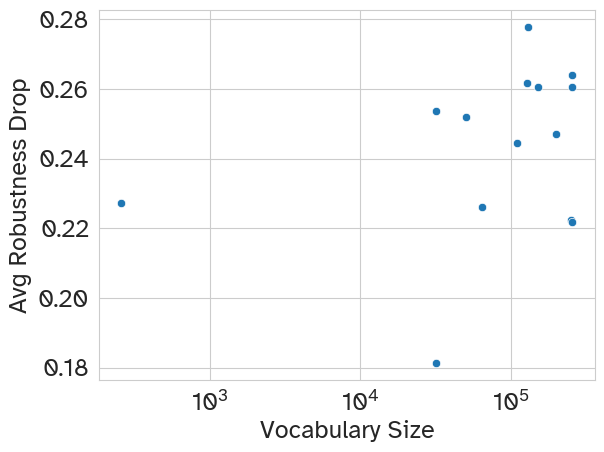

In [48]:
ax = sns.scatterplot(data=df, x="vocab_size", y="Avg")
ax.set_xscale("log")
ax.set_ylabel("Avg Robustness Drop")
ax.set_xlabel("Vocabulary Size")

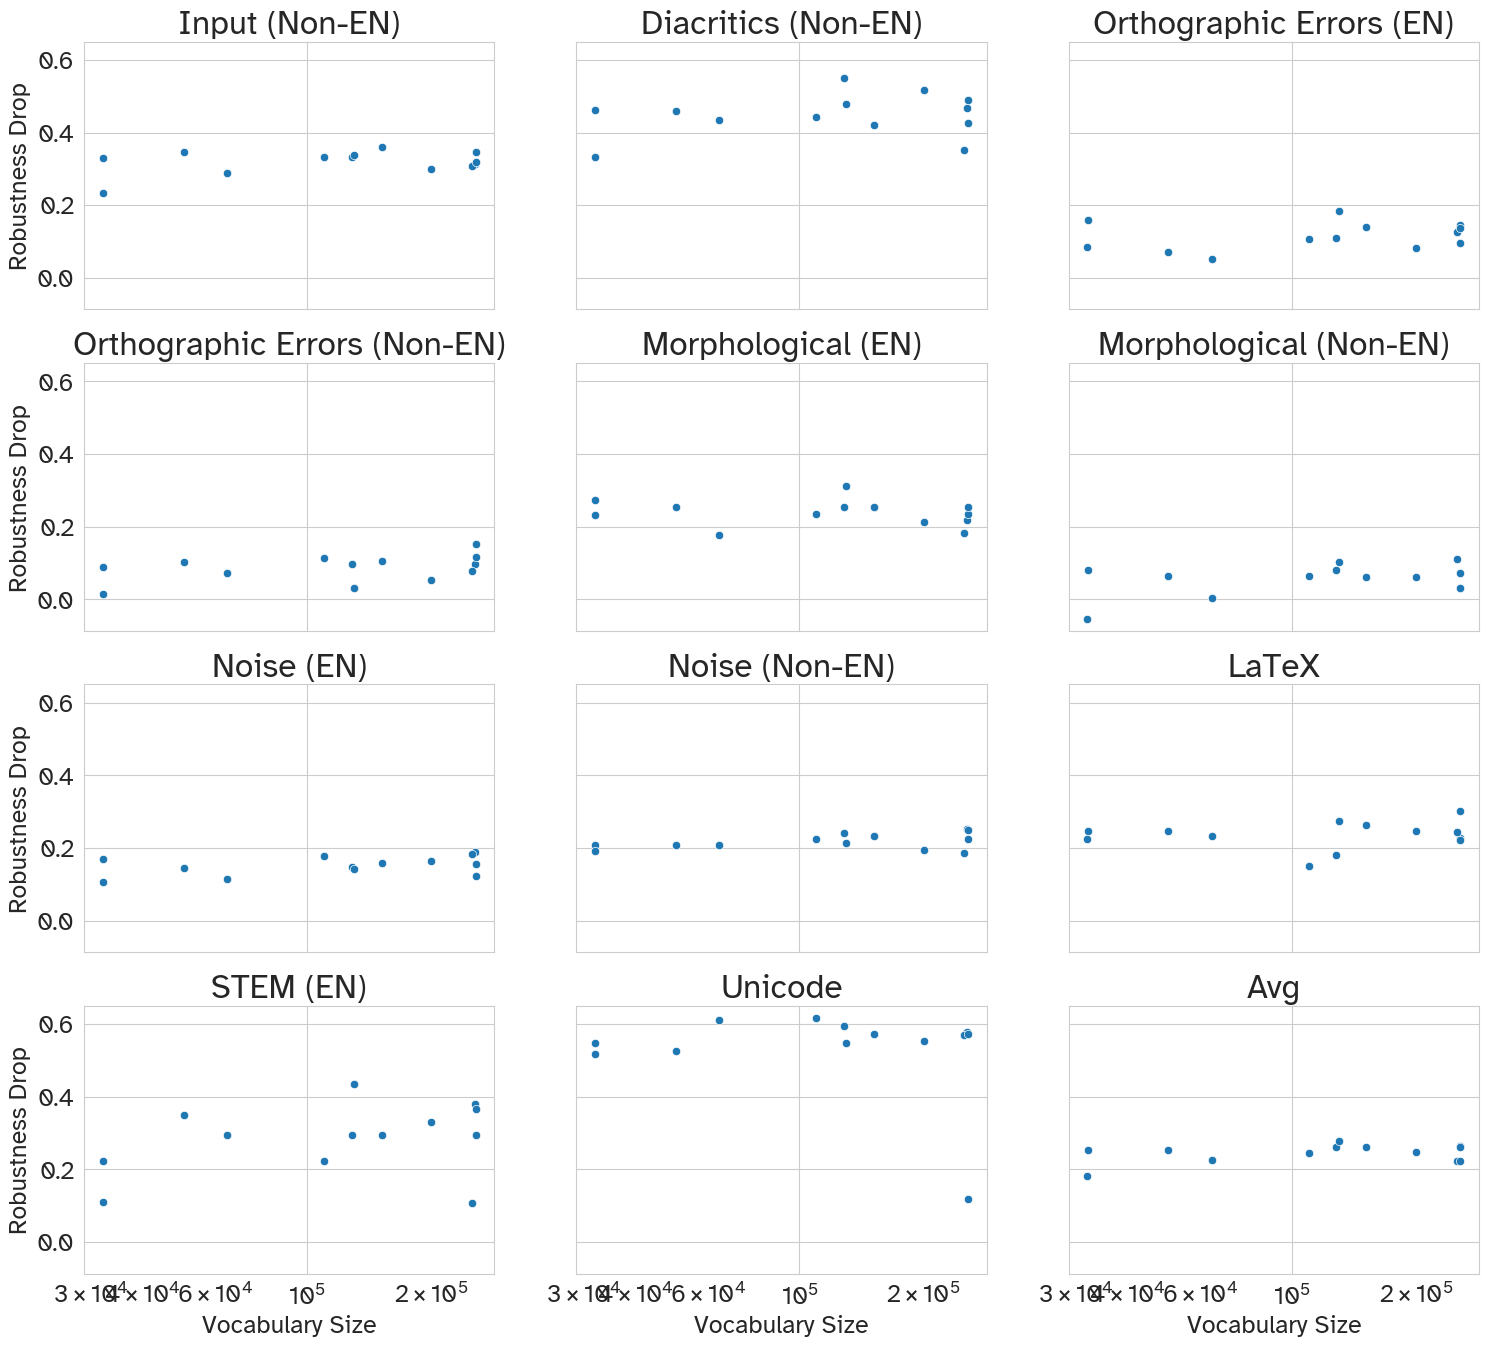

,model_name,vocab_size,Perturbation,Robustness Drop
0,Aya,255029,Input (Non-EN),0.314185
1,BLOOM,250680,Input (Non-EN),0.306891
3,Comma,64000,Input (Non-EN),0.287445
4,GPT-2,50257,Input (Non-EN),0.346613
5,GPT-4o,200000,Input (Non-EN),0.300265
...,...,...,...,...
163,Qwen-3,151646,Avg,0.260544
164,Tekken,130000,Avg,0.277871
165,TokenMonster,32000,Avg,0.181463
166,XGLM,256008,Avg,0.221717


In [63]:
# ax = sns.scatterplot(data=df, x="vocab_size", y="Avg")
# ax.set_xscale("log")
# ax.set_ylabel("Avg Robustness Drop")
# ax.set_xlabel("Vocabulary Size")
pv = df.reset_index(names="model_name", drop=False).melt(id_vars=["model_name", "vocab_size"], var_name="Perturbation", value_name="Robustness Drop")
pv = pv[pv["model_name"] != "ByT5"]

ncols = 3
nrows = math.ceil(len(pv["Perturbation"].unique()) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True, sharey=True)
axs = axs.flatten()
for i, pert in enumerate(pv["Perturbation"].unique()):
    subset = pv[pv["Perturbation"] == pert]
    ax = axs[i]
    sns.scatterplot(data=subset, x="vocab_size", y="Robustness Drop", ax=ax)
    ax.set_xscale("log")
    ax.set_title(pert)
    ax.set_ylabel("Robustness Drop")
    ax.set_xlabel("Vocabulary Size")
plt.show()
pv

## Bootsrap Main Table

In [84]:
math_stem_en_data = all_summaries_filtered[all_summaries_filtered["task_pretty_name"] == "Unusual formatting"]
print(len(math_stem_en_data))
all_summaries_filtered

14


,filtering_mode,model_name,task,task_pretty_name,canonical_count,num_samples,category,langs,acc_norm,acc_norm_std,acc,acc_std,canonical_task_name,canonical_acc,canonical_acc_norm,group_name
0,no_filter,Aya,tokenizer_robustness_completion_math_canonical,Canonical,21,21,,eng_Latn,0.666667,0.483046,0.619048,0.497613,tokenizer_robustness_completion_math_canonical,0.619048,0.666667,tokenizer_robustness_completion_math
1,no_filter,Aya,tokenizer_robustness_completion_math_latex,LaTeX,21,21,Mathematical & Scientific Notation,eng_Latn,0.714286,0.462910,0.571429,0.507093,tokenizer_robustness_completion_math_canonical,0.619048,0.666667,tokenizer_robustness_completion_math
2,no_filter,Aya,tokenizer_robustness_completion_math_spelled_out,Spelled out,21,21,Mathematical & Scientific Notation,eng_Latn,0.285714,0.462910,0.285714,0.462910,tokenizer_robustness_completion_math_canonical,0.619048,0.666667,tokenizer_robustness_completion_math
3,no_filter,Aya,tokenizer_robustness_completion_math_decorativ...,Decorative Unicode,21,21,Mathematical & Scientific Notation,eng_Latn,0.428571,0.507093,0.333333,0.483046,tokenizer_robustness_completion_math_canonical,0.619048,0.666667,tokenizer_robustness_completion_math
4,no_filter,Aya,tokenizer_robustness_completion_math_farsi,Farsi,21,21,Mathematical & Scientific Notation,pes_Arab,0.619048,0.497613,0.523810,0.511766,tokenizer_robustness_completion_farsi_canonical,0.619048,0.666667,tokenizer_robustness_completion_farsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1647,no_filter,mBERT,tokenizer_robustness_completion_stem_upside_do...,Upside Down/Rotated,16,17,Structural Text Elements,eng_Latn,0.176471,0.392953,0.235294,0.437237,tokenizer_robustness_completion_stem_canonical,0.875000,0.750000,tokenizer_robustness_completion_stem
1648,no_filter,mBERT,tokenizer_robustness_completion_stem_spelled_out,Spelled out,17,25,Mathematical & Scientific Notation,eng_Latn,0.680000,0.476095,0.680000,0.476095,tokenizer_robustness_completion_stem_canonical,0.823529,0.882353,tokenizer_robustness_completion_stem
1649,no_filter,mBERT,tokenizer_robustness_completion_stem_unusual_f...,Unusual formatting,13,16,Structural Text Elements,eng_Latn,0.687500,0.478714,0.437500,0.512348,tokenizer_robustness_completion_stem_canonical,0.846154,1.000000,tokenizer_robustness_completion_stem
1650,no_filter,mBERT,tokenizer_robustness_completion_stem_latex,LaTeX,23,68,Mathematical & Scientific Notation,eng_Latn,0.691176,0.465443,0.500000,0.503718,tokenizer_robustness_completion_stem_canonical,0.826087,0.913043,tokenizer_robustness_completion_stem


In [64]:

import random
from utils import load_df_from_jsonl, remove_duplicates_from_samples
SEED = 42
NSAMPLES=int(100e2)
random.seed(SEED)
np.random.seed(SEED)

BOOTSTRAP_DIR = OUTPUT_DIR / "bootstrap-corrected"
(BOOTSTRAP_DIR).mkdir(exist_ok=True, parents=True)
bootstrap_dfs = []
SAVE_BOOTSTRAP_DFS = False
# SAVE_BOOTSTRAP_DFS = True
all_samples_filtered = remove_duplicates_from_samples(all_samples)

## prefilter dupicates
RUN_BOOTS = False
# RUN_BOOTS = True
if RUN_BOOTS:
    for ind in range(NSAMPLES):
        # frac should be 1.0 for bootstrap sampling with replacement and still have N samples
        all_samples_ = all_samples_filtered.sample(frac=1.0, replace=True, random_state=random.randint(0, 100000)).reset_index(drop=True)
        all_summaries_ = get_summaries(all_samples_, subcategories=None, filters_to_process=[FILTER], remove_duplicates=False)
        # Generate robustness data and save to JSONL
        canonical_by_task = get_canonical_by_task(all_summaries_, FILTER)
        robustness_data = generate_robustness_latex_table_dict(all_summaries_, canonical_by_task, FILTER, latex_table_categories=latex_table_categories, group_langs=True)
        # robustness_data= robustness_data["raw_dataframe"]
        bootstrap_dfs.append(robustness_data)
        if ind % 1000 == 0:
            print(f"Bootstrap sample {ind} processed.")
        if SAVE_BOOTSTRAP_DFS:
            jsonl_file = save_to_jsonl(robustness_data, BOOTSTRAP_DIR / f"bootstrap_{ind}.jsonl")
else:
    print("Loading previously saved bootstrap samples.")
    for i, jsonl_file in enumerate(BOOTSTRAP_DIR.rglob("bootstrap_*.jsonl")):
        robustness_data = load_df_from_jsonl(jsonl_file)
        # robustness_data['sample_id'] = i
        bootstrap_dfs.append(robustness_data)



N duplicates: 30604
Loading previously saved bootstrap samples.


In [117]:
## look at one single df (last one)
robustness_data

{'data': {'Comma': {'Input (Non-EN)': 0.2852078928823115,
   'Diacritics (Non-EN)': 0.4857142857142857,
   'Orthographic Errors (EN)': 0.11666666666666664,
   'Orthographic Errors (Non-EN)': 0.012203684979215808,
   'Morphological (EN)': 0.18518518518518523,
   'Morphological (Non-EN)': -0.0811627906976745,
   'Noise (EN)': 0.12745098039215685,
   'Noise (Non-EN)': 0.19428294573643412,
   'LaTeX': 0.18452380952380945,
   'STEM (EN)': 0.3984962406015038,
   'Unicode': 0.6331932773109243},
  'GPT-2': {'Input (Non-EN)': 0.3273749800923714,
   'Diacritics (Non-EN)': 0.5323529411764706,
   'Orthographic Errors (EN)': 0.09169230769230764,
   'Orthographic Errors (Non-EN)': 0.10025031571351255,
   'Morphological (EN)': 0.30615384615384617,
   'Morphological (Non-EN)': 0.09146933229813661,
   'Noise (EN)': 0.17263137291261038,
   'Noise (Non-EN)': 0.22034698093717722,
   'LaTeX': 0.3510881737182921,
   'STEM (EN)': 0.5739130434782609,
   'Unicode': 0.5452922750486899},
  'Tekken': {'Input (Non

In [65]:
# robustness_data['raw_dataframe']
# # bootstrap_dfs = [x["raw_dataframe"] for x in bootstrap_dfs]
# bootstrap_dfs[-1]
# bootstrap_combined_df
# robustness_data = robustness_data["raw_dataframe"]
robustness_data
bootstrap_dfs

[              Input (Non-EN)  Diacritics (Non-EN)  Orthographic Errors (EN)  \
 model_name                                                                    
 BLOOM               0.315770             0.320330                  0.129310   
 Llama-3.2           0.325757             0.447256                  0.122951   
 Tekken              0.299274             0.488293                  0.154877   
 GPT-4o              0.334146             0.679763                  0.069919   
 Aya                 0.424582             0.552682                  0.182314   
 mBERT               0.305472             0.453640                  0.141414   
 Comma               0.275056             0.367089                  0.092500   
 Qwen-3              0.378562             0.437980                  0.147826   
 Gemma-2             0.332103             0.393182                  0.122726   
 TokenMonster        0.276256             0.384581                 -0.031322   
 Phi-3               0.347980           

In [68]:
set([type(d) for d in bootstrap_dfs])
try:
    bootstrap_dfs_ = [df["raw_dataframe"] for df in bootstrap_dfs]
except:
    bootstrap_dfs_ = bootstrap_dfs

In [69]:

# 1. Add a sample ID column to each DataFrame and combine them
bootstrap_combined_df = pd.concat(
    bootstrap_dfs_, 
    keys=range(len(bootstrap_dfs)),
    names=['sample_id', 'model_name']
)

bootstrap_combined_df = bootstrap_combined_df[robustness_data.columns]
bootstrap_combined_df = bootstrap_combined_df.reset_index()

In [70]:
bootstrap_combined_df

,sample_id,model_name,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode
0,0,BLOOM,0.315770,0.320330,0.129310,0.012324,0.127273,0.005938,0.217590,0.157503,0.403624,0.061654,0.548623
1,0,Llama-3.2,0.325757,0.447256,0.122951,0.029600,0.226415,0.047113,0.135531,0.211429,0.203934,0.401361,0.574539
2,0,Tekken,0.299274,0.488293,0.154877,0.012341,0.238795,0.124046,0.120224,0.229980,0.264603,0.444947,0.577853
3,0,GPT-4o,0.334146,0.679763,0.069919,0.174359,0.157812,0.046296,0.103462,0.273399,0.068641,0.065183,0.547579
4,0,Aya,0.424582,0.552682,0.182314,0.153582,0.171250,0.045228,0.187877,0.189370,0.271130,0.561670,0.625430
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,9999,GPT-2,0.448140,0.510768,0.166667,0.146434,0.321429,0.070007,0.153471,0.253892,0.094063,0.502052,0.557080
139996,9999,Gemma-2,0.317589,0.361881,0.148884,0.161935,0.094583,-0.026547,0.156174,0.270894,0.126506,0.166667,0.495546
139997,9999,GPT-4o,0.306597,0.632418,0.072009,0.033798,0.253102,-0.024784,0.179553,0.160905,0.302982,0.693333,0.605849
139998,9999,Phi-3,0.318804,0.462081,0.042912,0.060925,0.188081,0.001254,0.168971,0.228464,0.194048,0.419608,0.551830


In [233]:
pv["vocab_size"].unique()
stats

,model_name,mean,std,q95,q05
0,Aya,0.576044,0.047309,0.662988,0.476172
1,BLOOM,0.567425,0.047302,0.656579,0.472653
2,ByT5,0.530227,0.049295,0.620028,0.428378
3,Comma,0.612049,0.044825,0.698543,0.523542
4,GPT-2,0.526067,0.048415,0.617243,0.427641
5,GPT-4o,0.552046,0.042749,0.630820,0.465029
6,Gemma-2,0.573291,0.045737,0.661154,0.481786
7,Llama-3.2,0.593787,0.045254,0.680425,0.503311
8,Phi-3,0.545472,0.046744,0.634934,0.447573
9,Qwen-3,0.573787,0.044441,0.658884,0.483876


### Bootstrap Figure

Figure saved to /Users/gsaltintas/code/phd/tokenizers/notebooks/output/results-v5/summary-rebuttal/all/robustness_bootstrap_errorbars.pdf


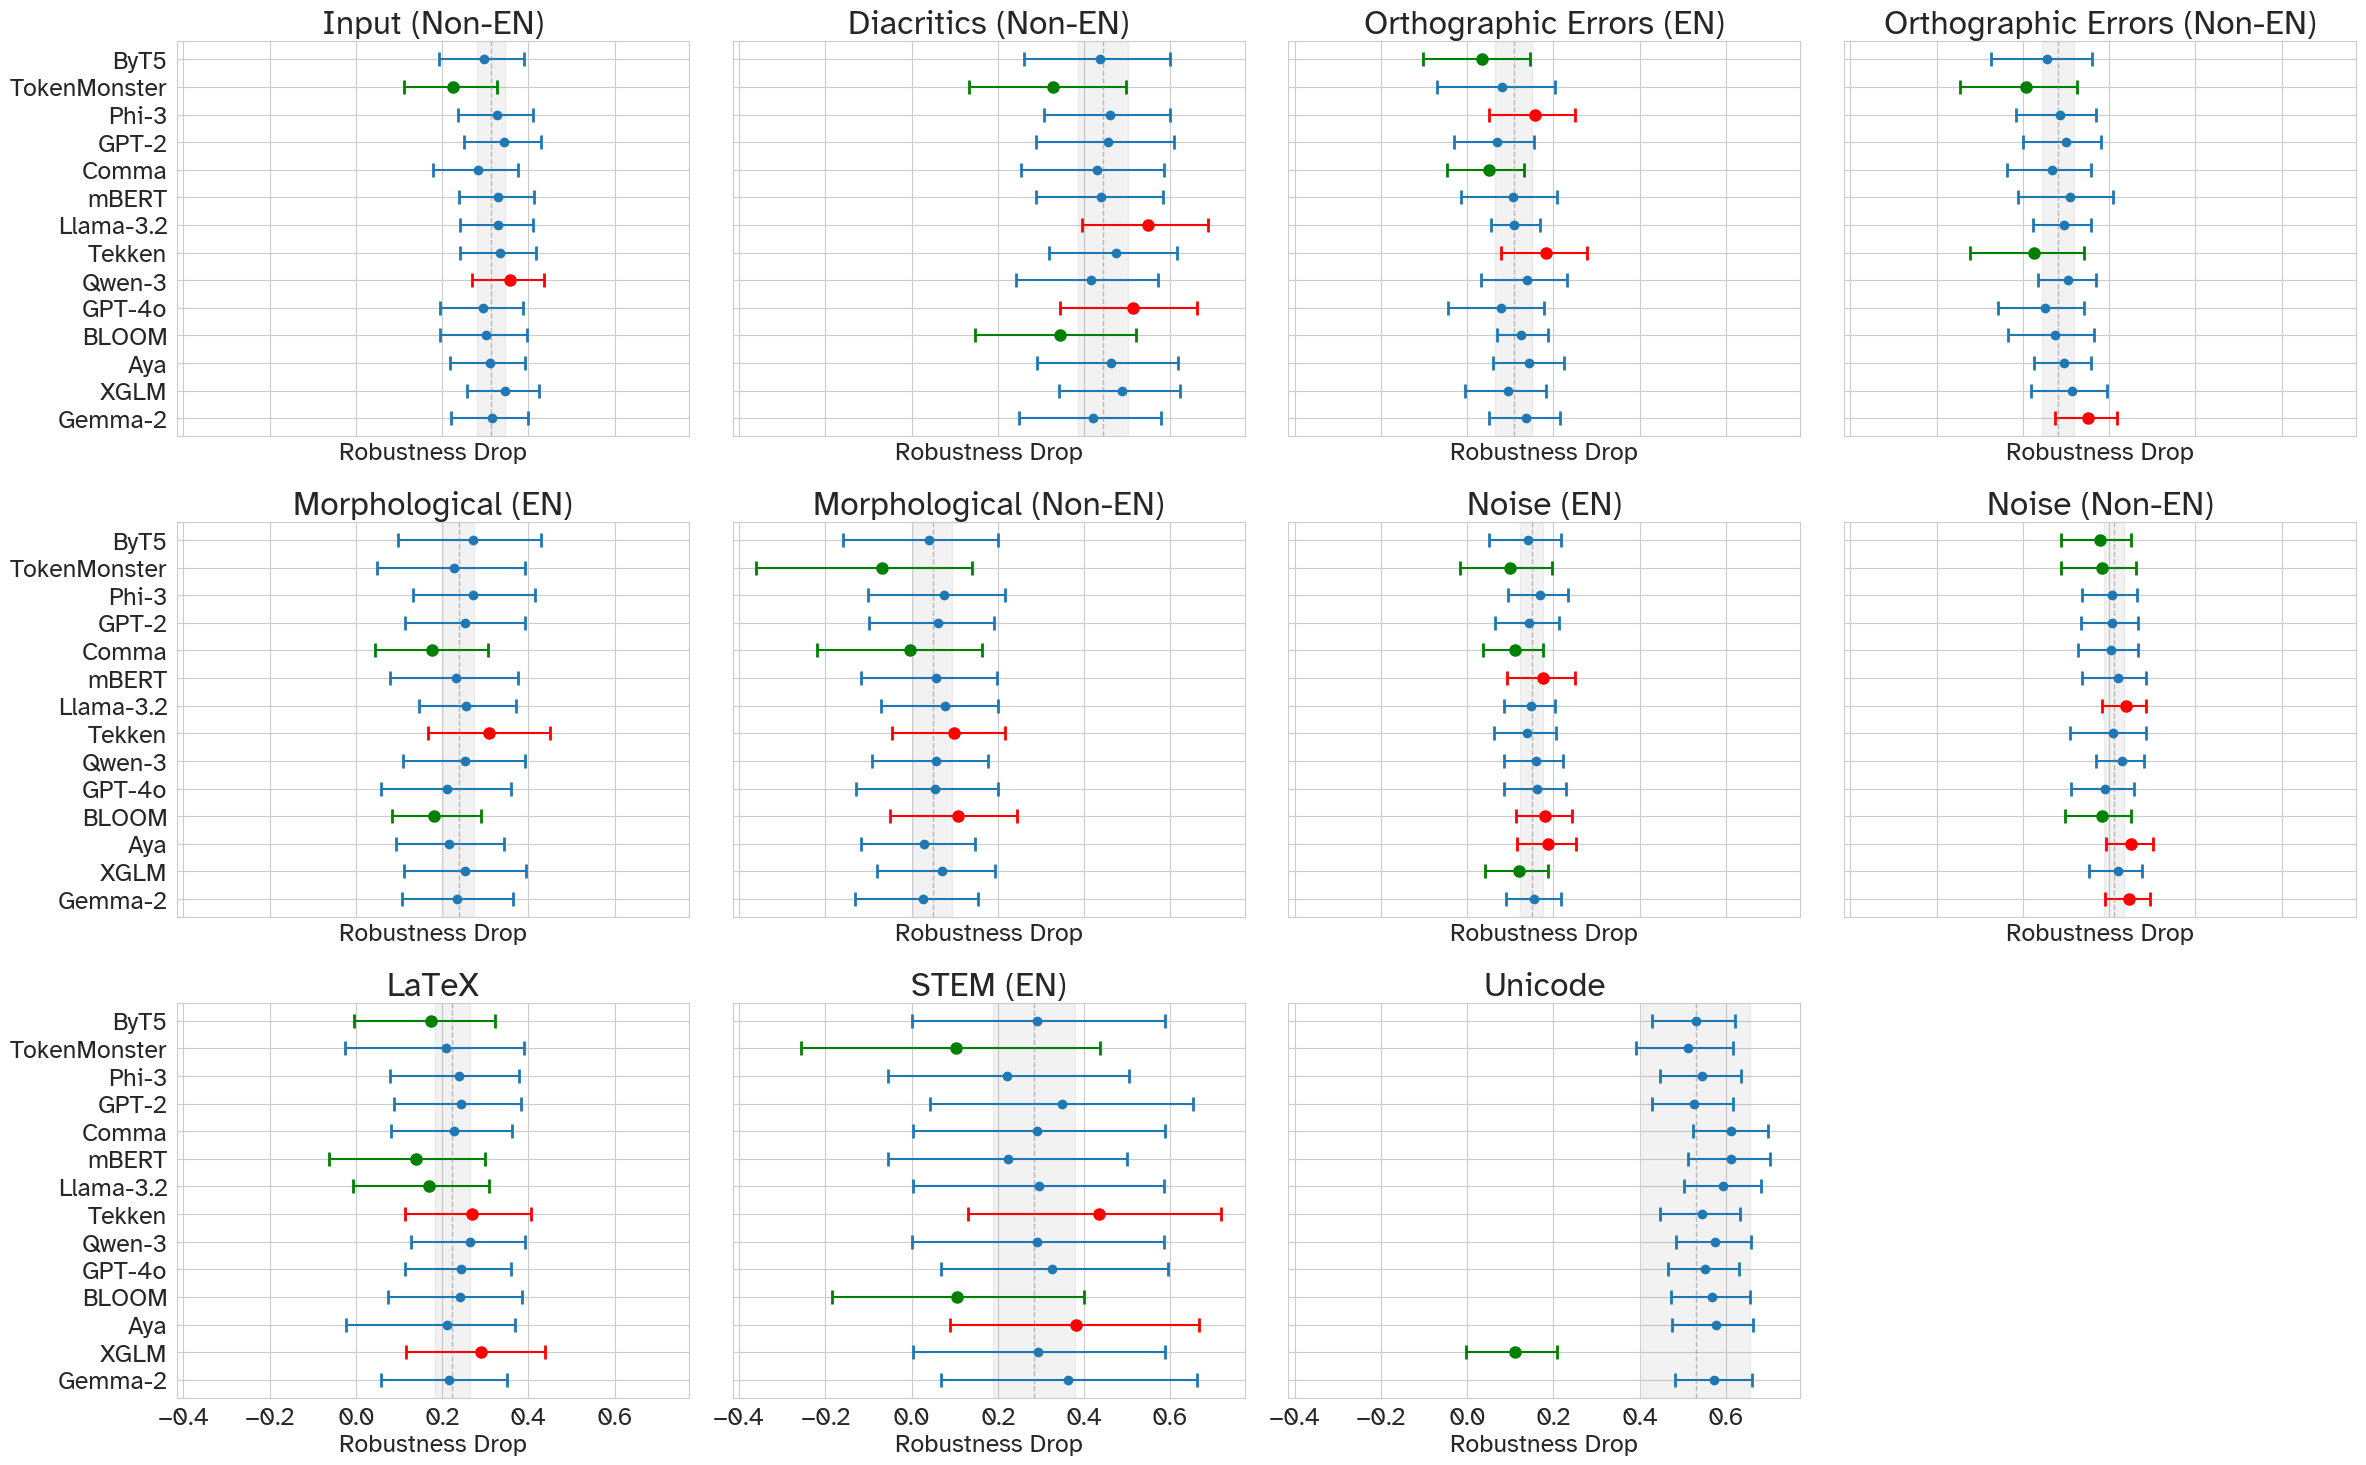

In [240]:
bootstrap_combined_df["vocab_size"] = bootstrap_combined_df["model_name"].map(lambda x: VOCAB_SIZES_PRETTY_NAME.get(x, np.nan))
pv = bootstrap_combined_df.melt(id_vars=["model_name", "vocab_size", "sample_id"], var_name="Perturbation", value_name="Robustness Drop")
pv = pv.sort_values("vocab_size", ascending=True)

ncols = 4
nrows = math.ceil(len(pv["Perturbation"].unique()) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
axs = axs.flatten()

# for i, pert in enumerate(pv["Perturbation"].unique()):
for i, pert in enumerate(latex_table_categories.keys()):
    subset = pv[pv["Perturbation"] == pert]
    ax = axs[i]
    
    # Calculate statistics for each model
    stats = subset.groupby(["model_name", "vocab_size"])["Robustness Drop"].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('q95', lambda x: x.quantile(0.975)),
        ('q05', lambda x: x.quantile(0.025))
    ]).reset_index()
    stats = stats.sort_values("vocab_size", ascending=False)
    
    # Calculate error bar values (distance from mean to quantiles)
    stats['upper_err'] = stats['q95'] - stats['mean']
    stats['lower_err'] = stats['mean'] - stats['q05']
    
    # Calculate overall mean and std across all models for this perturbation
    overall_mean = stats['mean'].mean()
    overall_std = stats['mean'].std()
    
    # Determine significance and direction
    stats['deviation'] = stats['mean'] - overall_mean
    stats['significant'] = np.abs(stats['deviation']) > overall_std
    
    # Plot with different colors based on significance and direction
    for idx, row in stats.iterrows():
        if row['significant']:
            if row['deviation'] < 0:  # Less drop = better = green
                color = 'green'
            else:  # More drop = worse = red
                color = 'red'
            marker_size = 8
        else:
            color = 'C0'  # Default blue
            marker_size = 6
            
        ax.errorbar(row['mean'], row['model_name'], 
                    xerr=[[row['lower_err']], [row['upper_err']]],
                    fmt='o', capsize=5, capthick=2, markersize=marker_size,
                    color=color, ecolor=color)
    
    # Add vertical line at overall mean
    ax.axvline(overall_mean, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Add shaded region for ±1 std
    ax.axvspan(overall_mean - overall_std, overall_mean + overall_std, 
               alpha=0.1, color='gray')
    
    ax.set_title(pert)
    ax.set_xlabel("Robustness Drop")
    ax.set_ylabel("")

# Hide empty subplots if any
for j in range(len(pv["Perturbation"].unique()), len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_bootstrap_errorbars.pdf", dpi=300)
print(f"Figure saved to {OUTPUT_DIR.absolute() / 'robustness_bootstrap_errorbars.pdf'}")
plt.show()

### Bootsrap by Vocab Size

Figure saved to /Users/gsaltintas/code/phd/tokenizers/notebooks/output/results-v5/summary-rebuttal/all/robustness_bootstrap_errorbars_by_vocab_bucket.pdf


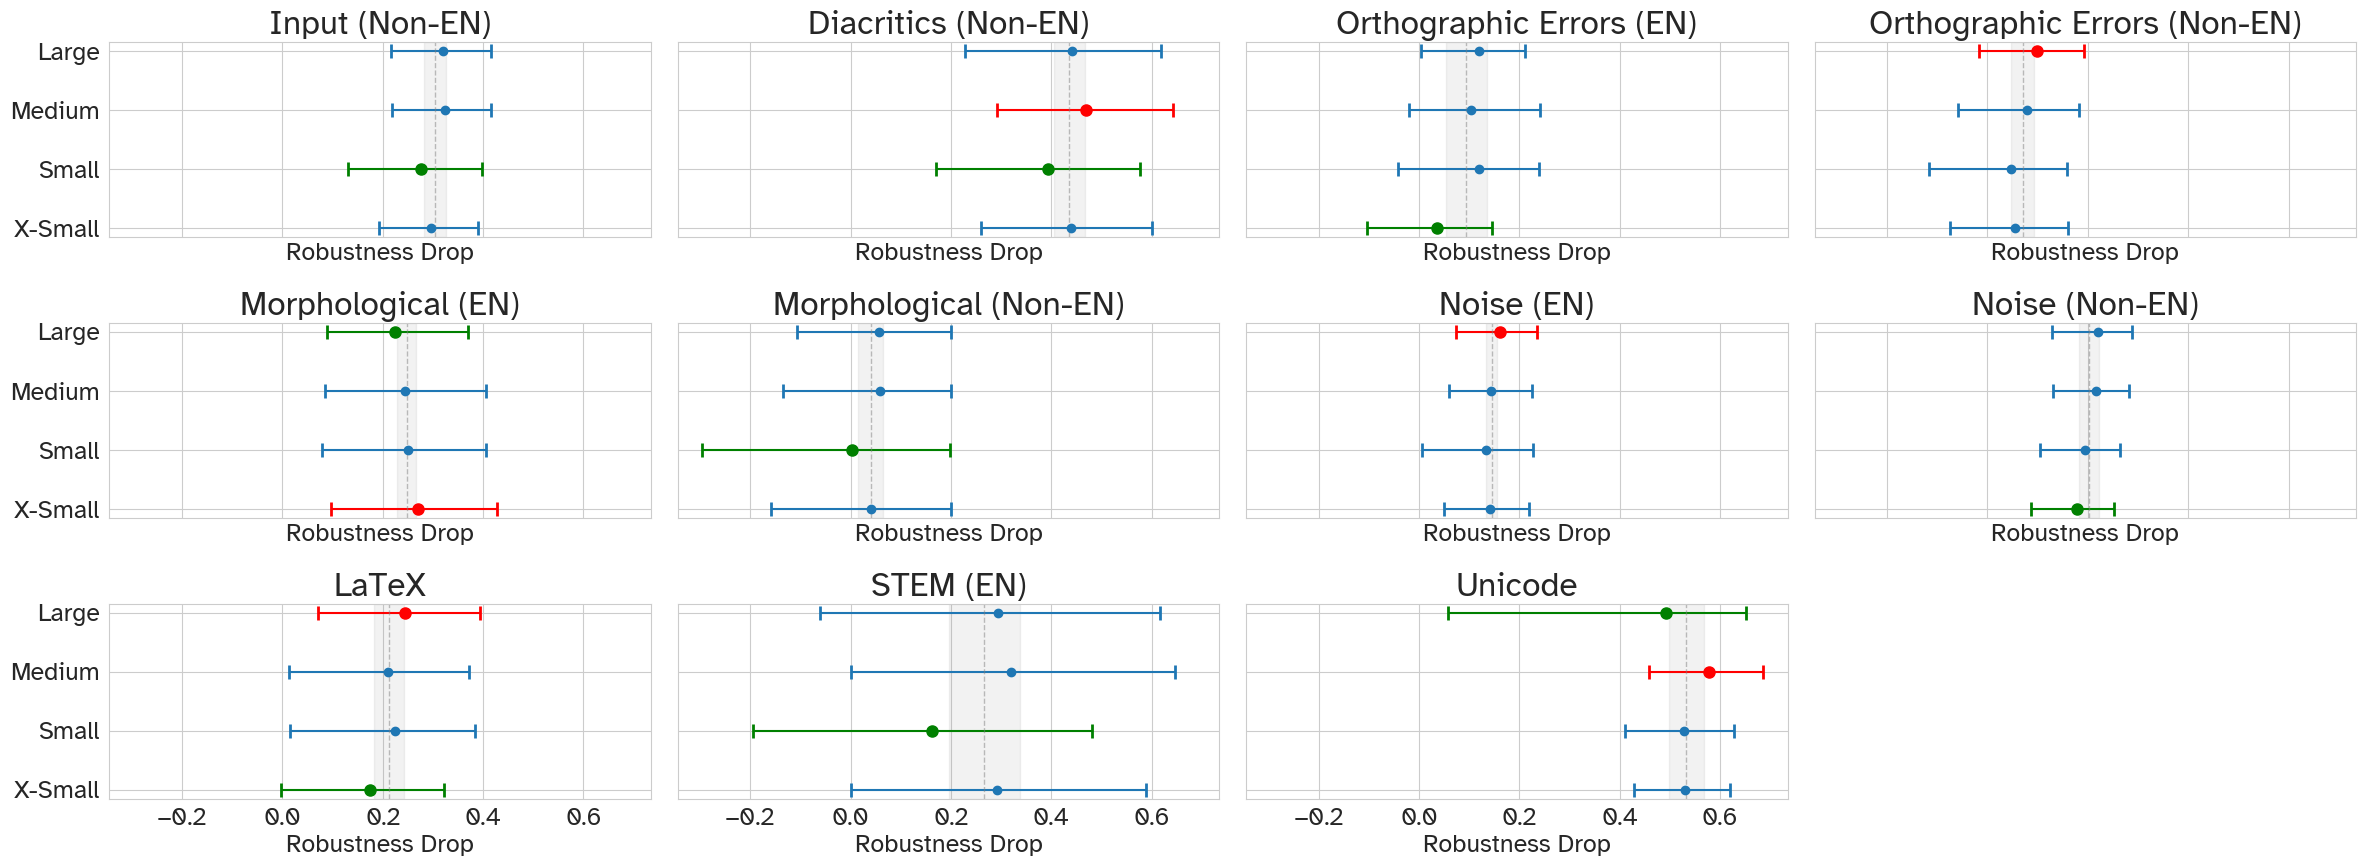

In [247]:
from xarch_tokenizers.logging.report_utils import VOCAB_BUCKETS_PRETTY_NAME


bootstrap_combined_df["vocab_bucket"] = bootstrap_combined_df["model_name"].map(lambda x: VOCAB_BUCKETS_PRETTY_NAME.get(x, np.nan))
pv = bootstrap_combined_df.melt(id_vars=["model_name", "vocab_bucket", "sample_id"], var_name="Perturbation", value_name="Robustness Drop")
pv = pv.sort_values("vocab_bucket", ascending=True)

ncols = 4
nrows = math.ceil(len(pv["Perturbation"].unique()) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * nrows), sharex=True, sharey=True)
axs = axs.flatten()

# for i, pert in enumerate(pv["Perturbation"].unique()):
keys = latex_table_categories.keys()
for i, pert in enumerate(keys):
    subset = pv[pv["Perturbation"] == pert]
    ax = axs[i]
    
    # Calculate statistics for each model
    stats = subset.groupby(["vocab_bucket"])["Robustness Drop"].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('q95', lambda x: x.quantile(0.975)),
        ('q05', lambda x: x.quantile(0.025))
    ]).reset_index()
    stats = stats.sort_values("vocab_bucket", ascending=False)
    
    # Calculate error bar values (distance from mean to quantiles)
    stats['upper_err'] = stats['q95'] - stats['mean']
    stats['lower_err'] = stats['mean'] - stats['q05']
    
    # Calculate overall mean and std across all models for this perturbation
    overall_mean = stats['mean'].mean()
    overall_std = stats['mean'].std()
    
    # Determine significance and direction
    stats['deviation'] = stats['mean'] - overall_mean
    stats['significant'] = np.abs(stats['deviation']) > overall_std
    
    # Plot with different colors based on significance and direction
    for idx, row in stats.iterrows():
        if row['significant']:
            if row['deviation'] < 0:  # Less drop = better = green
                color = 'green'
            else:  # More drop = worse = red
                color = 'red'
            marker_size = 8
        else:
            color = 'C0'  # Default blue
            marker_size = 6
            
        ax.errorbar(row['mean'], row['vocab_bucket'], 
                    xerr=[[row['lower_err']], [row['upper_err']]],
                    fmt='o', capsize=5, capthick=2, markersize=marker_size,
                    color=color, ecolor=color)
    
    # Add vertical line at overall mean
    ax.axvline(overall_mean, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Add shaded region for ±1 std
    ax.axvspan(overall_mean - overall_std, overall_mean + overall_std, 
               alpha=0.1, color='gray')
    
    ax.set_title(pert)
    ax.set_xlabel("Robustness Drop")
    ax.set_ylabel("")

# Hide empty subplots if any
for j in range(len(keys), len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_bootstrap_errorbars_by_vocab_bucket.pdf", dpi=300)
print(f"Figure saved to {OUTPUT_DIR.absolute() / 'robustness_bootstrap_errorbars_by_vocab_bucket.pdf'}")
plt.show()

Figure saved to /Users/gsaltintas/code/phd/tokenizers/notebooks/output/results-v5/summary-rebuttal/all/robustness_bootstrap_errorbars_by_algorithm.pdf


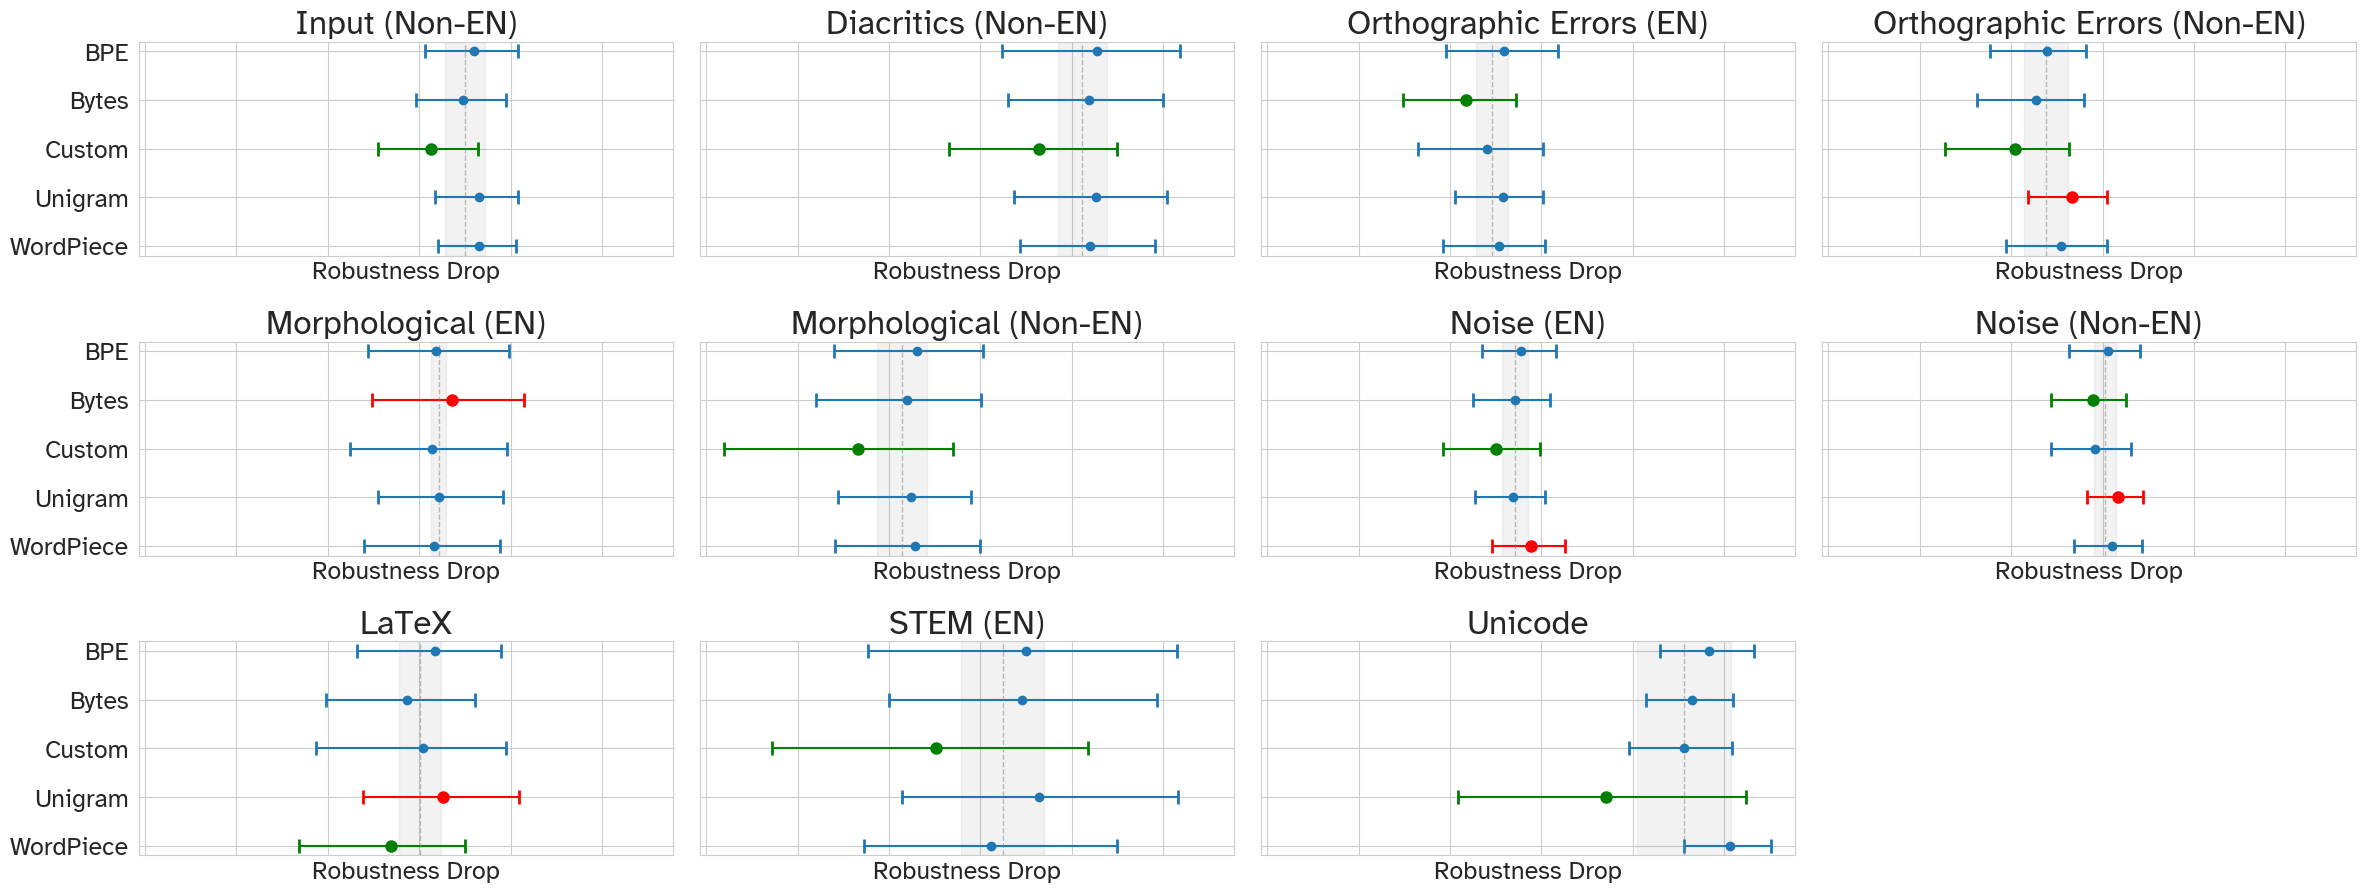

In [248]:
from xarch_tokenizers.logging.report_utils import ALGORITHM_PRETTY_NAME


bootstrap_combined_df["algorithm"] = bootstrap_combined_df["model_name"].map(lambda x: ALGORITHM_PRETTY_NAME.get(x, np.nan))
pv = bootstrap_combined_df.melt(id_vars=["model_name", "algorithm", "sample_id"], var_name="Perturbation", value_name="Robustness Drop")
pv = pv.sort_values("algorithm", ascending=True)

ncols = 4
nrows = math.ceil(len(pv["Perturbation"].unique()) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * nrows), sharex=True, sharey=True)
axs = axs.flatten()

# for i, pert in enumerate(pv["Perturbation"].unique()):
keys = latex_table_categories.keys()
for i, pert in enumerate(keys):
    subset = pv[pv["Perturbation"] == pert]
    ax = axs[i]
    
    # Calculate statistics for each model
    stats = subset.groupby(["algorithm"])["Robustness Drop"].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('q95', lambda x: x.quantile(0.975)),
        ('q05', lambda x: x.quantile(0.025))
    ]).reset_index()
    stats = stats.sort_values("algorithm", ascending=False)
    
    # Calculate error bar values (distance from mean to quantiles)
    stats['upper_err'] = stats['q95'] - stats['mean']
    stats['lower_err'] = stats['mean'] - stats['q05']
    
    # Calculate overall mean and std across all models for this perturbation
    overall_mean = stats['mean'].mean()
    overall_std = stats['mean'].std()
    
    # Determine significance and direction
    stats['deviation'] = stats['mean'] - overall_mean
    stats['significant'] = np.abs(stats['deviation']) > overall_std
    
    # Plot with different colors based on significance and direction
    for idx, row in stats.iterrows():
        if row['significant']:
            if row['deviation'] < 0:  # Less drop = better = green
                color = 'green'
            else:  # More drop = worse = red
                color = 'red'
            marker_size = 8
        else:
            color = 'C0'  # Default blue
            marker_size = 6
            
        ax.errorbar(row['mean'], row['algorithm'], 
                    xerr=[[row['lower_err']], [row['upper_err']]],
                    fmt='o', capsize=5, capthick=2, markersize=marker_size,
                    color=color, ecolor=color)
    
    # Add vertical line at overall mean
    ax.axvline(overall_mean, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Add shaded region for ±1 std
    ax.axvspan(overall_mean - overall_std, overall_mean + overall_std, 
               alpha=0.1, color='gray')
    
    ax.set_title(pert)
    ax.set_xlabel("Robustness Drop")
    ax.set_ylabel("")

# Hide empty subplots if any
for j in range(len(keys), len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_bootstrap_errorbars_by_algorithm.pdf", dpi=300)
print(f"Figure saved to {OUTPUT_DIR.absolute() / 'robustness_bootstrap_errorbars_by_algorithm.pdf'}")
plt.show()

Figure saved to /Users/gsaltintas/code/phd/tokenizers/notebooks/output/results-v5/summary-rebuttal/all/robustness_bootstrap_errorbars_by_pretokenization.pdf


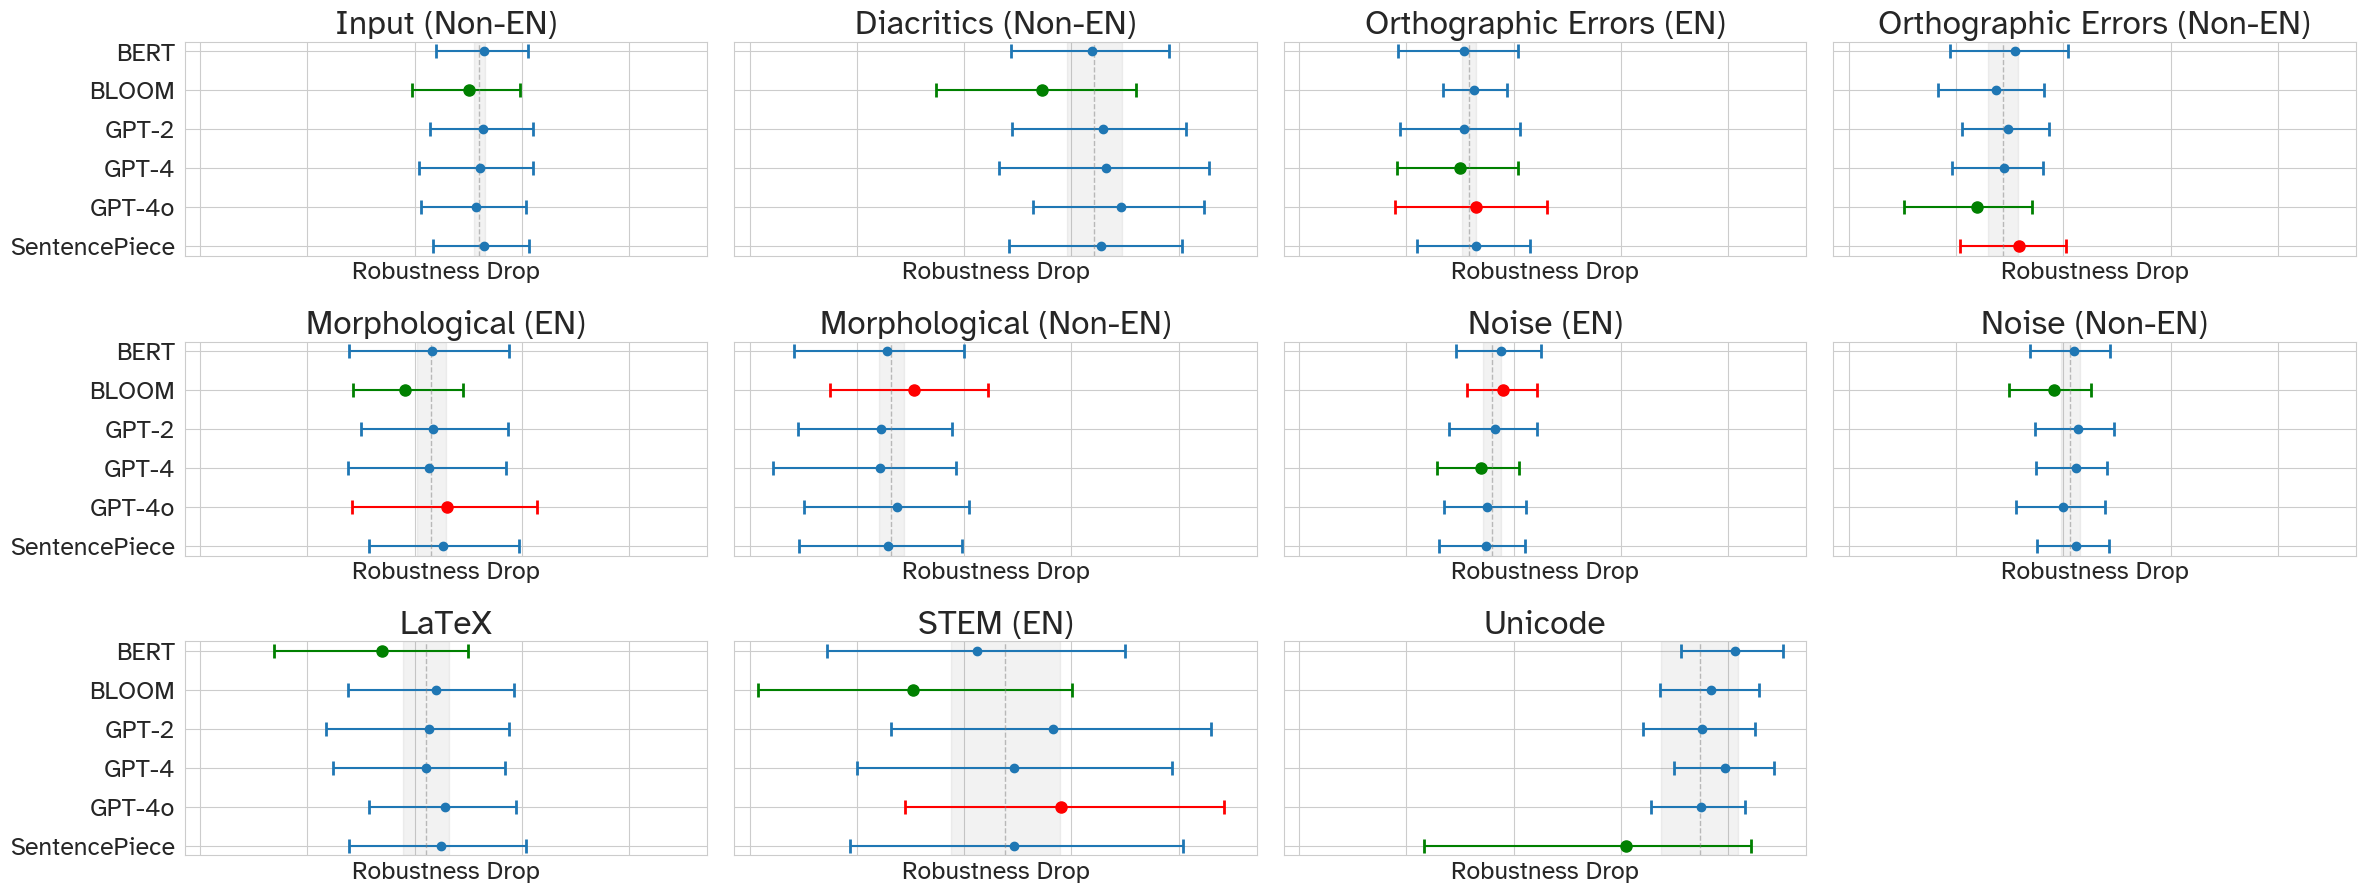

In [250]:
from xarch_tokenizers.logging.report_utils import PRETOKENIZATION_PRETTY_NAME


bootstrap_combined_df["pretokenization"] = bootstrap_combined_df["model_name"].map(lambda x: PRETOKENIZATION_PRETTY_NAME.get(x, np.nan))
pv = bootstrap_combined_df.melt(id_vars=["model_name", "pretokenization", "sample_id"], var_name="Perturbation", value_name="Robustness Drop")
pv = pv.sort_values("pretokenization", ascending=True)

ncols = 4
nrows = math.ceil(len(pv["Perturbation"].unique()) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * nrows), sharex=True, sharey=True)
axs = axs.flatten()

# for i, pert in enumerate(pv["Perturbation"].unique()):
keys = latex_table_categories.keys()
for i, pert in enumerate(keys):
    subset = pv[pv["Perturbation"] == pert]
    ax = axs[i]
    
    # Calculate statistics for each model
    stats = subset.groupby(["pretokenization"])["Robustness Drop"].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('q95', lambda x: x.quantile(0.975)),
        ('q05', lambda x: x.quantile(0.025))
    ]).reset_index()
    stats = stats.sort_values("pretokenization", ascending=False)
    
    # Calculate error bar values (distance from mean to quantiles)
    stats['upper_err'] = stats['q95'] - stats['mean']
    stats['lower_err'] = stats['mean'] - stats['q05']
    
    # Calculate overall mean and std across all models for this perturbation
    overall_mean = stats['mean'].mean()
    overall_std = stats['mean'].std()
    
    # Determine significance and direction
    stats['deviation'] = stats['mean'] - overall_mean
    stats['significant'] = np.abs(stats['deviation']) > overall_std
    
    # Plot with different colors based on significance and direction
    for idx, row in stats.iterrows():
        if row['significant']:
            if row['deviation'] < 0:  # Less drop = better = green
                color = 'green'
            else:  # More drop = worse = red
                color = 'red'
            marker_size = 8
        else:
            color = 'C0'  # Default blue
            marker_size = 6
            
        ax.errorbar(row['mean'], row['pretokenization'], 
                    xerr=[[row['lower_err']], [row['upper_err']]],
                    fmt='o', capsize=5, capthick=2, markersize=marker_size,
                    color=color, ecolor=color)
    
    # Add vertical line at overall mean
    ax.axvline(overall_mean, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Add shaded region for ±1 std
    ax.axvspan(overall_mean - overall_std, overall_mean + overall_std, 
               alpha=0.1, color='gray')
    
    ax.set_title(pert)
    ax.set_xlabel("Robustness Drop")
    ax.set_ylabel("")

# Hide empty subplots if any
for j in range(len(keys), len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_bootstrap_errorbars_by_pretokenization.pdf", dpi=300)
print(f"Figure saved to {OUTPUT_DIR.absolute() / 'robustness_bootstrap_errorbars_by_pretokenization.pdf'}")
plt.show()

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_15279/3537304417.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


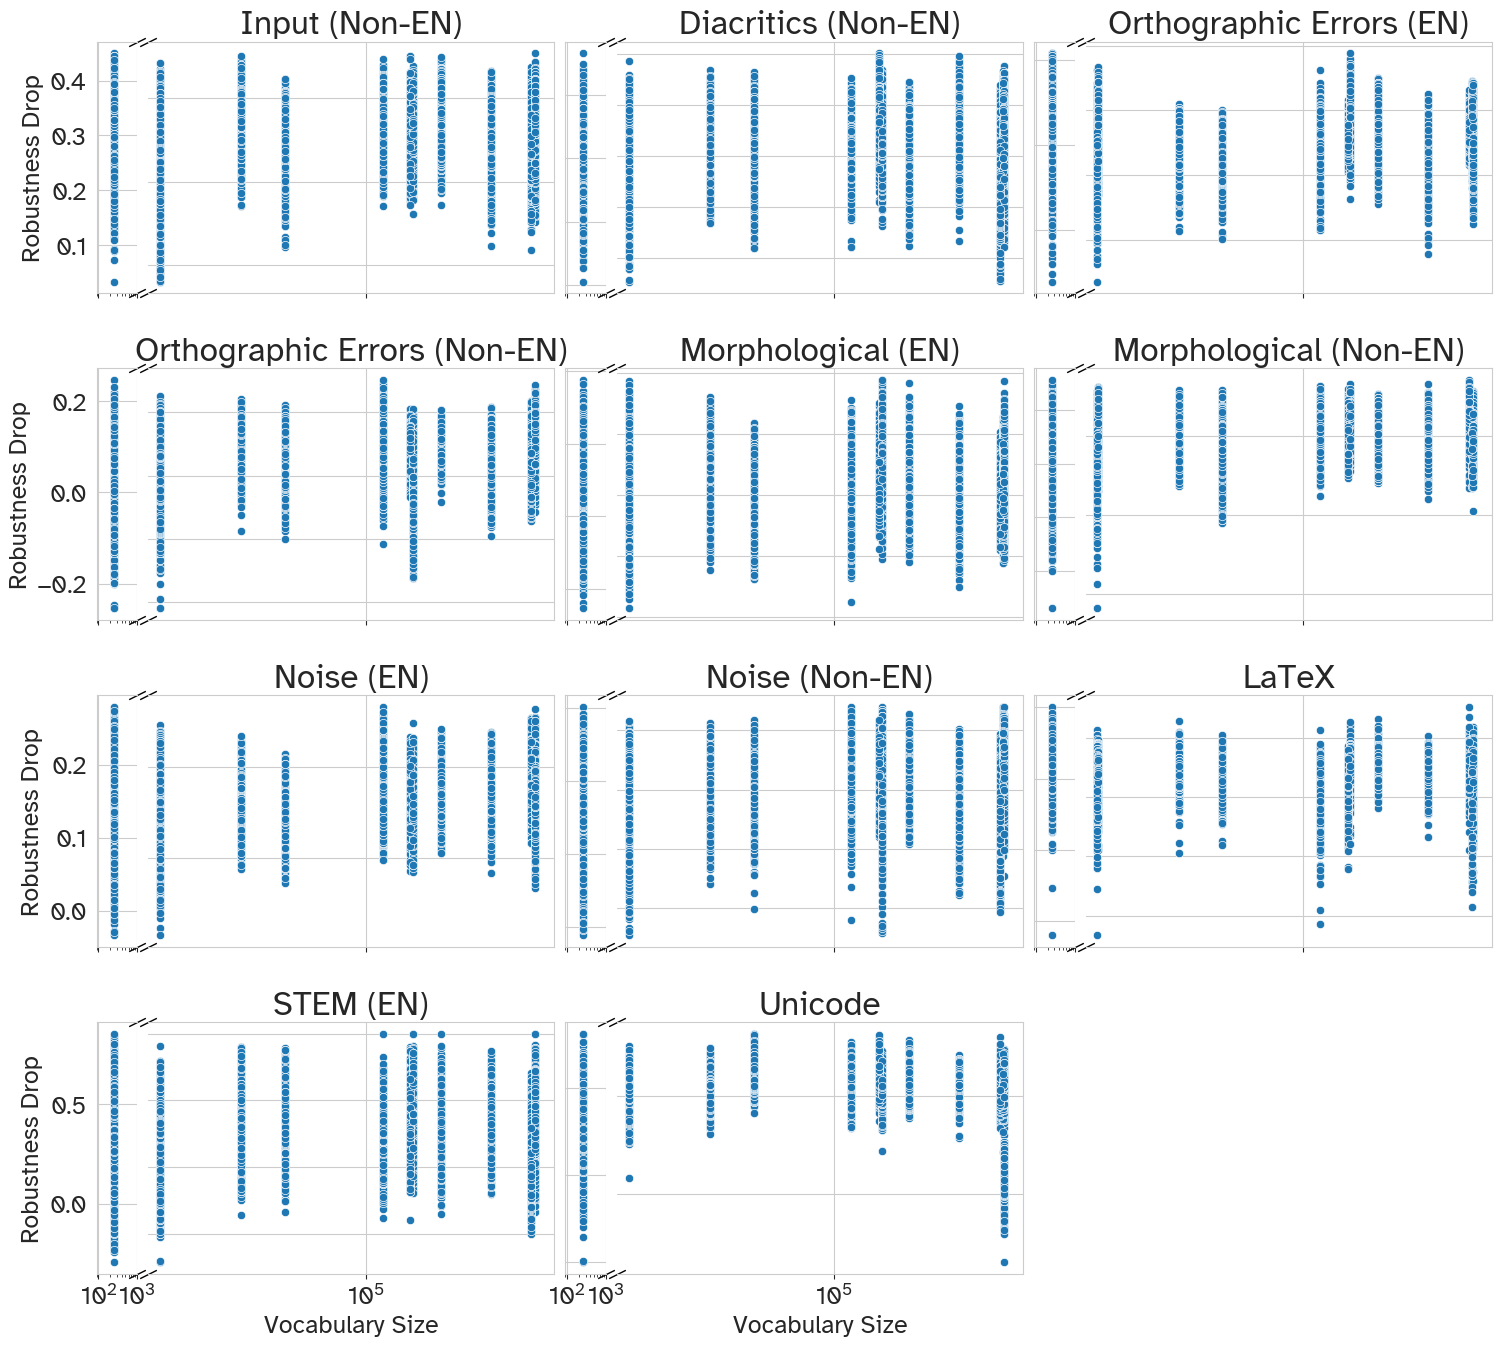

In [114]:
from matplotlib.gridspec import GridSpec

ncols = 3
nrows = math.ceil(len(pv["Perturbation"].unique()) / ncols)
fig = plt.figure(figsize=(6 * ncols, 4 * nrows))

# Create GridSpec with width ratios: 1 for left plots, 10 for right plots
gs = GridSpec(nrows, ncols*2, figure=fig, wspace=0.05, hspace=0.3,
              width_ratios=[1, 10] * ncols)

axs = []
for row in range(nrows):
    for col in range(ncols*2):
        axs.append(fig.add_subplot(gs[row, col]))

perturbations = pv["Perturbation"].unique()
for i, pert in enumerate(perturbations):
    subset = pv[pv["Perturbation"] == pert]
    ax1 = axs[2*i]
    ax2 = axs[2*i + 1]
    ax1.set_xscale("log")
    ax2.set_xscale("symlog")
    sns.scatterplot(data=subset[subset["vocab_size"] < 1e3], x="vocab_size", y="Robustness Drop", ax=ax1, legend=False)
    sns.scatterplot(data=subset[subset["vocab_size"] >= 1e3], x="vocab_size", y="Robustness Drop", ax=ax2, legend=False)
    
    # Set x-axis limits
    ax1.set_xlim(right=1e3)  # Left plot: vocab < 1000
    ax2.set_xlim(left=30e3)   # Right plot: vocab >= 30000
    
    # hide the spines between ax and ax2
    ax1.spines.right.set_visible(False)
    ax2.spines.left.set_visible(False)
    ax1.xaxis.tick_bottom()
    ax1.tick_params(labeltop=False)
    ax2.xaxis.tick_bottom()
    
    ax2.set_title(pert)
    ax1.set_title("")
    
    # Y-axis: Only show on leftmost plots
    if i % ncols != 0:  # Not in first column
        ax1.set_ylabel("")
        ax1.tick_params(axis='y', labelleft=False)
    else:
        ax1.set_ylabel("Robustness Drop")
    
    # Remove y-axis ticks and labels on right subplot
    ax2.set_ylabel("")
    ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
    
    # X-axis: Only show labels on bottom row
    row = i // ncols
    ax1.set_xlabel("")
    if row < nrows - 1:  # Not on bottom row
        ax2.set_xlabel("")
        ax1.tick_params(axis='x', labelbottom=False)
        ax2.tick_params(axis='x', labelbottom=False)
    else:
        # ax1.set_xlabel("Vocabulary Size")
        ax2.set_xlabel("Vocabulary Size")

    d = 0.5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)

# Hide empty subplots if any
for j in range(2*len(perturbations), len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.show()

### Wilcoxon

In [277]:
from scipy import stats as sstats
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import random

# Assuming VOCAB_SIZES_PRETTY_NAME and OUTPUT_DIR are defined
# Assuming latex_table_categories is defined and holds the list of perturbation keys

# --- Setup for the Wilcoxon Test ---
# Store Wilcoxon results in a list of dictionaries
wilcoxon_results = []

# Prepare the data
bootstrap_combined_df["vocab_size"] = bootstrap_combined_df["model_name"].map(lambda x: VOCAB_SIZES_PRETTY_NAME.get(x, np.nan))
pv = bootstrap_combined_df.melt(id_vars=["model_name", "vocab_size", "sample_id"], var_name="Perturbation", value_name="Robustness Drop")
pv = pv.sort_values("vocab_size", ascending=True)

# Loop through each perturbation category
for i, pert in enumerate(latex_table_categories.keys()):
    subset = pv[pv["Perturbation"] == pert]
    
    # Calculate statistics used for significance flagging
    stats = subset.groupby(["model_name"])["Robustness Drop"].agg([
        ('mean', 'mean'),
        ('std', 'std') # Standard Deviation of the bootstrap distribution
    ]).reset_index()
    
    # Calculate overall mean and std across ALL models for this perturbation
    overall_mean = stats['mean'].mean()
    overall_std = stats['mean'].std()
    
    # Determine significance based on the plotting criterion
    stats['deviation'] = stats['mean'] - overall_mean
    stats['significant'] = np.abs(stats['deviation']) > overall_std
    
    # --- WILCOXON TEST IMPLEMENTATION ---
    
    # 1. Get the list of models flagged as significant for this perturbation
    significant_models = stats[stats['significant'] == True]['model_name'].tolist()
    
    if not significant_models:
        print(f"[{pert}]: No models flagged as significant (outside +/- 1 SD).")
        continue

    # 2. Extract the bootstrap scores for the *Non-Significant* models (the baseline)
    baseline_models = stats[stats['significant'] == False]['model_name'].tolist()
    
    # The baseline should be the combined set of non-significant models
    if not baseline_models:
        # If all models are flagged as significant, use the model with the largest N_SAMPLES as baseline
        print(f"[{pert}]: All models flagged as significant. Using one model (first alphabetical) as a baseline comparison.")
        baseline_models = [sorted(stats['model_name'].tolist())[0]] # Select a temporary baseline
    
    baseline_scores = subset[subset['model_name'].isin(baseline_models)] \
        .groupby('sample_id')['Robustness Drop'].mean().reset_index(name='Baseline_Score')


    # 3. Test each significant model against the baseline median performance
    for model_name in significant_models:
        model_scores = subset[subset['model_name'] == model_name].set_index('sample_id')['Robustness Drop']
        
        # Merge scores to ensure we have paired observations by sample_id
        paired_scores = pd.merge(
            model_scores, 
            baseline_scores, 
            left_index=True, 
            right_on='sample_id', 
            how='inner'
        ).set_index('sample_id')

        # The difference vector for the Wilcoxon test (Model - Baseline Median)
        # Note: We are testing Model performance vs the Median of the baseline group
        # This is not a strict paired test, but a test of the model's distribution against the *difference* # from a constant median.
        # A more robust paired test is comparing Model A vs Model B (where B is a single baseline model).
        
        # --- Using the more rigorous Model A vs Model B Paired Test (easier to interpret) ---
        # Since we have to choose a baseline model, let's compare the significant model
        # against the single closest model to the overall mean (the true benchmark).
        
        # Choose the single model closest to the overall_mean as the benchmark for pairing
        mean_diffs = (stats['mean'] - overall_mean).abs()
        benchmark_model = stats.loc[mean_diffs.idxmin(), 'model_name']
        
        # Skip if the model is testing against itself
        if model_name == benchmark_model:
            continue

        # Re-pivot for the paired test
        paired_comparison = bootstrap_combined_df[
            bootstrap_combined_df['model_name'].isin([model_name, benchmark_model])
        ].pivot(
            index='sample_id',
            columns='model_name',
            values=pert
        )
        
        # Calculate the paired difference: Significant Model - Benchmark Model
        difference_vector = paired_comparison[model_name] - paired_comparison[benchmark_model]
        clean_difference = difference_vector.dropna()

        if len(clean_difference) < 2:
            continue

        try:
            wilcoxon_result = sstats.wilcoxon(clean_difference, alternative='two-sided')
            
            # Determine direction of significance (based on the mean difference)
            mean_diff = clean_difference.mean()
            direction = "Better" if mean_diff < 0 else "Worse" # Assuming less Robustness Drop is 'Better'

            wilcoxon_results.append({
                'Perturbation': pert,
                'Significant_Model': model_name,
                'Benchmark_Model': benchmark_model,
                'P_Value': wilcoxon_result.pvalue,
                'Median_Difference': clean_difference.median(),
                'Direction': direction,
                'Is_Signif': wilcoxon_result.pvalue < 0.05
            })
        except ValueError as e:
            # Catch cases where all differences are zero
            wilcoxon_results.append({
                'Perturbation': pert,
                'Significant_Model': model_name,
                'Benchmark_Model': benchmark_model,
                'P_Value': 1.0,
                'Median_Difference': clean_difference.median(),
                'Direction': 'Same',
                'Is_Signif': False
            })

# Convert results to DataFrame for final reporting
wilcoxon_report_df = pd.DataFrame(wilcoxon_results)


print("\n---")
print("### 📝 Wilcoxon Signed-Rank Test Report for Outlier Models")
perturbation_order = list(latex_table_categories.keys())
wilcoxon_report_df['Perturbation'] = pd.Categorical(
    wilcoxon_report_df['Perturbation'],
    categories=perturbation_order,
    ordered=True
)
wilcoxon_report_df = wilcoxon_report_df.sort_values(by=[
    'Perturbation',
    'Benchmark_Model',
    'Median_Difference',
    'P_Value'
]).reset_index(drop=True)
print(wilcoxon_report_df[wilcoxon_report_df['Is_Signif'] == True].to_string())


---
### 📝 Wilcoxon Signed-Rank Test Report for Outlier Models
                    Perturbation Significant_Model Benchmark_Model        P_Value  Median_Difference Direction  Is_Signif
0                 Input (Non-EN)      TokenMonster         Gemma-2   0.000000e+00          -0.088088    Better       True
1                 Input (Non-EN)            Qwen-3         Gemma-2   0.000000e+00           0.041130     Worse       True
2            Diacritics (Non-EN)      TokenMonster           mBERT   0.000000e+00          -0.109659    Better       True
3            Diacritics (Non-EN)             BLOOM           mBERT   0.000000e+00          -0.092930    Better       True
4            Diacritics (Non-EN)            GPT-4o           mBERT   0.000000e+00           0.073985     Worse       True
5            Diacritics (Non-EN)         Llama-3.2           mBERT   0.000000e+00           0.109354     Worse       True
6       Orthographic Errors (EN)              ByT5       Llama-3.2   0.000000e+00  

In [278]:
from statistical_significance_utils import create_latex_table_string, format_wilcoxon_results


latex_df = format_wilcoxon_results(wilcoxon_report_df)
# Define caption and label
caption = "Statistically Significant Performance Differences (Paired Wilcoxon Signed-Rank Test). \\textbf{Note:} Results where $P < 0.05$ are shown. The Median Drop Difference is calculated as $Median(Score_{Better}) - Median(Score_{Worse})$. A negative value indicates that the tested model has a statistically significant lower (better) robustness than the baseline model."
label = "tab:wilcoxon_results"

# Print the final LaTeX code
final_latex_code = create_latex_table_string(latex_df, caption, label)
print(final_latex_code)

\begin{table*}[htbp]
    \centering
    \caption{Statistically Significant Performance Differences (Paired Wilcoxon Signed-Rank Test). \textbf{Note:} Results where $P < 0.05$ are shown. The Median Drop Difference is calculated as $Median(Score_{Better}) - Median(Score_{Worse})$. A negative value indicates that the tested model has a statistically significant lower (better) robustness than the baseline model.}
    \label{tab:wilcoxon_results}
    \begin{tabular}{lrlrl}
        \toprule
        \textbf{Perturbation} & \textbf{Baseline Model} & \textbf{Model} & \textbf{Median Drop Diff.} & \textbf{$P$-Value} \\
        \midrule
        Input (Non-EN) & Gemma-2 & TokenMonster & \textcolor{ForestGreen}{\textbf{$-0.088$}} & $<10^{-4}$  \\
         &  & Qwen-3 & \phantom{$-$}\textcolor{red}{\textbf{$0.041$}} & $<10^{-4}$  \\
        Diacritics (Non-EN) & mBERT & TokenMonster & \textcolor{ForestGreen}{\textbf{$-0.110$}} & $<10^{-4}$  \\
         &  & BLOOM & \textcolor{ForestGreen}{\textbf{$-0

## Stds

In [170]:
from typing import final


robustness_data_main_df = robustness_data_main["raw_dataframe"]
stds = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.std)
stds = stds[robustness_data_main_df.columns]
# robustness_data_main_df.apply(lambda x: f"{x:.2f}_{{{stds.loc[x.index, x.name]:.2f}}}")
# Format the std values with curly braces
# stds_formatted = stds.apply(lambda x: "{\\tiny $\pm " + x.map('{:.2f}'.format) + "$}")
stds_formatted = stds.apply(lambda x: "_{\\tiny " + x.map('{:.2f}'.format) + "}")
# stds_formatted = stds.apply(lambda x: "_{" + x.map('{:.2f}'.format) + "}")

# Format the main values
main_formatted = robustness_data_main_df.apply(lambda x: x.map('{:.2f}'.format))

# Combine the two string DataFrames element-wise
# The result is a new DataFrame of strings in the format: "value.xx_{std.xx}"
final_df = main_formatted + stds_formatted
## we needto compute average here
final_df["Average"] = robustness_data_main_df.mean(axis=1, skipna=True)
final_df = final_df.sort_values('Average', ascending=True)
## also row-wise average with 
final_df.loc["Avg"] = robustness_data_main_df.mean(axis=0, skipna=True)

jsonl_file = save_to_jsonl({"raw_dataframe": final_df}, OUTPUT_DIR/"robustness_results_w_std_bootstrap.jsonl")
    
# Generate robustness LaTeX table
robustness_latex = load_and_generate_robustness_latex_table(jsonl_file,  column_data=latex_column_data, size="scriptsize", title=caption)

print("Robustness LaTeX Table Generated!")
print("=" * 60)
print(robustness_latex)

# Display the resulting styled DataFrame
final_df

Results saved to output/results-v5/summary-rebuttal/all/robustness_results_w_std_bootstrap.jsonl
Could not compute average column or sort: can only concatenate str (not "float") to str
Robustness LaTeX Table Generated!
\begin{table}[hp]
\centering 
\vspace*{\fill}
\caption{Tokenization robustness under multilingual text perturbations. Values represent relative performance drop ($\frac{\text{Acc}_{\text{can}} - \text{Acc}_{\text{pert}}}{\text{Acc}_{\text{can}}}$); lower values indicate greater robustness. Perturbation types: Input: non-native keyboard/romanization; Diacr.: optional diacritics; Orth. Errors: orthographic errors; Morph.: derivations/inflections/contractions; Noise: homoglyphs/OCR/typos/spacing; LaTeX: LaTeX-style math formatting; STEM: scientific diagrams and notations; Unic.: Unicode styling characters. N\eng:non-English. Break-down of each category and detailed case studies are presented in \cref{ap:sec:benchmark_results}. \textbf{\textcolor{green!70!black}{Green}} and 

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_25638/216638498.py:5: FutureWarning: The provided callable <function std at 0x1062a2170> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  stds = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.std)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Average
TokenMonster,0.23_{\tiny 0.06},0.33_{\tiny 0.09},0.09_{\tiny 0.07},0.02_{\tiny 0.07},0.23_{\tiny 0.09},-0.05_{\tiny 0.13},0.11_{\tiny 0.05},0.19_{\tiny 0.04},0.23_{\tiny 0.11},0.11_{\tiny 0.17},0.52_{\tiny 0.06},0.181463
XGLM,0.35_{\tiny 0.04},0.49_{\tiny 0.07},0.10_{\tiny 0.05},0.12_{\tiny 0.04},0.25_{\tiny 0.07},0.07_{\tiny 0.07},0.12_{\tiny 0.04},0.22_{\tiny 0.03},0.30_{\tiny 0.09},0.29_{\tiny 0.15},0.12_{\tiny 0.05},0.221717
BLOOM,0.31_{\tiny 0.05},0.35_{\tiny 0.09},0.13_{\tiny 0.03},0.08_{\tiny 0.05},0.18_{\tiny 0.05},0.11_{\tiny 0.07},0.18_{\tiny 0.03},0.19_{\tiny 0.04},0.25_{\tiny 0.08},0.11_{\tiny 0.15},0.57_{\tiny 0.05},0.222286
Comma,0.29_{\tiny 0.05},0.43_{\tiny 0.08},0.05_{\tiny 0.05},0.07_{\tiny 0.05},0.18_{\tiny 0.07},0.00_{\tiny 0.10},0.11_{\tiny 0.04},0.21_{\tiny 0.04},0.23_{\tiny 0.07},0.29_{\tiny 0.15},0.61_{\tiny 0.04},0.226213
ByT5,0.30_{\tiny 0.05},0.44_{\tiny 0.09},0.04_{\tiny 0.06},0.06_{\tiny 0.06},0.27_{\tiny 0.08},0.05_{\tiny 0.09},0.14_{\tiny 0.04},0.18_{\tiny 0.04},0.18_{\tiny 0.09},0.29_{\tiny 0.15},0.53_{\tiny 0.05},0.227403
mBERT,0.33_{\tiny 0.04},0.44_{\tiny 0.08},0.11_{\tiny 0.06},0.11_{\tiny 0.06},0.23_{\tiny 0.08},0.06_{\tiny 0.08},0.18_{\tiny 0.04},0.22_{\tiny 0.04},0.15_{\tiny 0.10},0.22_{\tiny 0.14},0.62_{\tiny 0.05},0.244474
GPT-4o,0.30_{\tiny 0.05},0.52_{\tiny 0.08},0.08_{\tiny 0.06},0.05_{\tiny 0.05},0.21_{\tiny 0.08},0.06_{\tiny 0.08},0.16_{\tiny 0.04},0.20_{\tiny 0.04},0.25_{\tiny 0.06},0.33_{\tiny 0.14},0.55_{\tiny 0.04},0.246953
GPT-2,0.35_{\tiny 0.05},0.46_{\tiny 0.08},0.07_{\tiny 0.05},0.10_{\tiny 0.05},0.25_{\tiny 0.07},0.06_{\tiny 0.07},0.15_{\tiny 0.04},0.21_{\tiny 0.03},0.25_{\tiny 0.08},0.35_{\tiny 0.15},0.53_{\tiny 0.05},0.252017
Phi-3,0.33_{\tiny 0.04},0.46_{\tiny 0.07},0.16_{\tiny 0.05},0.09_{\tiny 0.05},0.27_{\tiny 0.07},0.08_{\tiny 0.08},0.17_{\tiny 0.04},0.21_{\tiny 0.03},0.25_{\tiny 0.08},0.22_{\tiny 0.14},0.55_{\tiny 0.05},0.253811
Qwen-3,0.36_{\tiny 0.04},0.42_{\tiny 0.08},0.14_{\tiny 0.05},0.11_{\tiny 0.03},0.25_{\tiny 0.07},0.06_{\tiny 0.07},0.16_{\tiny 0.04},0.23_{\tiny 0.03},0.26_{\tiny 0.07},0.29_{\tiny 0.15},0.57_{\tiny 0.04},0.260544


### without std

In [342]:
bootstrap_combined_df

,sample_id,model_name,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,vocab_size,vocab_bucket,algorithm,pretokenization
0,0,BLOOM,0.315770,0.320330,0.129310,0.012324,0.127273,0.005938,0.217590,0.157503,0.403624,0.061654,0.548623,250680,Large,BPE,BLOOM
1,0,Llama-3.2,0.325757,0.447256,0.122951,0.029600,0.226415,0.047113,0.135531,0.211429,0.203934,0.401361,0.574539,128256,Medium,BPE,GPT-4
2,0,Tekken,0.299274,0.488293,0.154877,0.012341,0.238795,0.124046,0.120224,0.229980,0.264603,0.444947,0.577853,130000,Medium,BPE,GPT-4o
3,0,GPT-4o,0.334146,0.679763,0.069919,0.174359,0.157812,0.046296,0.103462,0.273399,0.068641,0.065183,0.547579,200000,Large,BPE,GPT-4o
4,0,Aya,0.424582,0.552682,0.182314,0.153582,0.171250,0.045228,0.187877,0.189370,0.271130,0.561670,0.625430,255029,Large,BPE,GPT-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,9999,GPT-2,0.448140,0.510768,0.166667,0.146434,0.321429,0.070007,0.153471,0.253892,0.094063,0.502052,0.557080,50257,Medium,BPE,GPT-2
139996,9999,Gemma-2,0.317589,0.361881,0.148884,0.161935,0.094583,-0.026547,0.156174,0.270894,0.126506,0.166667,0.495546,256128,Large,Unigram,SentencePiece
139997,9999,GPT-4o,0.306597,0.632418,0.072009,0.033798,0.253102,-0.024784,0.179553,0.160905,0.302982,0.693333,0.605849,200000,Large,BPE,GPT-4o
139998,9999,Phi-3,0.318804,0.462081,0.042912,0.060925,0.188081,0.001254,0.168971,0.228464,0.194048,0.419608,0.551830,32064,Small,BPE,SentencePiece


In [347]:
from typing import final


robustness_data_main_df = robustness_data_main["raw_dataframe"]
cols = ["model_name"]+list(robustness_data_main_df.columns)
means = bootstrap_combined_df[cols].pivot_table(index='model_name', aggfunc=np.mean)
means = means[robustness_data_main_df.columns]
# robustness_data_main_df.apply(lambda x: f"{x:.2f}_{{{stds.loc[x.index, x.name]:.2f}}}")
# Format the std values with curly braces
# stds_formatted = stds.apply(lambda x: "{\\tiny $\pm " + x.map('{:.2f}'.format) + "$}")
# means_formatted = means.apply(lambda x: "_{\\tiny " + x.map('{:.2f}'.format) + "}")
# stds_formatted = stds.apply(lambda x: "_{" + x.map('{:.2f}'.format) + "}")
final_df = means
## we needto compute average here
final_df["Average"] = robustness_data_main_df.mean(axis=1, skipna=True)
final_df = final_df.sort_values('Average', ascending=True)
## also row-wise average with 
final_df.loc["Avg"] = robustness_data_main_df.mean(axis=0, skipna=True)

jsonl_file = save_to_jsonl({"raw_dataframe": final_df}, OUTPUT_DIR/"robustness_results_mean_bootstrap.jsonl")
    
# Generate robustness LaTeX table
robustness_latex = load_and_generate_robustness_latex_table(jsonl_file,  column_data=latex_column_data, size="scriptsize", title=caption)

print("Robustness LaTeX Table Generated!")
print("=" * 60)
print(robustness_latex)

# Display the resulting styled DataFrame
final_df

Results saved to output/results-v5/summary-rebuttal/all/summary-rebuttal-exact-byte/all/summary-rebuttal-exact-byte/all/summary-rebuttal-exact-byte/all/summary-rebuttal-exact-byte/all/summary-rebuttal-exact-byte/all/robustness_results_mean_bootstrap.jsonl
Robustness LaTeX Table Generated!
\begin{table}[hp]
\centering 
\vspace*{\fill}
\caption{Tokenization robustness under multilingual text perturbations. Values represent relative performance drop ($\frac{\text{Acc}_{\text{can}} - \text{Acc}_{\text{pert}}}{\text{Acc}_{\text{can}}}$); lower values indicate greater robustness. Perturbation types: Input: non-native keyboard/romanization; Diacr.: optional diacritics; Orth. Errors: orthographic errors; Morph.: derivations/inflections/contractions; Noise: homoglyphs/OCR/typos/spacing; LaTeX: LaTeX-style math formatting; STEM: scientific diagrams and notations; Unic.: Unicode styling characters. N\eng:non-English. Break-down of each category and detailed case studies are presented in \cref{ap:

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_15279/235819645.py:6: FutureWarning: The provided callable <function mean at 0x106844d30> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  means = bootstrap_combined_df[cols].pivot_table(index='model_name', aggfunc=np.mean)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Average
model_name,,,,,,,,,,,,
TokenMonster,0.226258,0.327306,0.081520,0.007587,0.227912,-0.068435,0.099768,0.184519,0.209115,0.102706,0.512182,0.181463
Gemma-2,0.315305,0.420133,0.136036,0.150114,0.235005,0.026855,0.155065,0.245232,0.215072,0.363710,0.573291,0.260593
Aya,0.309962,0.462738,0.144108,0.096249,0.215448,0.029029,0.187434,0.250188,0.210435,0.380479,0.576044,NaN
BLOOM,0.301867,0.344312,0.125367,0.074625,0.181459,0.107054,0.180748,0.182434,0.240627,0.105205,0.567425,NaN
ByT5,0.296244,0.438177,0.035136,0.055407,0.270577,0.040348,0.141731,0.178146,0.173958,0.290970,0.530227,NaN
Comma,0.282647,0.430401,0.050690,0.068756,0.175900,-0.002801,0.111974,0.204184,0.227950,0.291485,0.612049,NaN
GPT-2,0.344464,0.456375,0.069118,0.099399,0.253044,0.060780,0.144473,0.206200,0.243023,0.350090,0.526067,NaN
GPT-4o,0.295508,0.512733,0.078042,0.051351,0.211660,0.053400,0.162483,0.191081,0.243684,0.326589,0.552046,NaN
Llama-3.2,0.328898,0.548129,0.108532,0.095269,0.254823,0.077328,0.146987,0.238620,0.169972,0.295824,0.593787,NaN


In [126]:
only_mean = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.mean)
# get_styled_df(only_mean)
only_mean = only_mean[robustness_data.columns]
only_mean["Avg"] = only_mean.mean(axis=1)
only_mean = only_mean.sort_values(by="Avg").style.format(precision=2)
only_mean

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_25638/2809962474.py:1: FutureWarning: The provided callable <function mean at 0x1062a2050> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  only_mean = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.mean)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
TokenMonster,0.23,0.33,0.08,0.01,0.23,-0.07,0.10,0.18,0.21,0.10,0.51,0.17
XGLM,0.34,0.49,0.10,0.11,0.25,0.07,0.12,0.22,0.29,0.29,0.11,0.22
BLOOM,0.30,0.34,0.13,0.07,0.18,0.11,0.18,0.18,0.24,0.11,0.57,0.22
ByT5,0.30,0.44,0.04,0.06,0.27,0.04,0.14,0.18,0.17,0.29,0.53,0.22
Comma,0.28,0.43,0.05,0.07,0.18,-0.00,0.11,0.20,0.23,0.29,0.61,0.22
mBERT,0.33,0.44,0.11,0.11,0.23,0.06,0.18,0.22,0.14,0.22,0.61,0.24
GPT-4o,0.30,0.51,0.08,0.05,0.21,0.05,0.16,0.19,0.24,0.33,0.55,0.24
GPT-2,0.34,0.46,0.07,0.10,0.25,0.06,0.14,0.21,0.24,0.35,0.53,0.25
Phi-3,0.33,0.46,0.16,0.09,0.27,0.08,0.17,0.21,0.24,0.22,0.55,0.25


In [127]:
only_std = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.std)
# get_styled_df(only_std)
only_std = only_std[robustness_data.columns]
only_std["Avg"] = only_std.mean(axis=1)
only_std = only_std.sort_values(by="Avg").style.format(precision=2)
only_std

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_25638/851283694.py:1: FutureWarning: The provided callable <function std at 0x1062a2170> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  only_std = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.std)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
Llama-3.2,0.04,0.07,0.03,0.03,0.06,0.07,0.03,0.03,0.08,0.15,0.05,0.06
Qwen-3,0.04,0.08,0.05,0.03,0.07,0.07,0.04,0.03,0.07,0.15,0.04,0.06
Gemma-2,0.05,0.08,0.04,0.04,0.06,0.07,0.03,0.03,0.08,0.15,0.05,0.06
Aya,0.05,0.08,0.04,0.03,0.06,0.07,0.03,0.03,0.11,0.15,0.05,0.06
BLOOM,0.05,0.09,0.03,0.05,0.05,0.07,0.03,0.04,0.08,0.15,0.05,0.06
XGLM,0.04,0.07,0.05,0.04,0.07,0.07,0.04,0.03,0.09,0.15,0.05,0.06
Phi-3,0.04,0.07,0.05,0.05,0.07,0.08,0.04,0.03,0.08,0.14,0.05,0.06
GPT-4o,0.05,0.08,0.06,0.05,0.08,0.08,0.04,0.04,0.06,0.14,0.04,0.06
GPT-2,0.05,0.08,0.05,0.05,0.07,0.07,0.04,0.03,0.08,0.15,0.05,0.07


In [128]:
only_min = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.min)
# get_styled_df(only_min)
only_min = only_min[robustness_data.columns]
only_min["Avg"] = only_min.mean(axis=1)
only_min = only_min.sort_values(by="Avg").style.format(precision=2)
only_min

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_25638/911890278.py:1: FutureWarning: The provided callable <function min at 0x1062a1870> is currently using DataFrameGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  only_min = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.min)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
TokenMonster,-0.04,-0.09,-0.33,-0.42,-0.17,-1.09,-0.17,-0.05,-1.17,-0.71,0.08,-0.38
ByT5,0.03,0.01,-0.32,-0.25,-0.05,-0.54,-0.03,-0.01,-1.10,-0.29,0.20,-0.22
mBERT,0.14,0.04,-0.17,-0.22,-0.15,-0.38,-0.00,-0.02,-1.07,-0.38,0.34,-0.17
XGLM,0.16,0.17,-0.15,-0.11,-0.01,-0.26,-0.07,0.05,-0.63,-0.29,-0.35,-0.14
Comma,0.04,0.04,-0.20,-0.20,-0.08,-0.55,-0.05,-0.00,-0.40,-0.33,0.41,-0.12
GPT-4o,0.05,0.07,-0.24,-0.19,-0.10,-0.40,-0.03,0.02,-0.33,-0.20,0.28,-0.10
BLOOM,0.04,-0.09,0.03,-0.14,0.02,-0.32,0.03,-0.01,-0.44,-0.50,0.34,-0.10
Gemma-2,0.11,0.04,-0.09,-0.01,-0.01,-0.47,0.00,0.11,-0.71,-0.33,0.34,-0.09
Aya,0.10,0.08,-0.04,-0.06,-0.02,-0.33,0.03,0.09,-0.93,-0.14,0.22,-0.09


In [129]:
only_max = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.max)
# get_styled_df(only_max)
only_max = only_max[robustness_data.columns]
only_max["Avg"] = only_max.mean(axis=1)
only_max = only_max.sort_values(by="Avg").style.format(precision=2)
only_max

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_25638/4044901064.py:1: FutureWarning: The provided callable <function max at 0x1062a1750> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  only_max = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=np.max)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
XGLM,0.51,0.75,0.26,0.26,0.57,0.29,0.23,0.31,0.60,0.91,0.30,0.45
TokenMonster,0.41,0.61,0.32,0.21,0.56,0.29,0.28,0.31,0.57,0.79,0.74,0.46
Comma,0.45,0.73,0.20,0.22,0.44,0.29,0.23,0.32,0.53,0.89,0.82,0.46
Aya,0.47,0.73,0.29,0.20,0.46,0.25,0.33,0.34,0.49,0.89,0.73,0.47
ByT5,0.45,0.73,0.22,0.25,0.58,0.31,0.28,0.30,0.51,0.86,0.73,0.47
GPT-4o,0.46,0.79,0.25,0.21,0.49,0.33,0.28,0.30,0.52,0.87,0.71,0.47
Llama-3.2,0.50,0.80,0.23,0.21,0.50,0.30,0.27,0.32,0.43,0.90,0.81,0.48
BLOOM,0.47,0.68,0.26,0.24,0.40,0.36,0.31,0.29,0.76,0.71,0.80,0.48
GPT-2,0.50,0.74,0.22,0.24,0.52,0.30,0.27,0.31,0.64,0.90,0.75,0.49


In [130]:
caption = "Lower 95% CI"
only_max = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=lambda x: x.quantile(0.025))
# get_styled_df(only_max)
only_max = only_max[robustness_data.columns]
only_max["Avg"] = only_max.mean(axis=1)
only_max = only_max.sort_values(by="Avg").style.format(precision=2).set_caption(caption)
only_max

,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
TokenMonster,0.11,0.13,-0.07,-0.14,0.05,-0.36,-0.02,0.09,-0.03,-0.26,0.39,-0.01
ByT5,0.19,0.26,-0.10,-0.07,0.10,-0.16,0.05,0.09,-0.00,0.00,0.43,0.07
Comma,0.18,0.25,-0.05,-0.04,0.04,-0.22,0.04,0.13,0.08,0.00,0.52,0.09
XGLM,0.26,0.34,-0.01,0.02,0.11,-0.08,0.04,0.15,0.12,0.00,-0.00,0.09
BLOOM,0.20,0.15,0.07,-0.03,0.08,-0.05,0.11,0.10,0.08,-0.18,0.47,0.09
mBERT,0.24,0.29,-0.01,-0.01,0.08,-0.12,0.09,0.14,-0.06,-0.06,0.51,0.10
GPT-4o,0.19,0.34,-0.04,-0.06,0.06,-0.13,0.08,0.11,0.11,0.07,0.47,0.11
GPT-2,0.25,0.29,-0.03,0.00,0.11,-0.10,0.07,0.13,0.09,0.04,0.43,0.12
Phi-3,0.24,0.31,0.05,-0.02,0.13,-0.10,0.09,0.14,0.08,-0.05,0.45,0.12


In [131]:
caption = "Upper 95% CI"
stats = bootstrap_combined_df.pivot_table(index='model_name', aggfunc=lambda x: x.quantile(0.975))
stats = stats[robustness_data.columns]
stats["Avg"] = stats.mean(axis=1)
stats = stats.sort_values(by="Avg").style.format(precision=2).set_caption(caption)
stats

,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
TokenMonster,0.33,0.50,0.20,0.13,0.39,0.14,0.20,0.26,0.39,0.44,0.62,0.33
XGLM,0.42,0.62,0.18,0.19,0.39,0.19,0.19,0.28,0.44,0.59,0.21,0.34
BLOOM,0.40,0.52,0.19,0.16,0.29,0.24,0.24,0.25,0.39,0.40,0.66,0.34
Comma,0.38,0.59,0.13,0.16,0.31,0.16,0.18,0.27,0.36,0.59,0.70,0.35
ByT5,0.39,0.60,0.14,0.16,0.43,0.20,0.22,0.25,0.32,0.59,0.62,0.36
GPT-4o,0.39,0.66,0.18,0.14,0.36,0.20,0.23,0.26,0.36,0.60,0.63,0.36
mBERT,0.41,0.58,0.21,0.21,0.38,0.20,0.25,0.29,0.30,0.50,0.70,0.37
Llama-3.2,0.41,0.69,0.17,0.16,0.37,0.20,0.20,0.29,0.31,0.58,0.68,0.37
Phi-3,0.41,0.60,0.25,0.17,0.42,0.22,0.23,0.27,0.38,0.51,0.63,0.37


In [141]:
import pandas as pd
# --- Assuming 'bootstrap_combined_df' and 'robustness_data.columns' are defined ---

# 1. Define the metric columns to check
# Ensure the columns exist in bootstrap_combined_df
metric_cols = [
    col for col in robustness_data.columns 
    if col in bootstrap_combined_df.columns
]

# 2. Calculate the quantiles for all models and metrics
# This returns a DataFrame where the index is 'model_name' and columns are the metrics
lower_ci_values = bootstrap_combined_df.pivot_table(
    index='model_name', 
    aggfunc=lambda x: x.quantile(0.025)
)[metric_cols]

upper_ci_values = bootstrap_combined_df.pivot_table(
    index='model_name', 
    aggfunc=lambda x: x.quantile(0.975)
)[metric_cols]

# 3. Initialize a boolean mask series for filtering
# Start with True for all rows
combined_mask = pd.Series(True, index=bootstrap_combined_df.index)

# 4. Iterate through each model to apply the quantile filter
for model_name in bootstrap_combined_df["model_name"].unique():
    
    # Get the specific data for the current model
    model_data = bootstrap_combined_df[bootstrap_combined_df["model_name"] == model_name].copy()
    
    # Get the CI bounds for the current model
    lower_bounds = lower_ci_values.loc[model_name]
    upper_bounds = upper_ci_values.loc[model_name]
    
    # Create a boolean mask for the current model's data
    # (data >= lower_bound) & (data <= upper_bound)
    model_mask = pd.Series(True, index=model_data.index)
    
    # Check if the sample falls within the CI for ALL metrics
    for col in metric_cols:
        is_above_lower = model_data[col] >= lower_bounds[col]
        is_below_upper = model_data[col] <= upper_bounds[col]
        
        # Update the mask: a row is kept only if it's within bounds for the current 'col' 
        # AND it was within bounds for all previous columns
        model_mask = model_mask & is_above_lower & is_below_upper
        
    # Update the overall mask with the current model's mask
    combined_mask.loc[model_mask.index] = model_mask

# 5. Apply the combined mask to get the filtered DataFrame
within_ci_df = bootstrap_combined_df[combined_mask]

print(f"Original samples: {len(bootstrap_combined_df)}")
print(f"Samples within 95% CI (all metrics): {len(within_ci_df)}")

# Display the resulting DataFrame
within_ci_df
caption="Within CI"
stats = within_ci_df.pivot_table(index='model_name', aggfunc=np.mean)
stats = stats[robustness_data.columns]
stats["Avg"] = stats.mean(axis=1)
stats = stats.sort_values(by="Avg").style.format(precision=2).set_caption(caption)
stats

Original samples: 140000
Samples within 95% CI (all metrics): 82293


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_25638/4029305709.py:62: FutureWarning: The provided callable <function mean at 0x1062a2050> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  stats = within_ci_df.pivot_table(index='model_name', aggfunc=np.mean)


,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Avg
model_name,,,,,,,,,,,,
TokenMonster,0.23,0.33,0.08,0.01,0.23,-0.06,0.10,0.19,0.21,0.10,0.51,0.18
XGLM,0.35,0.49,0.10,0.12,0.25,0.07,0.12,0.22,0.29,0.29,0.11,0.22
BLOOM,0.30,0.34,0.12,0.08,0.18,0.11,0.18,0.18,0.24,0.11,0.57,0.22
Comma,0.28,0.43,0.05,0.07,0.18,-0.00,0.11,0.21,0.23,0.29,0.61,0.22
ByT5,0.30,0.44,0.04,0.06,0.27,0.04,0.14,0.18,0.18,0.29,0.53,0.22
mBERT,0.33,0.44,0.11,0.11,0.23,0.06,0.18,0.22,0.14,0.22,0.61,0.24
GPT-4o,0.30,0.51,0.08,0.05,0.21,0.06,0.16,0.19,0.25,0.33,0.55,0.24
GPT-2,0.35,0.46,0.07,0.10,0.25,0.06,0.15,0.21,0.25,0.35,0.53,0.25
Phi-3,0.33,0.46,0.16,0.09,0.27,0.08,0.17,0.21,0.24,0.22,0.55,0.25


In [132]:
bootstrap_combined_df[bootstrap_combined_df["model_name"]=="TokenMonster"]

,sample_id,model_name,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode
10,0,TokenMonster,0.209405,0.083716,0.059461,0.045902,0.262001,0.004222,0.102535,0.184608,0.260965,0.097744,0.544998
27,1,TokenMonster,0.261626,0.308205,0.126838,-0.032313,0.274510,-0.017526,0.109622,0.221673,0.200242,-0.205357,0.500588
34,2,TokenMonster,0.242716,0.047824,-0.010417,0.105121,0.309659,0.062248,0.096658,0.222986,0.106218,0.006944,0.428403
49,3,TokenMonster,0.331843,0.350804,0.076923,-0.010252,0.185520,-0.046957,0.038108,0.165076,0.032583,0.098387,0.485642
65,4,TokenMonster,0.171823,0.450231,0.172147,0.071667,0.288754,0.013592,0.183770,0.220405,0.132353,0.316375,0.577691
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139937,9995,TokenMonster,0.277769,0.383173,0.027273,0.018110,0.270692,-0.060779,0.141819,0.212561,0.242275,-0.108333,0.512767
139955,9996,TokenMonster,0.207247,0.309409,0.098114,0.035699,0.072232,0.071651,0.132659,0.213509,0.297953,0.157895,0.452869
139961,9997,TokenMonster,0.289072,0.422582,0.206095,0.022687,0.290323,0.061085,0.155767,0.194074,0.240931,0.289076,0.540823
139985,9998,TokenMonster,0.271035,0.494746,0.088452,-0.013779,0.323285,0.012355,0.007886,0.203207,0.005487,-0.097674,0.424010


In [134]:
# (~bootstrap_combined_df[bootstrap_combined_df[bootstrap_combined_df["model_name"] == "XGLM"]]["STEM (EN)"].isna()).sum()
filtered = bootstrap_combined_df[bootstrap_combined_df["model_name"] == "XGLM"]
filtered = filtered[~filtered["STEM (EN)"].isna()]
filtered["STEM (EN)"].describe()

count    9763.000000
mean        0.293960
std         0.148223
min        -0.291667
25%         0.195084
50%         0.294355
75%         0.391096
max         0.911538
Name: STEM (EN), dtype: float64

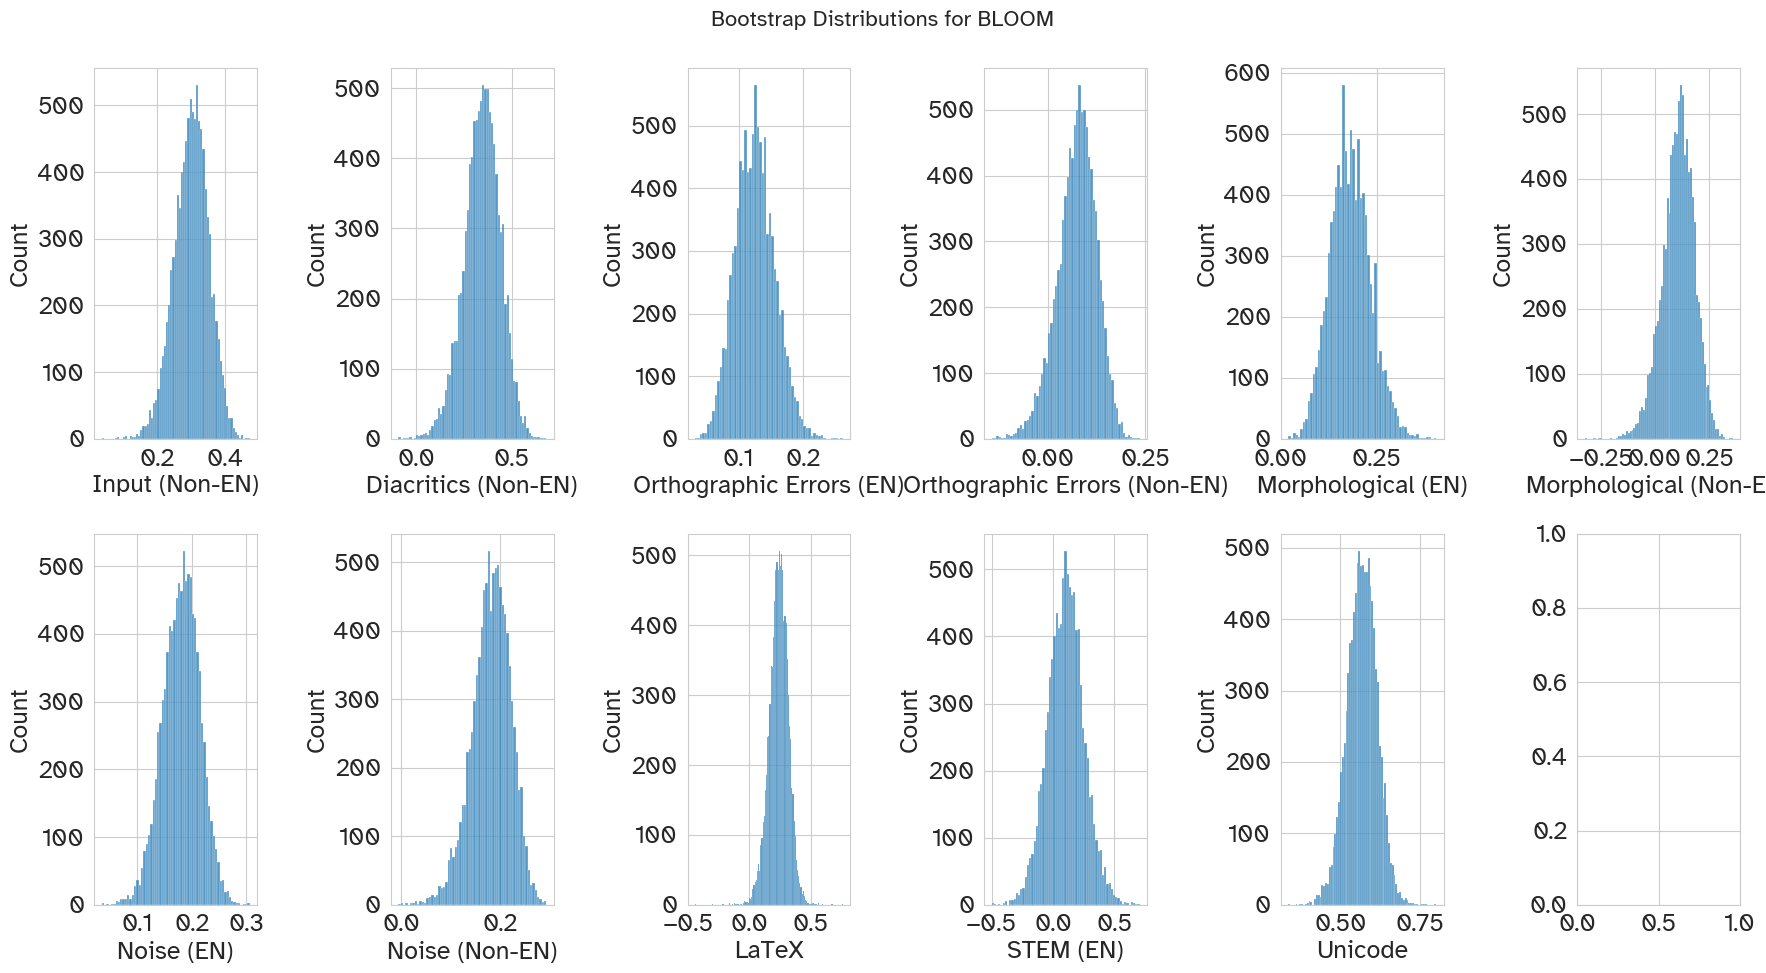

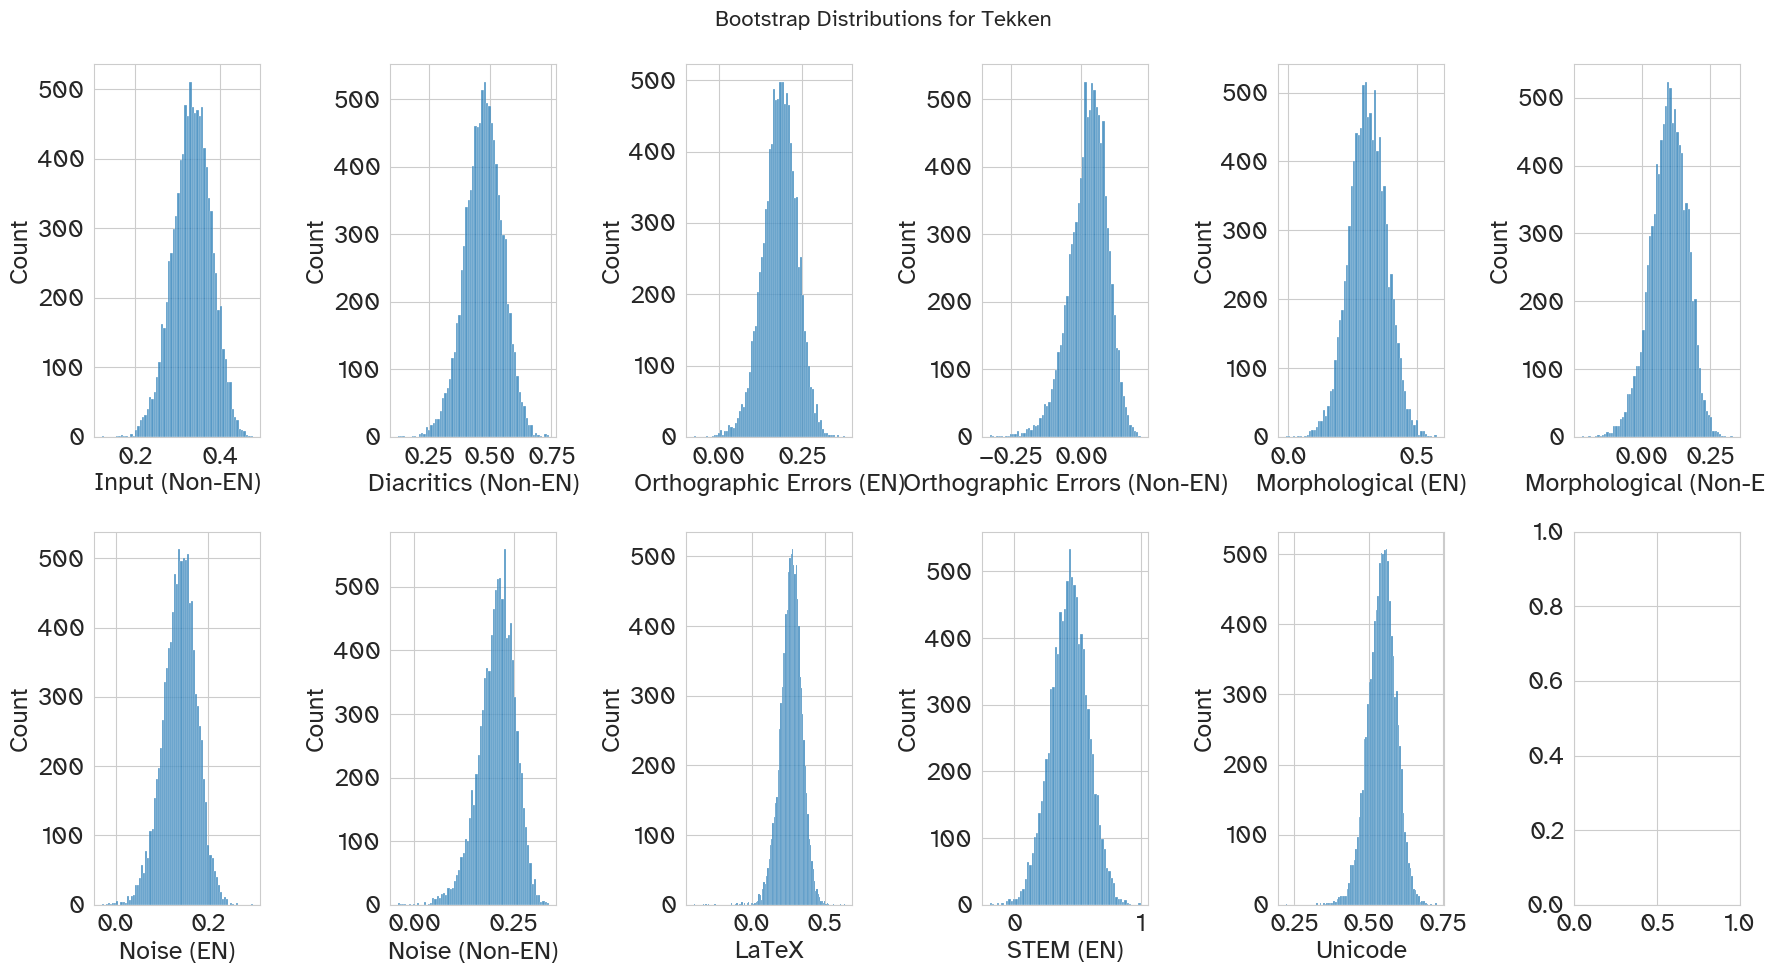

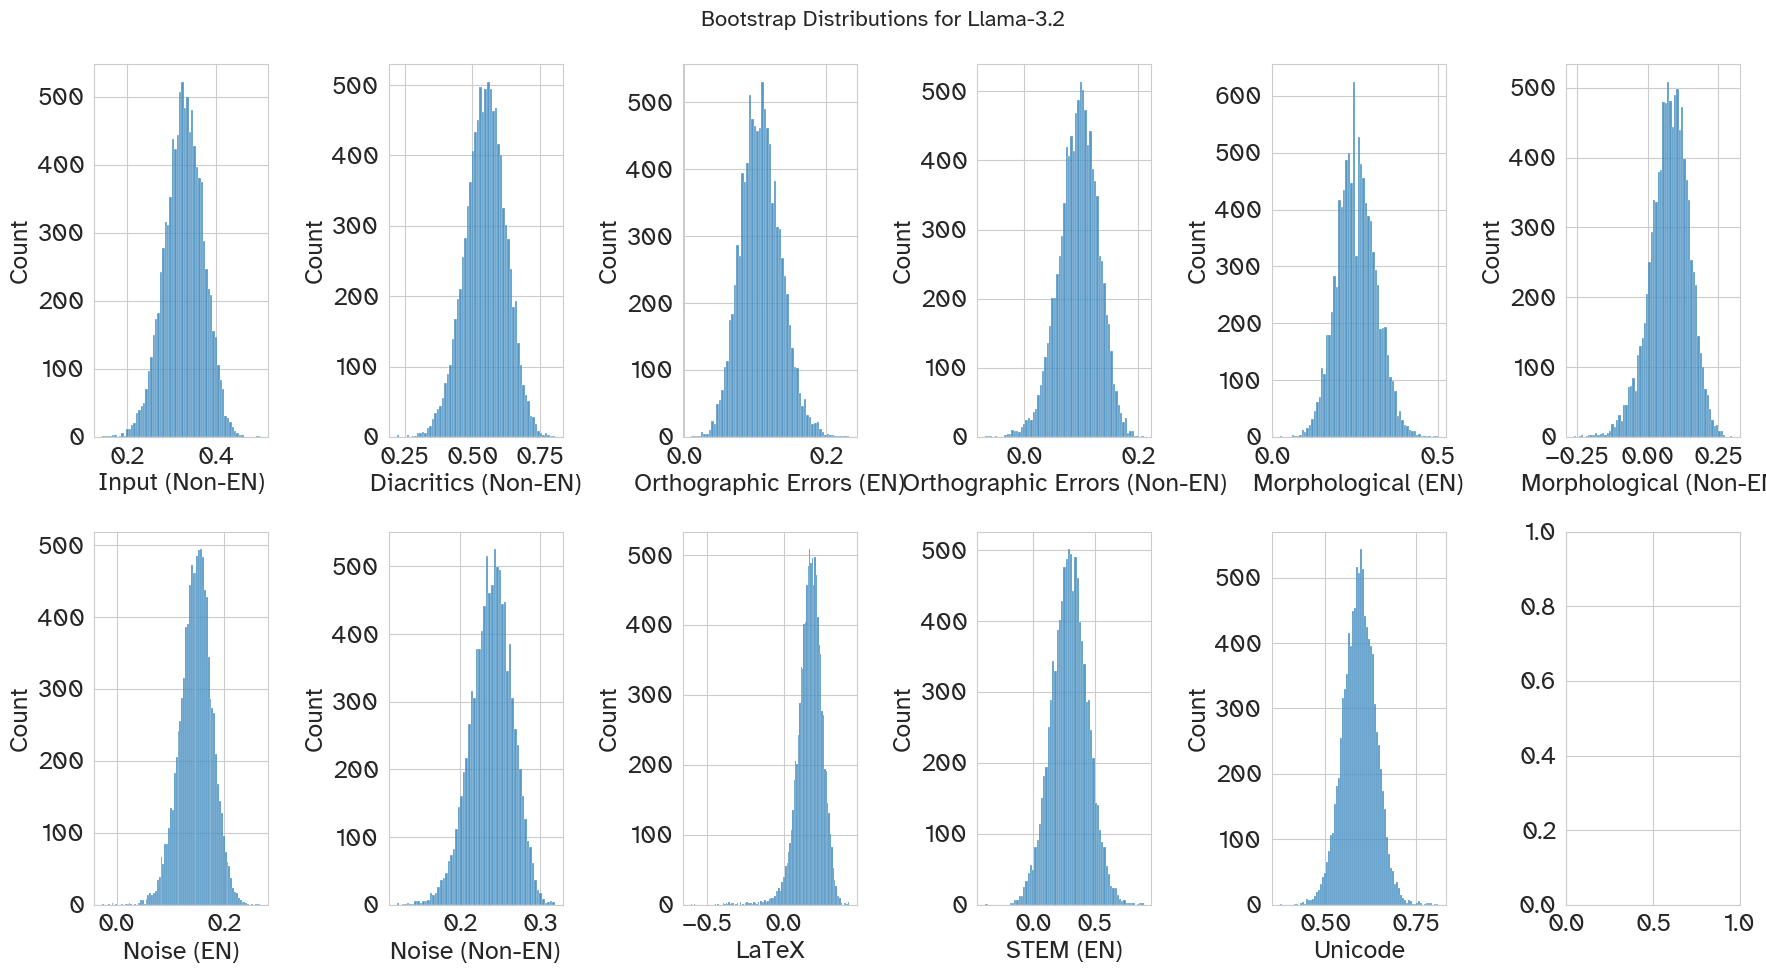

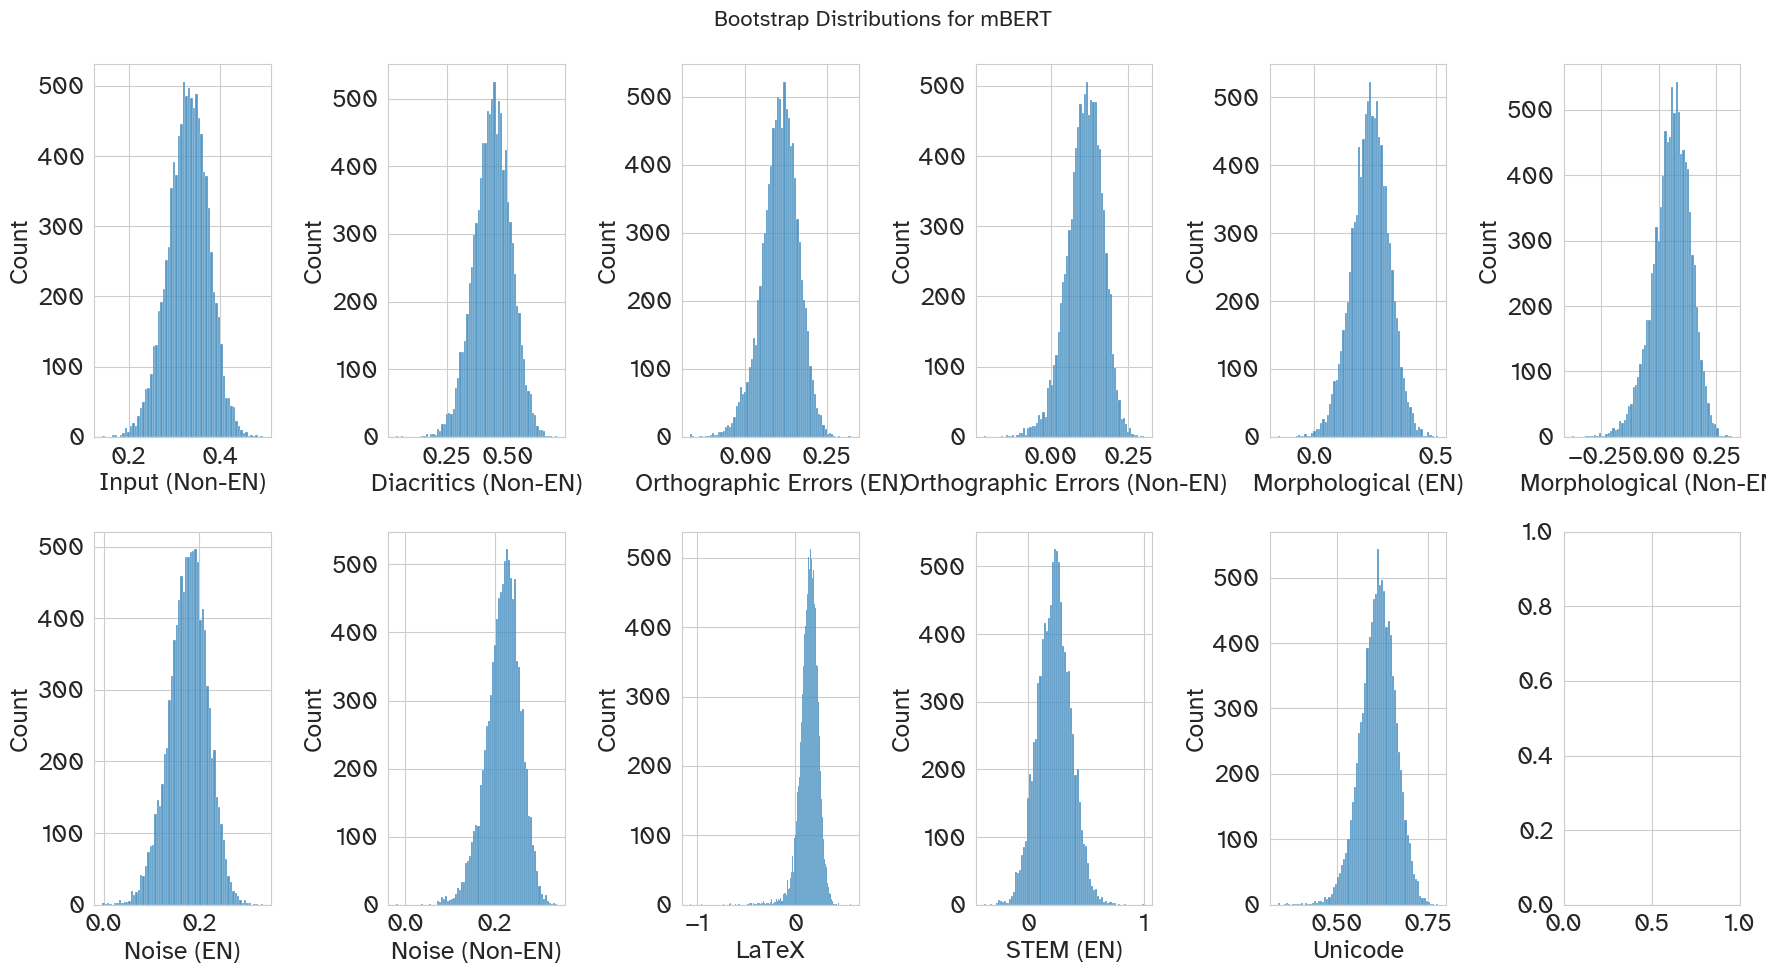

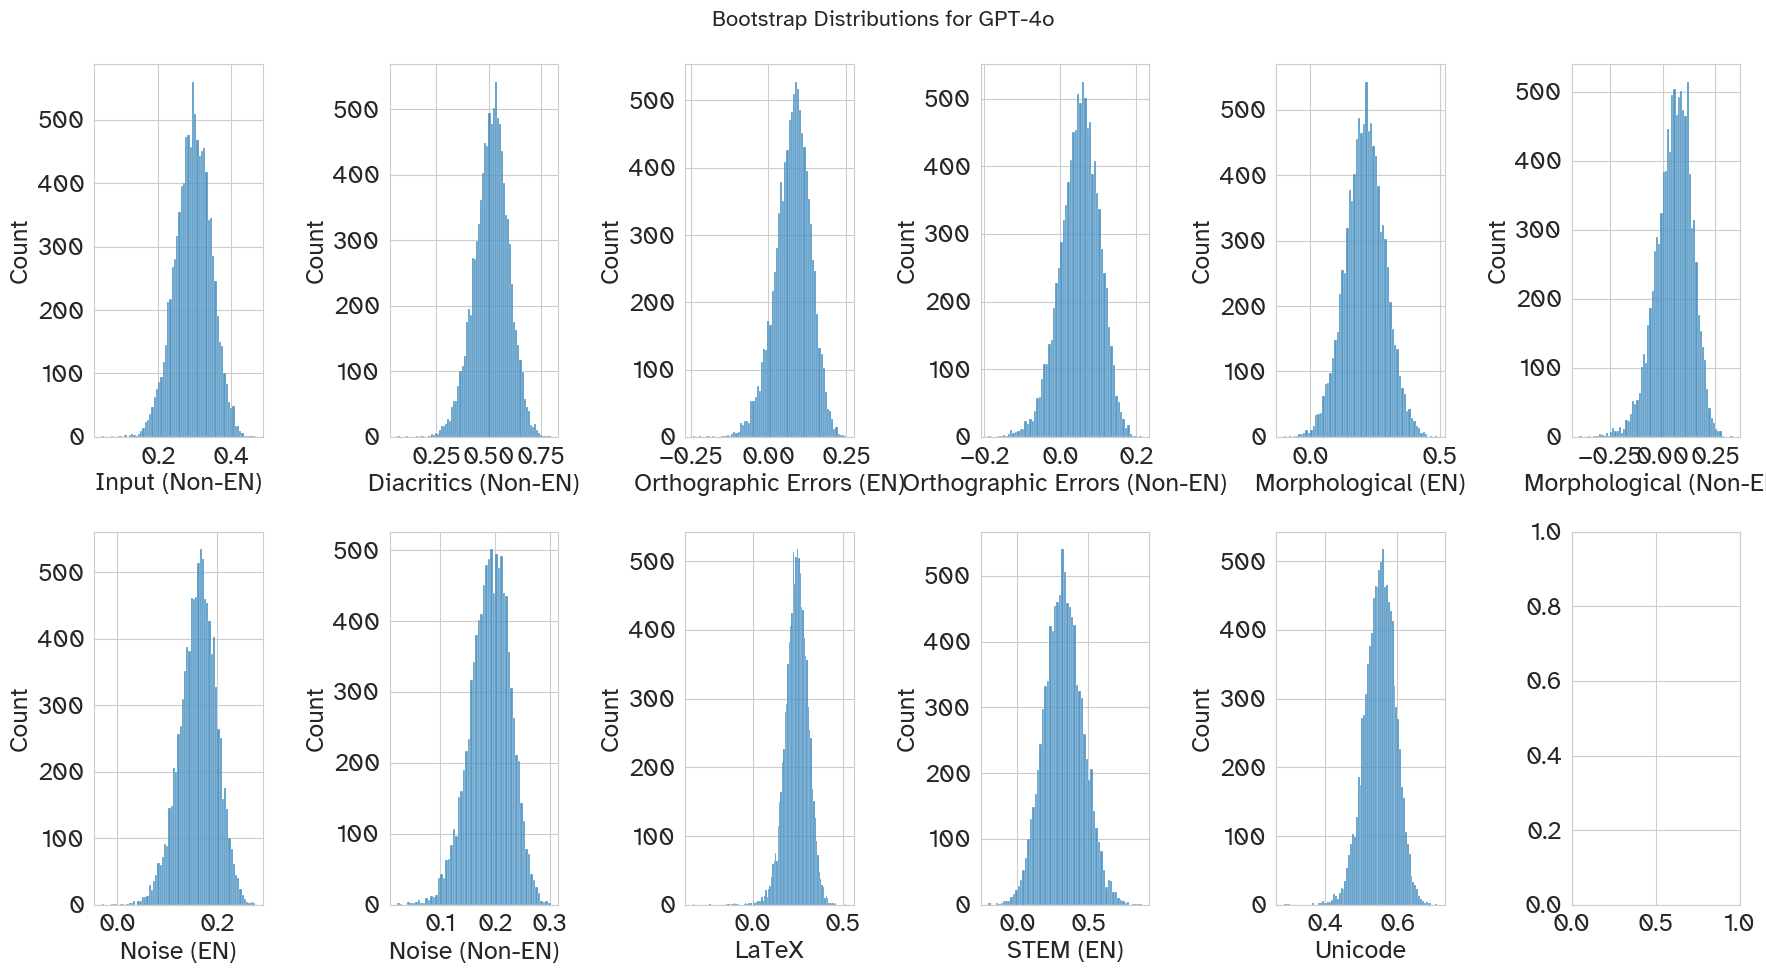

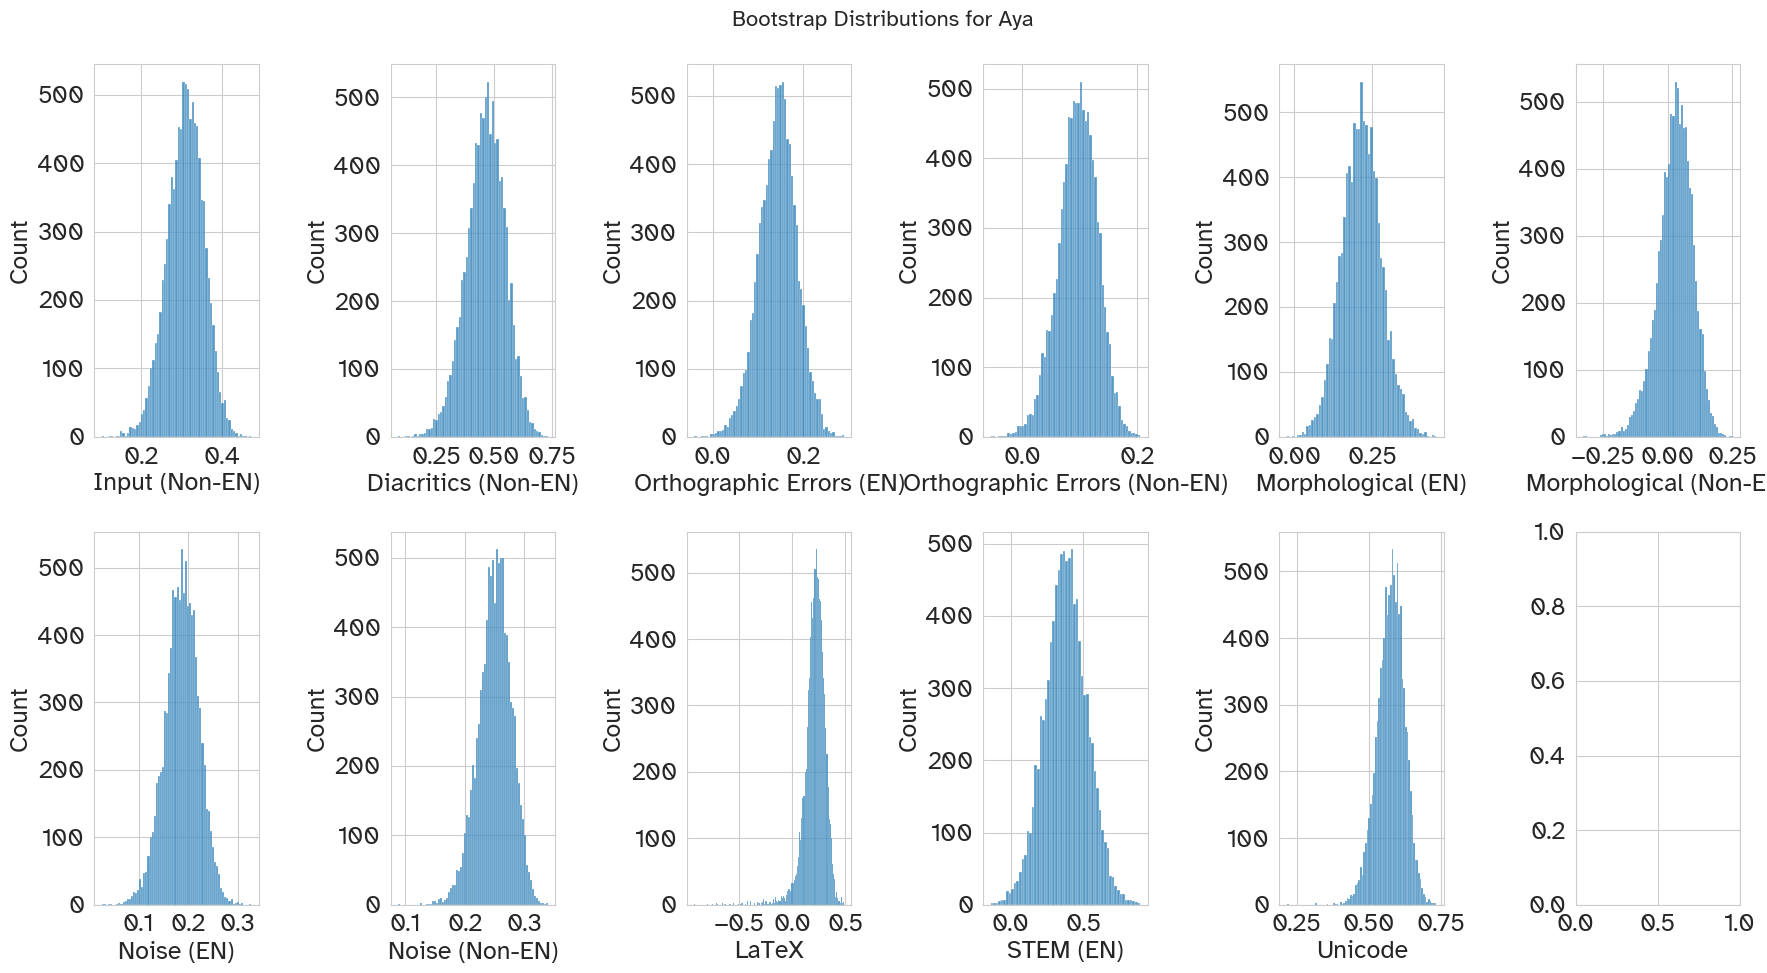

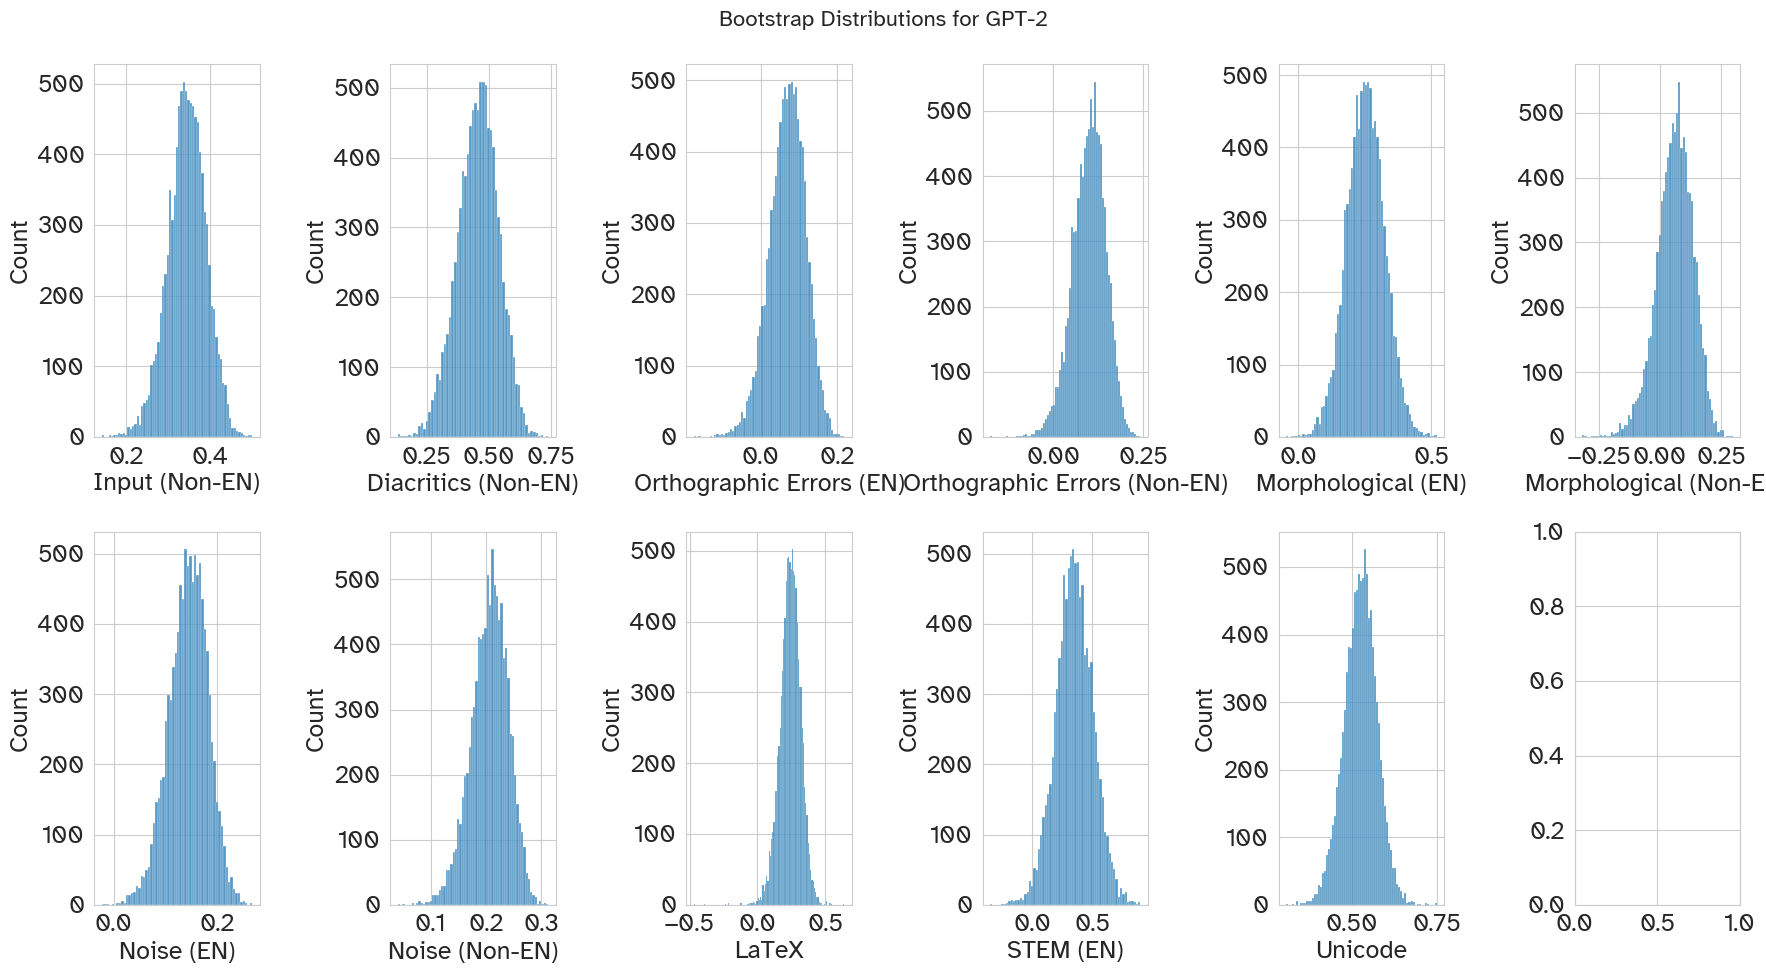

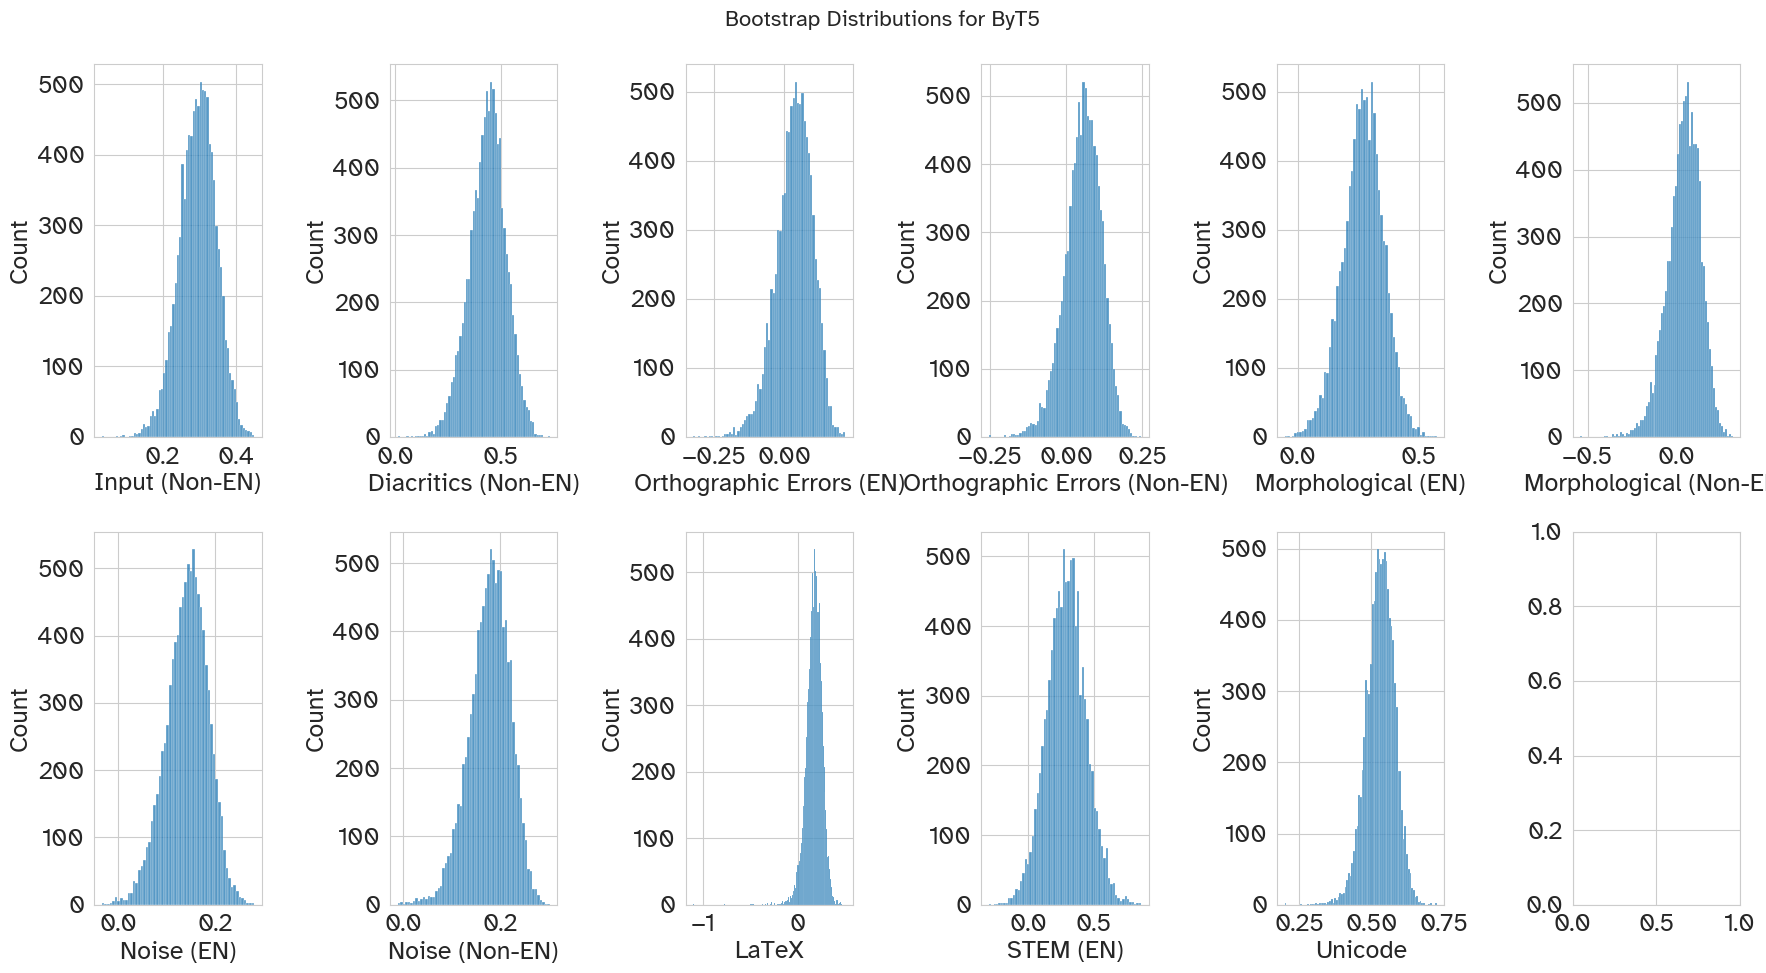

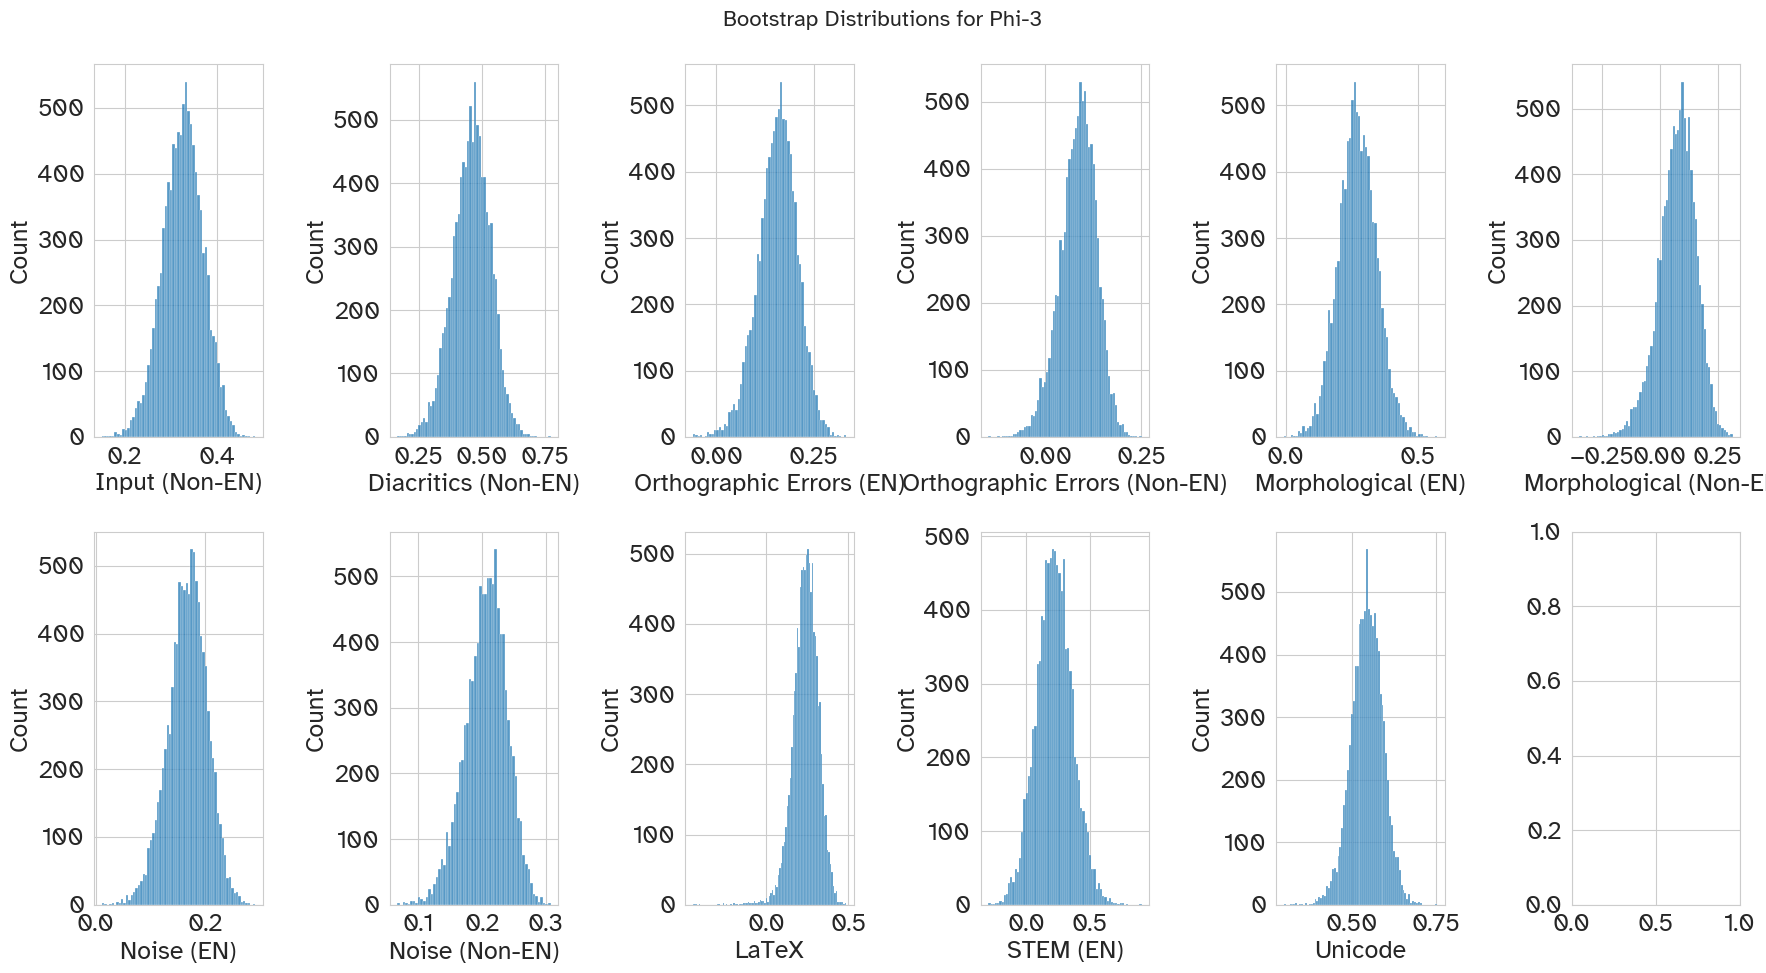

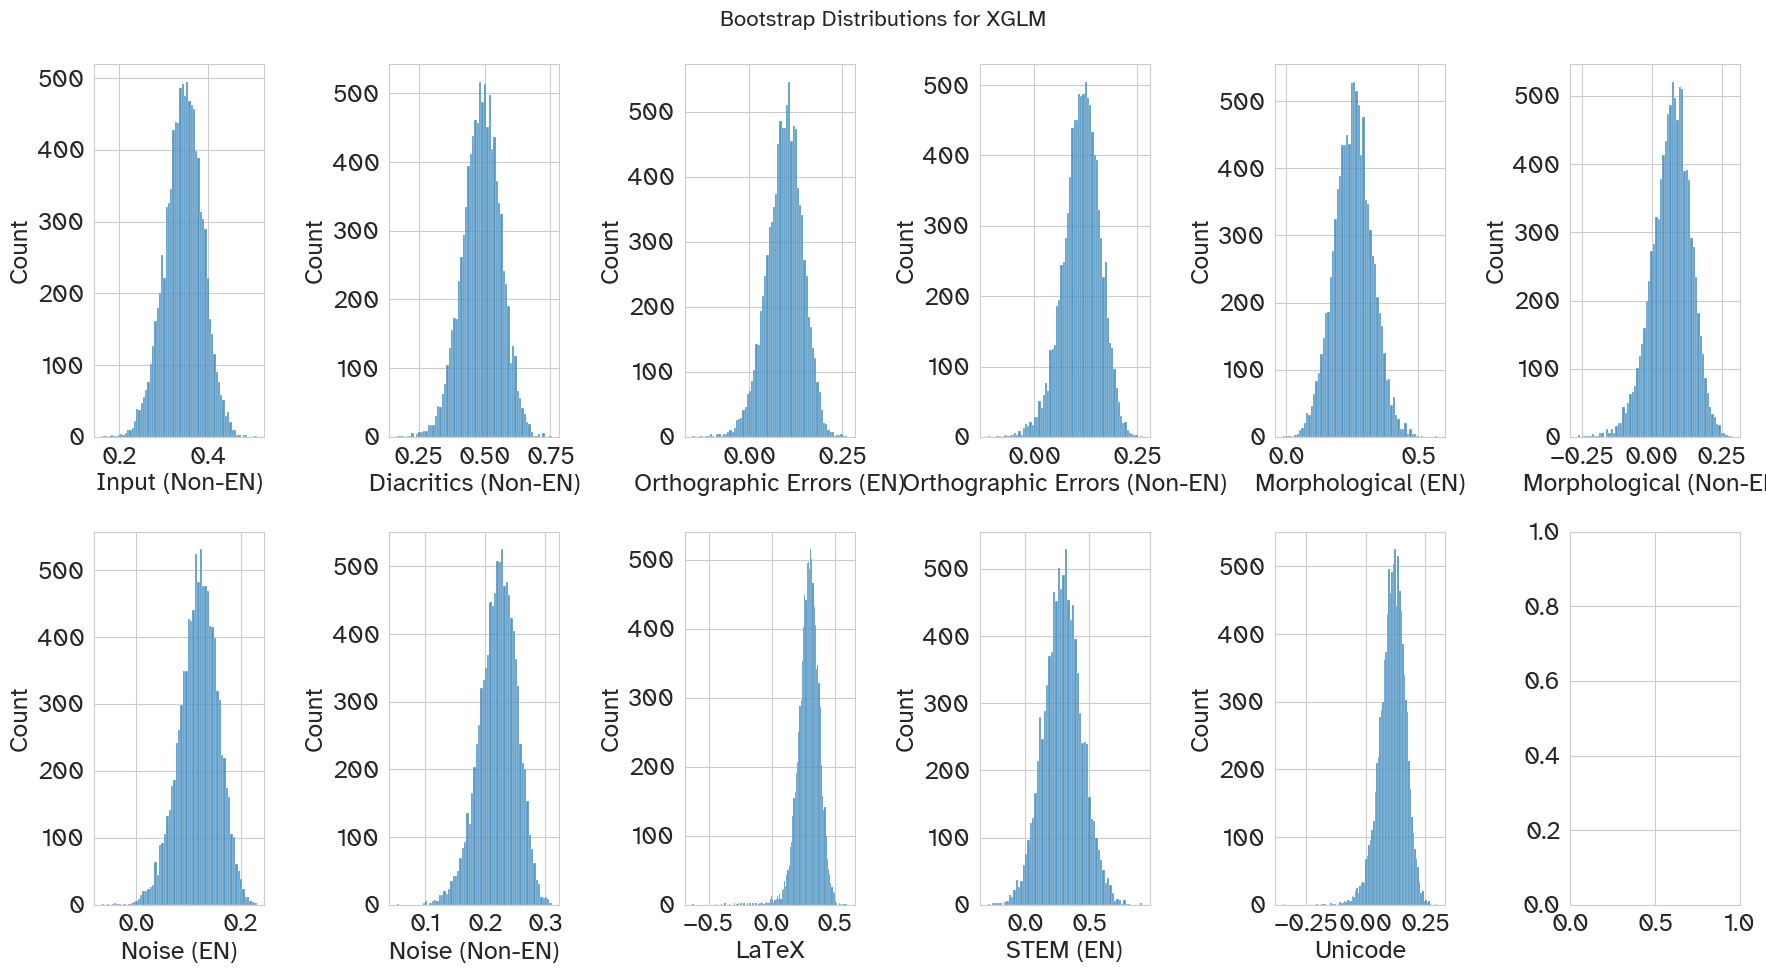

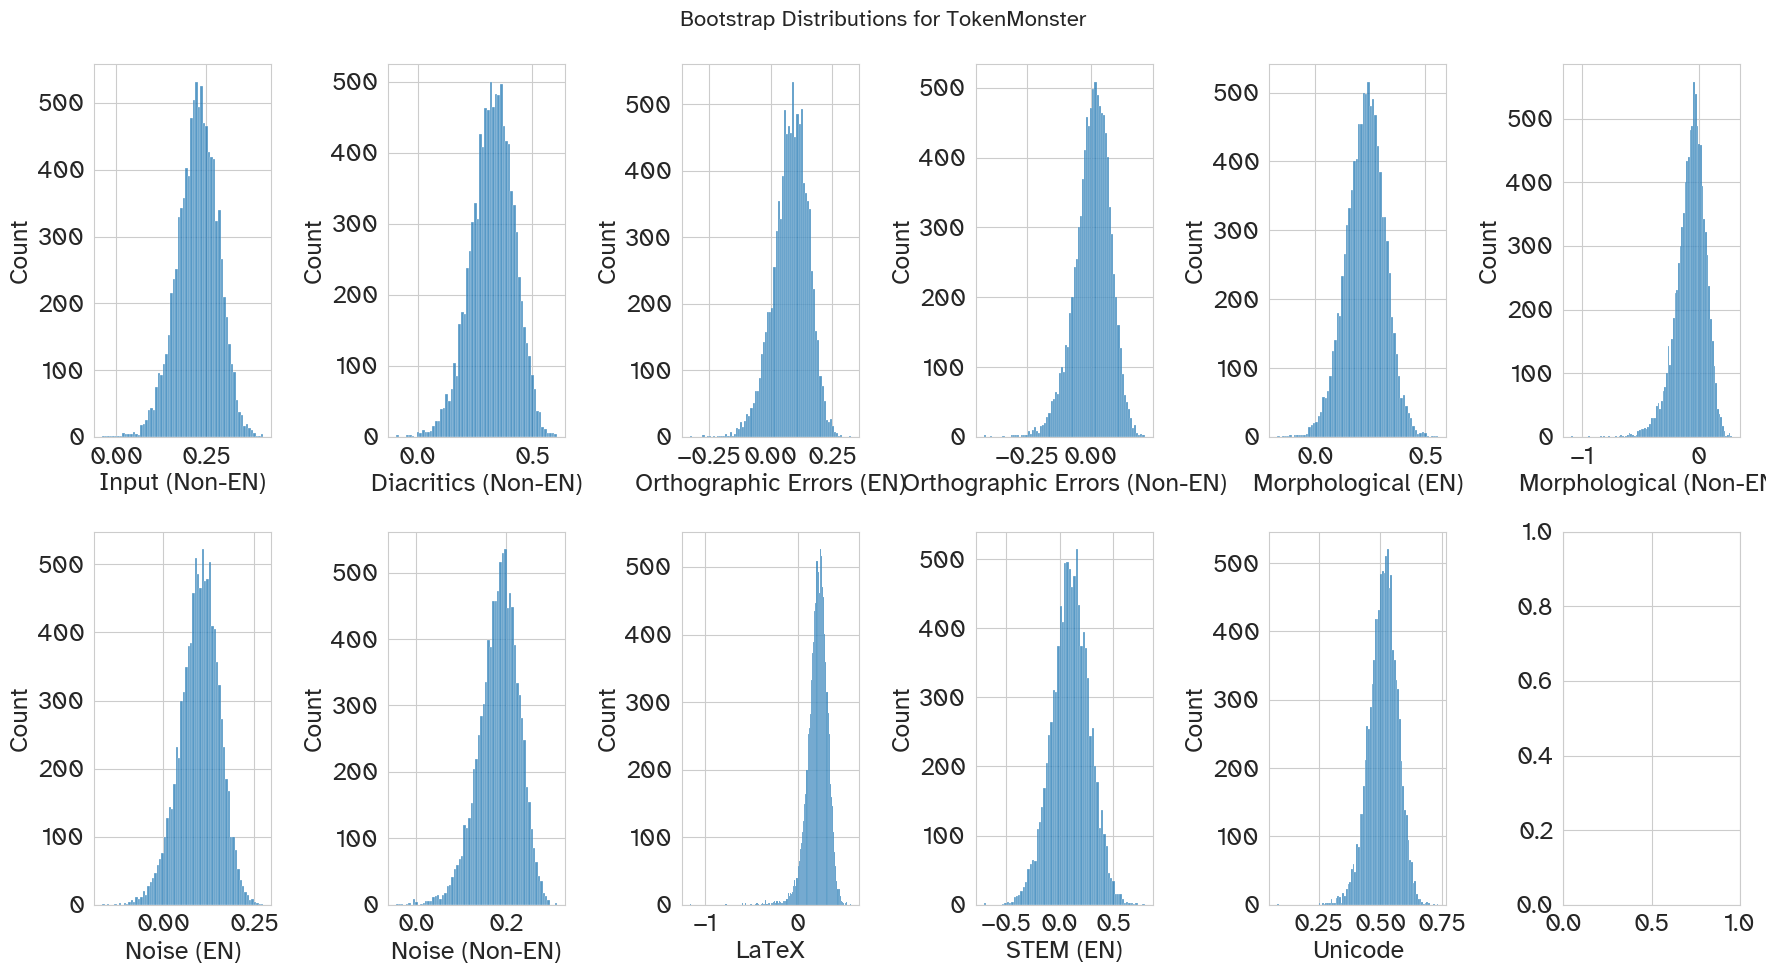

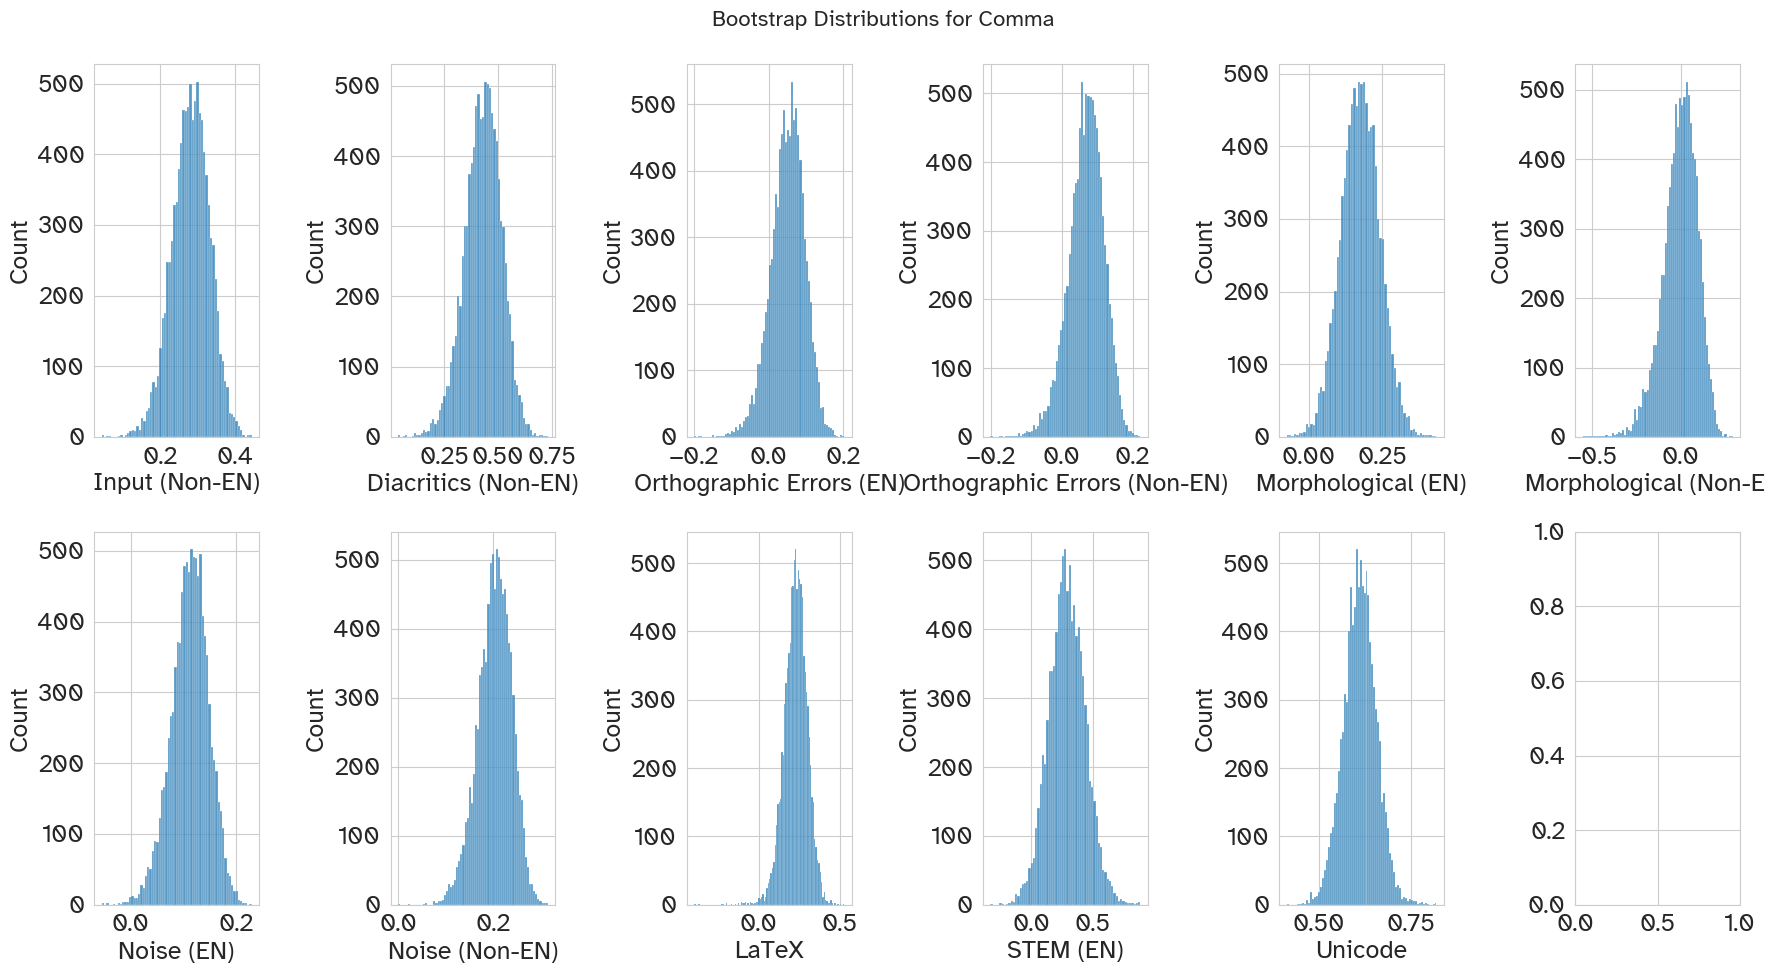

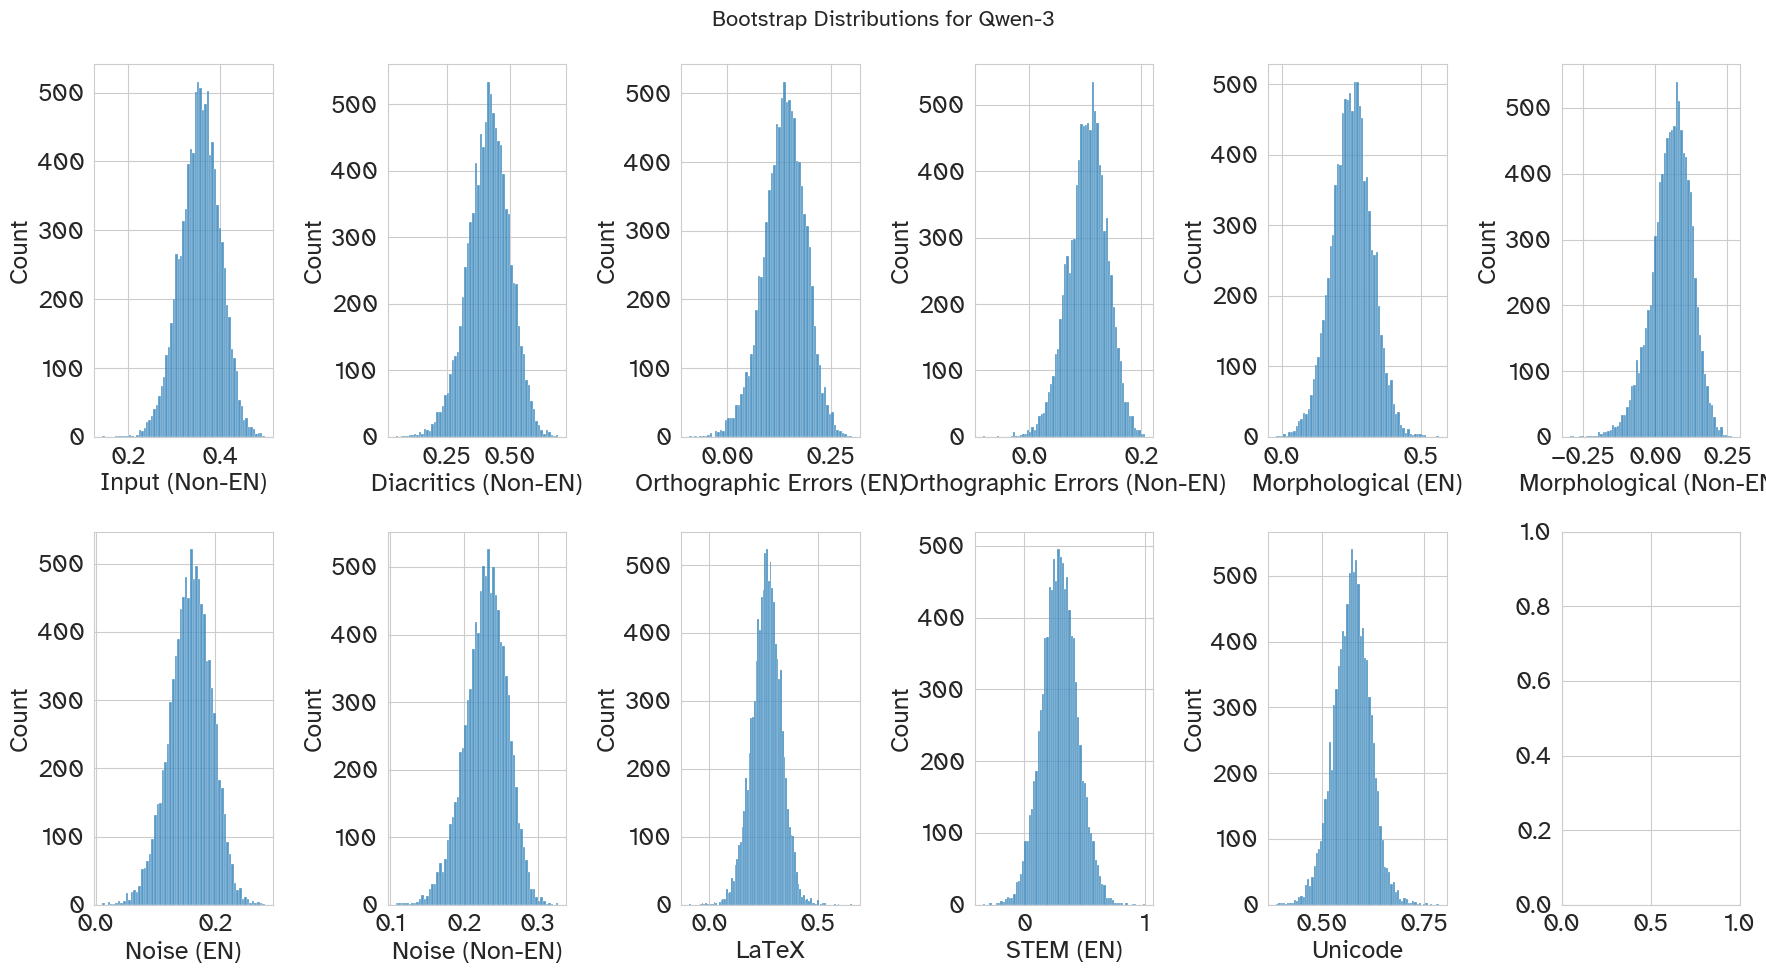

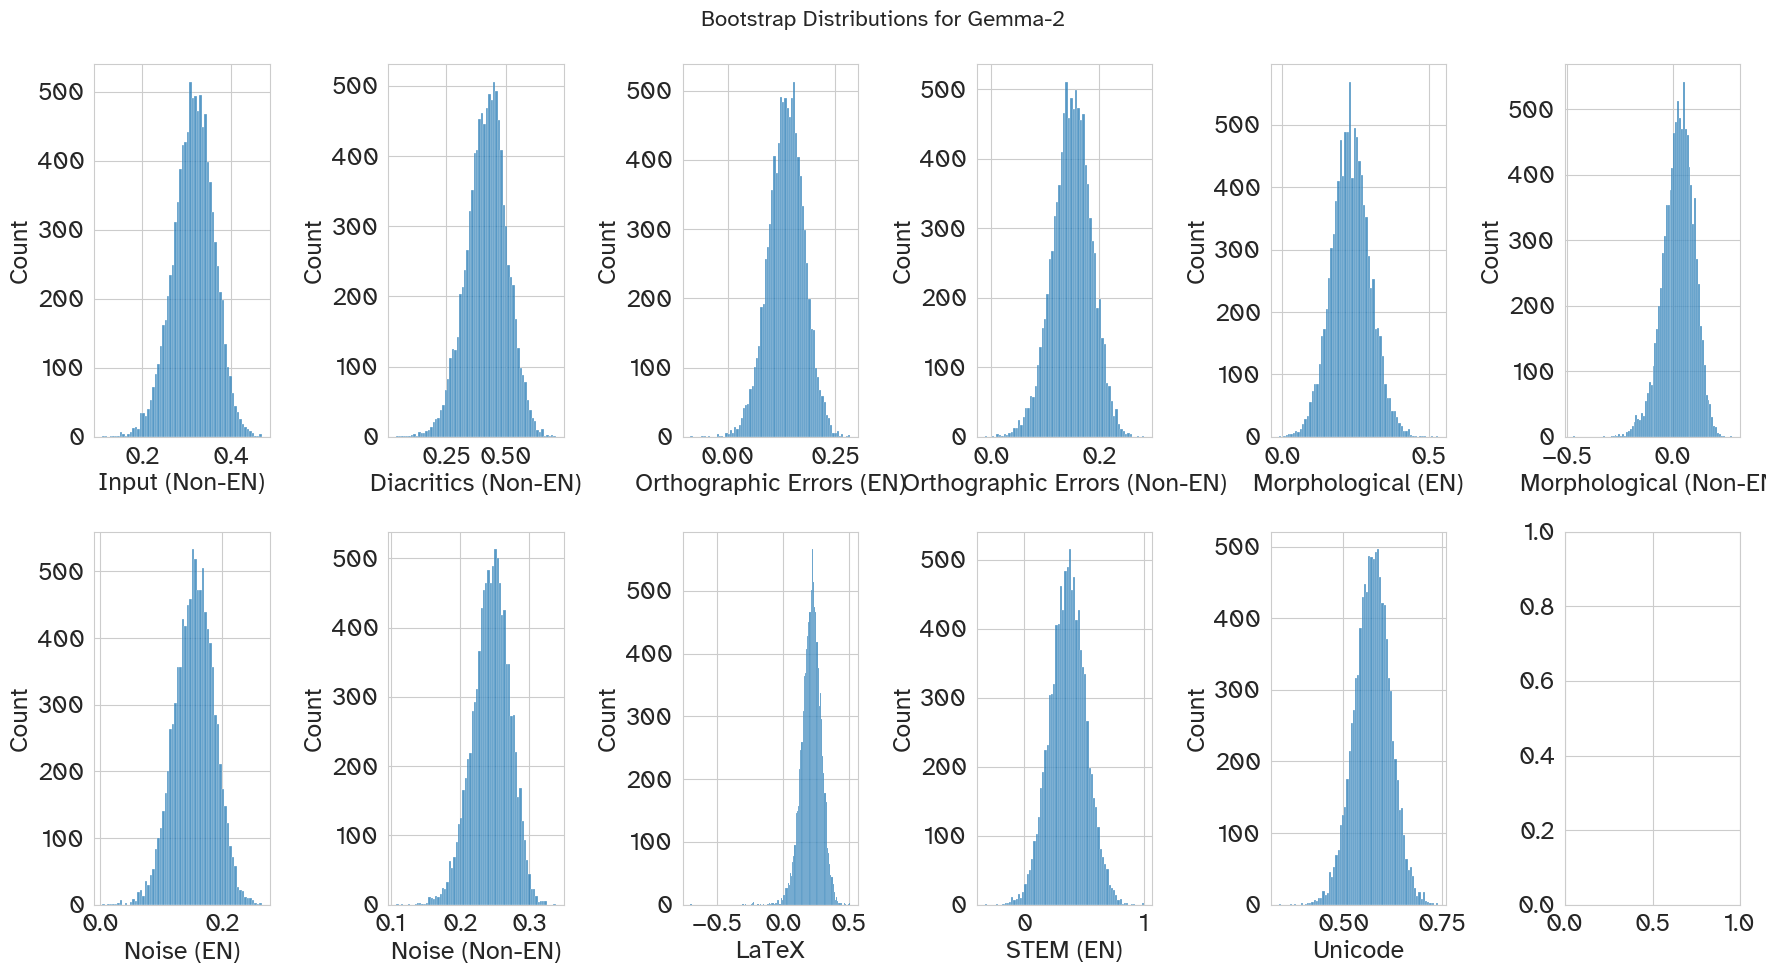

In [138]:
import seaborn as sns

# df_ = bootstrap_combined_df[np.isfinite(bootstrap_combined_df["Input (Non-EN)"])]

for model_name in bootstrap_combined_df["model_name"].unique():
    cols = [col for col in bootstrap_combined_df.columns.tolist()  if col not in ["sample_id", "model_name"]]
    nrows = 2
    ncols = math.ceil(len(cols) / nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=(3 * ncols, 5 * nrows))
    fig.suptitle(f"Bootstrap Distributions for {model_name}", fontsize=16)
    axs = axs.flatten()
    for i, col in enumerate(cols):
        try:
            sns.histplot(bootstrap_combined_df[bootstrap_combined_df["model_name"] == model_name][col], ax=axs[i])
            # axs[i].set_title(f"{col}", fontsize=14)
        except Exception as e:
            print(f"Could not plot {col} for {model_name}: {e}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"bootstrap_distribution_{model_name}.png")
    plt.show()



In [133]:
bootstrap_combined_df

,sample_id,model_name,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,Math/STEM (EN),Unicode
0,0,BLOOM,0.335045,0.351852,0.125000,0.077823,0.195122,0.110929,0.182072,0.172926,0.245012,0.108108,0.566241
1,0,XGLM,0.300423,0.490179,0.026316,0.118684,0.253589,0.021879,0.130687,0.228785,0.352941,0.294872,0.118116
2,0,Tekken,0.350644,0.477230,0.184211,-0.041879,0.358151,-0.038961,0.137280,0.171528,0.274476,0.435897,0.538677
3,0,Qwen-3,0.381777,0.420168,0.078947,0.119287,0.306804,0.120879,0.177918,0.238067,0.253394,0.294872,0.640126
4,0,GPT-2,0.406998,0.459677,0.052632,0.227053,0.022556,0.097643,0.161748,0.280547,0.247121,0.348684,0.504665
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,4999,ByT5,0.351647,0.419355,0.000000,0.053140,0.272727,0.066667,0.149257,0.182616,0.066667,0.294872,0.476333
69996,4999,BLOOM,0.356543,0.351852,0.125000,0.242424,0.195122,0.138047,0.183859,0.206481,0.245012,0.108108,0.557808
69997,4999,Aya,0.284552,0.451613,0.025641,0.078075,0.216783,0.045752,0.204958,0.260229,0.320588,NaN,0.539482
69998,4999,Qwen-3,0.556454,0.420168,0.078947,0.164535,0.253589,0.045752,0.159862,0.221195,0.264391,NaN,0.568376


# EXact-Byte Level Stuff

In [330]:
## Read all samples into a DataFrame
## exclude general dataset for now

OUTPUT_DIR_ = OUTPUT_DIR / "summary-rebuttal-exact-byte"
METRIC = "acc_norm"
# read all samples
base_dir = Path("../results").resolve().absolute()

code_pattern = "*"
title_pattern = "All Datasets"
OUTPUT_DIR = OUTPUT_DIR_ / "all"

OUTPUT_DIR = OUTPUT_DIR
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

## read samples
all_samples = load_all_samples(
    base_dir,
    patterns=["exact-byte-level/samples*.jsonl", "paper-v5/*gemma-2-2b/samples*.jsonl", "paper-v5/*tokenmonster*/samples*.jsonl"],
    exclude_patterns=["general"],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)

444 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/exact-byte-level/samples_tokenizer_robustness_completion_english_compounds_2025-12-02T13-11-14.108586.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/exact-byte-level/samples_tokenizer_robustness_completion_chinese_partially_romanized_2025-12-02T19-44-41.483094.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/exact-byte-level/samples_tokenizer_robustness_completion_stem_upside_down_rotated_2025-12-02T23-46-52.313154.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/exact-byte-level/samples_tokenizer_robustness_completion_math_latex_2025-12-02T18-02-38.451814.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/exact-byte-level/samples_tokenizer_robustness_completion_english_colloquial_2025-12-02T12-54-05.755898.jsonl')]
['300.0' '301.0' '302.0' '304.0' '305.0' '306.0' '307.0' '308.0' '309.0'
 '310.0' '311.0' '312.0' '313.0' '314.0' '315.0' '316.0' '317.0' '322.0

In [331]:
all_samples["model_name"] = all_samples["model_name"].map(lambda x: x if x!= "" else "Gemma-2-EBL")
all_samples["model_name"].unique()

array(['Gemma-2-EBL', 'Gemma-2', 'TokenMonster'], dtype=object)

In [332]:
import warnings

from category_mapping import SUBCATEGORY_TO_CATEGORY
from typing import List

FILTERS = [
    "no_filter",
    "only_canonical_correct",
    "canonical_wrong_at_least_one_perturb_correct",
    "remains_or_becomes_correct",
]
keys = {
    "no_filter": (False, False, False),
    "only_canonical_correct": (True, False, False),
    "canonical_wrong_at_least_one_perturb_correct": (False, False, True),
    "remains_or_becomes_correct": (False, True, False),
}


all_summaries = get_summaries(all_samples, subcategories=None, remove_duplicates=True)

N duplicates: 4373


/Users/gsaltintas/code/phd/tokenizers/notebooks/utils.py:980: UserWarning: Oh noo, check for model: Gemma-2-EBL, task: tokenizer_robustness_completion_italian_orthographic_errors if it is run, the df is empty, skipping for now...
  warnings.warn(
/Users/gsaltintas/code/phd/tokenizers/notebooks/utils.py:980: UserWarning: Oh noo, check for model: Gemma-2-EBL, task: tokenizer_robustness_completion_italian_typographical_errors if it is run, the df is empty, skipping for now...
  warnings.warn(
/Users/gsaltintas/code/phd/tokenizers/notebooks/utils.py:980: UserWarning: Oh noo, check for model: Gemma-2-EBL, task: tokenizer_robustness_completion_farsi_dialects if it is run, the df is empty, skipping for now...
  warnings.warn(
/Users/gsaltintas/code/phd/tokenizers/notebooks/utils.py:980: UserWarning: Oh noo, check for model: Gemma-2-EBL, task: tokenizer_robustness_completion_farsi_romanization if it is run, the df is empty, skipping for now...
  warnings.warn(
/Users/gsaltintas/code/phd/tokeni

N duplicates: 10907
N duplicates: 5086
N duplicates: 11378


In [333]:
df = all_summaries[all_summaries["filtering_mode"] == FILTER].pivot_table(index="model_name", columns=["task_pretty_name", "langs"], values=METRIC, aggfunc=np.mean)
df = df.dropna(how="any", axis=1).transpose()
df

/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_15279/226809048.py:1: FutureWarning: The provided callable <function mean at 0x106844d30> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = all_summaries[all_summaries["filtering_mode"] == FILTER].pivot_table(index="model_name", columns=["task_pretty_name", "langs"], values=METRIC, aggfunc=np.mean)


model_name                                                Gemma-2  \
task_pretty_name                               langs                
Abbreviations                                  eng_Latn  0.729730   
                                               ita_Latn  0.703704   
Arabic Keyboard for Farsi                      pes_Arab  0.400000   
Canonical                                      eng_Latn  0.890296   
                                               ita_Latn  0.975000   
...                                                           ...   
Web search query                               eng_Latn  0.486486   
                                               ita_Latn  0.450000   
Word Spacing/Zero-width characters/Extra Space pes_Arab  0.550000   
                                               zho_Hans  0.750000   
Word reordering                                eng_Latn  0.900000   

model_name                                               Gemma-2-EBL  \
task_pretty_name                               langs                   
Abbreviations                                  eng_Latn     0.594595   
                                               ita_Latn     0.666667   
Arabic Keyboard for Farsi                      pes_Arab     0.425000   
Canonical                                      eng_Latn     0.652633   
                                               ita_Latn     0.675000   
...                                                              ...   
Web search query                               eng_Latn     0.594595   
                                               ita_Latn     0.475000   
Word Spacing/Zero-width characters/Extra Space pes_Arab     0.525000   
                                               zho_Hans     0.650000   
Word reordering                                eng_Latn     0.750000   

model_name                                               TokenMonster  
task_pretty_name                               langs                   
Abbreviations                                  eng_Latn      0.594595  
                                               ita_Latn      0.814815  
Arabic Keyboard for Farsi                      pes_Arab      0.525000  
Canonical                                      eng_Latn      0.771465  
                                               ita_Latn      0.850000  
...                                                               ...  
Web search query                               eng_Latn      0.648649  
                                               ita_Latn      0.525000  
Word Spacing/Zero-width characters/Extra Space pes_Arab      0.575000  
                                               zho_Hans      0.825000  
Word reordering                                eng_Latn      0.825000  

[97 rows x 3 columns]

In [334]:
print(df.to_markdown())

|                                                                |   Gemma-2 |   Gemma-2-EBL |   TokenMonster |
|:---------------------------------------------------------------|----------:|--------------:|---------------:|
| ('Abbreviations', 'eng_Latn')                                  |  0.72973  |      0.594595 |       0.594595 |
| ('Abbreviations', 'ita_Latn')                                  |  0.703704 |      0.666667 |       0.814815 |
| ('Arabic Keyboard for Farsi', 'pes_Arab')                      |  0.4      |      0.425    |       0.525    |
| ('Canonical', 'eng_Latn')                                      |  0.890296 |      0.652633 |       0.771465 |
| ('Canonical', 'ita_Latn')                                      |  0.975    |      0.675    |       0.85     |
| ('Canonical', 'pes_Arab')                                      |  0.75     |      0.7      |       0.7      |
| ('Canonical', 'tur_Latn')                                      |  0.825    |      0.575    |       0.6

In [335]:


# FILTER = "no_filter"

# Define categories for the LaTeX table
latex_table_categories = {
    "Input (Non-EN)": [
        "English keyboard",
        "Arabic Keyboard for Farsi", 
        "Number Romanization",
        "Romanization",
        # "Partially romanized",
        "Traditional"
    ],
    "Diacritics (Non-EN)": ["Optional diacritics"],
    "Orthographic Errors (EN)": [
        "Orthographic errors",
        "Grammatical errors"
    ],
    "Orthographic Errors (Non-EN)": [
        "Orthographic errors",
        "Grammatical errors"
    ],
    "Morphological (EN)": [
    "Contractions",
    "Derivations",
    "Inflections",],
    "Morphological (Non-EN)": [
    "Contractions",
    "Derivations",
    "Inflections",],
    "Noise (EN)": [
        "Homoglyphs", "Plausible diacritics errors", "Keyboard proximity errors",
        "OCR Errors", "Character deletion", "Space removal", "Typographical errors",
        "Word Spacing/Zero-width characters/Extra Space",
    ],
    "Noise (Non-EN)": [
        "Homoglyphs", "Plausible diacritics errors", "Keyboard proximity errors", 
        "OCR Errors", "Character deletion", "Space removal", "Typographical errors",
        "Word Spacing/Zero-width characters/Extra Space",
    ],
    "LaTeX": ["LaTeX"],
    "STEM (EN)": [
        # "Spelled out", 
        "Unusual formatting"
        ],
    # "Math/STEM (Non-EN)": ["Turkish", "Italian", "Chinese", "Farsi"],
    "Unicode": [
        "Fullwidth Characters", "Decorative Unicode", "Scripted text",
        "Double struck", "Enclosed Characters", "Unicode formatting",
    ],
}

latex_column_data = [
    ["Input", "Diacr.", "Orth. Gram.", "<same>", "Morph", "<same>", "Noise", "<same>", "LaTeX", "STEM", "Unic", "Avg"],
    ["NEN", "NEN", "EN", "NEN", "EN", "NEN", "EN", "NEN", "EN", "EN", "EN", ""]
]

caption = "Tokenization robustness under multilingual text perturbations. Values represent relative performance drop ($\\frac{\\text{Acc}_{\\text{can}} - \\text{Acc}_{\\text{pert}}}{\\text{Acc}_{\\text{can}}}$); lower values indicate greater robustness. Perturbation types: Input: non-native keyboard/romanization; Diacr.: optional diacritics; Orth. Errors: orthographic errors; Morph.: derivations/inflections/contractions; Noise: homoglyphs/OCR/typos/spacing; LaTeX: LaTeX-style math formatting; STEM: scientific diagrams and notations; Unic.: Unicode styling characters. N\\eng:non-English. Break-down of each category and detailed case studies are presented in \\cref{ap:sec:benchmark_results}. \\textbf{\\textcolor{green!70!black}{Green}} and \\textcolor{red}{red} entries indicate notable robustness and fragility, respectively."
label="exact-byte-level"

if __name__ == "__main__":
    # Generate robustness data and save to JSONL
    canonical_by_task = get_canonical_by_task(all_summaries, FILTER)
    robustness_data_main = generate_robustness_latex_table_dict(all_summaries, canonical_by_task, FILTER, latex_table_categories=latex_table_categories, group_langs=True)
    jsonl_file = save_to_jsonl(robustness_data_main, "robustness_results.jsonl")
    
    # Generate robustness LaTeX table
    robustness_latex = load_and_generate_robustness_latex_table(jsonl_file,  column_data=latex_column_data, size="scriptsize", title=caption, label=label)
    
    print("Robustness LaTeX Table Generated!")
    print("=" * 60)
    print(robustness_latex)
    
    # Save to file
    with open("robustness_tokenization_table.tex", "w") as f:
        f.write(robustness_latex)
    print("\nRobustness table saved to: robustness_tokenization_table.tex")
get_robustness_styled_df(jsonl_file)


Results saved to robustness_results.jsonl
Robustness LaTeX Table Generated!
\begin{table}[hp]
\centering 
\vspace*{\fill}
\caption{Tokenization robustness under multilingual text perturbations. Values represent relative performance drop ($\frac{\text{Acc}_{\text{can}} - \text{Acc}_{\text{pert}}}{\text{Acc}_{\text{can}}}$); lower values indicate greater robustness. Perturbation types: Input: non-native keyboard/romanization; Diacr.: optional diacritics; Orth. Errors: orthographic errors; Morph.: derivations/inflections/contractions; Noise: homoglyphs/OCR/typos/spacing; LaTeX: LaTeX-style math formatting; STEM: scientific diagrams and notations; Unic.: Unicode styling characters. N\eng:non-English. Break-down of each category and detailed case studies are presented in \cref{ap:sec:benchmark_results}. \textbf{\textcolor{green!70!black}{Green}} and \textcolor{red}{red} entries indicate notable robustness and fragility, respectively.}
\label{tab:exact-byte-level}
\scriptsize
\begin{tabularx

,Input (Non-EN),Diacritics (Non-EN),Orthographic Errors (EN),Orthographic Errors (Non-EN),Morphological (EN),Morphological (Non-EN),Noise (EN),Noise (Non-EN),LaTeX,STEM (EN),Unicode,Average
model_name,,,,,,,,,,,,
Gemma-2-EBL,0.23,0.38,0.17,0.03,0.23,-0.09,0.16,0.19,0.13,0.15,0.35,0.17
TokenMonster,0.23,0.33,0.09,0.02,0.23,-0.05,0.11,0.19,0.23,0.11,0.52,0.18
Gemma-2,0.32,0.43,0.14,0.15,0.24,0.03,0.16,0.25,0.22,0.37,0.57,0.26
────────────────────,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MEAN,0.26,0.38,0.13,0.07,0.23,-0.04,0.14,0.21,0.19,0.21,0.48,0.21
STD,0.04,0.04,0.04,0.06,0.00,0.05,0.02,0.03,0.04,0.11,0.09,0.04


In [336]:
ebl = all_summaries[all_summaries["model_name"] == "Gemma-2-EBL"]
for cat, sub_ in latex_table_categories.items():
    # print(f"{cat}: {sub}")
    for sub in sub_:
        if sub not in ebl["task_pretty_name"].unique():
            print(f"Category '{cat}' with sub {sub} has no samples in Gemma-2-EBL")


Category 'Unicode' with sub Enclosed Characters has no samples in Gemma-2-EBL


In [337]:
all_summaries["task_pretty_name"]

0                       Canonical
1                           LaTeX
2                     Spelled out
3              Decorative Unicode
4                           Farsi
                  ...            
1339    Keyboard proximity errors
1340                Space removal
1341          Enclosed Characters
1342                Scripted text
1343                  Spelled out
Name: task_pretty_name, Length: 1344, dtype: object

## Canonical

In [338]:
## just canonical perf
records = []
for key, acc in canonical_by_task.items():
    model_name, task, lang = key
    records.append(
        {
            "model_name": model_name,
            "task": task,
            # "lang": lang,
            "acc_norm": acc,
        }
    )
canonical_df = pd.DataFrame.from_records(records)
# canonical_styled_df = get_styled_df(canonical_df, columns=["task", "lang"])
pv = canonical_df.pivot_table(index="model_name", columns=["task"], values="acc_norm")
pv["Average"] = pv.mean(axis=1)
pv = pv.sort_values("Average", ascending=False)
print(pv.to_markdown().replace("tokenizer_robustness_completion_", ""))

| model_name   |   chinese_canonical |   english_canonical |   farsi_canonical |   italian_canonical |   math_canonical |   stem_canonical |   turkish_canonical |   Average |
|:-------------|----------------------------------------------------:|----------------------------------------------------:|--------------------------------------------------:|----------------------------------------------------:|-------------------------------------------------:|-------------------------------------------------:|----------------------------------------------------:|----------:|
| Gemma-2      |                                               0.775 |                                               0.975 |                                              0.75 |                                               0.975 |                                         0.809524 |                                         0.886364 |                                               0.825 |  0.856555 |
| TokenMonster |           

In [340]:
df = get_robustness_styled_df(jsonl_file).data
df = df.map(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)
print(df.to_markdown())

| model_name           |   Input (Non-EN) |   Diacritics (Non-EN) |   Orthographic Errors (EN) |   Orthographic Errors (Non-EN) |   Morphological (EN) |   Morphological (Non-EN) |   Noise (EN) |   Noise (Non-EN) |   LaTeX |   STEM (EN) |   Unicode |   Average |
|:---------------------|-----------------:|----------------------:|---------------------------:|-------------------------------:|---------------------:|-------------------------:|-------------:|-----------------:|--------:|------------:|----------:|----------:|
| Gemma-2-EBL          |             0.23 |                  0.38 |                       0.17 |                           0.03 |                 0.23 |                    -0.09 |         0.16 |             0.19 |    0.13 |        0.15 |      0.35 |      0.17 |
| TokenMonster         |             0.23 |                  0.33 |                       0.09 |                           0.02 |                 0.23 |                    -0.05 |         0.11 |             0.19 | 